## PowerFlow with GNN 



### Power Flow GNN — Training & Evaluation
### Refactored: 2026-03-17
- Added 39 bus base system as traing option
- Cleanup: removed dead code, fixed debug prints, removed unused params
- Simple network with 9 buses and PyPSA as comparison.
### Refactored: 2026-03-10
- Removed dead/legacy code (see removal list in header comments below)
- Grouped into logical sections
- Distributed slack support added (DISTSLACK markers)
- Bug fixes (BUGFIX markers)
### Removed functions (superseded or broken):
   - train_multiple_models            (superseded by run_hparam_sweep)
   - comprehensive_physics_loss_comparison (old results-dict format)
   - generate_diverse_test_scenarios  (only used by above)
   - convert_runs_to_map              (adapter for old runs_map format)
   - get_histories_for_bs_sweep       (adapter for old runs_map format)
   - get_histories_for_lr_sweep       (adapter for old runs_map format)
   - get_histories_for_ptdf_sweep     (adapter for old runs_map format)
   - generate_comparison_analysis     (old results-dict format)
   - measure_inference_time           (superseded by evaluate_gnn_on_test_set)
 
 =============================================================================

In [37]:

# %%
import copy
import logging
import os
import pickle
import random
import time
from typing import Dict, List, Optional, Tuple
import json
from datetime import datetime
from dataclasses import dataclass, field, asdict

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pypsa
import pypowsybl as pp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch_geometric.data import Batch, Data, Dataset
from torch_geometric.nn import GATv2Conv, GCNConv, GraphConv
from tqdm import tqdm

import statsmodels.api as sm
from statsmodels.formula.api import ols

# Suppress verbose output from PyPSA and dependencies during data generation
for _log in ("pypsa", "pypsa.pf", "pypsa.components", "numexpr", "linopy"):
    logging.getLogger(_log).setLevel(logging.WARNING)
logging.getLogger("numexpr").setLevel(logging.ERROR)
logging.getLogger("linopy").setLevel(logging.ERROR)

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)


In [38]:
import itertools

# ── Style pools ──────────────────────────────────────────────────────────────
_LINE_STYLES  = ["-", "--", "-.", ":"]
_MARKERS      = ["", "o", "s", "^", "D", "v", "P", "X"]
_COLOR_CYCLE  = plt.rcParams["axes.prop_cycle"].by_key()["color"]

#### Regression tests

In [39]:
# ── Regression gate ────────────────────────────────────────────
BASELINE = {
    "vmag_mae": 0.003889,
    "vang_mae": 0.015385,   
    "p_mae":    0.003059,
    "q_mae":    0.007242,
}
BASELINE_CONFIG = {
    "physics_mode":     "rich",
    "weight_physics":   0.04,
    "use_pnet_balance": True,
    "use_q_partial":    False,
    "weight_ptdf":      0.0,
}
TOLERANCE = 0.5

def check_regression(metrics: dict, label: str) -> bool:
    print(f"\n=== REGRESSION CHECK: {label} ===")
    print(f"    Config: {BASELINE_CONFIG}")
    passed = True
    for k, baseline_val in BASELINE.items():
        actual = metrics.get(k)
        if actual is None:
            print(f"  ⚠️  {k:<16} NOT FOUND in metrics dict")
            passed = False
            continue
        pct_change = (actual - baseline_val) / baseline_val
        ok = abs(pct_change) <= TOLERANCE
        status = "✅" if ok else "❌"
        print(f"  {status} {k:<16} actual={actual:.6f}  "
              f"baseline={baseline_val:.6f}  "
              f"diff={pct_change:+.1%}")
        if not ok:
            passed = False
    print(f"\n  Overall: {'PASS ✅' if passed else 'FAIL ❌'}")
    return passed

def run_full_regression_test(
    *,
    run_unit_tests=True,
    num_scenarios=50,
    steps_per_scenario=15,
    seed=42,
    num_epochs=50,
    batch_size=32,
    lr=1e-3,
    conv_type="gatv2",
    hidden_dim=64,
    num_layers=3,
    y_matrix_source="manual",
    warmup_epochs=10,
    verbose=True,

    # dataset generation knobs
    base_system="ieee9",
    distribute_slack_flag=True,
    distributed_slack_mode="proportional",
    enable_extended_topology=True,
    extended_bus_prob=0.2,
    line_modification_prob=0.3,
    line_param_variation=0.15,

    # dataset construction knobs
    use_edge_features=True,
    use_pnet_balance=True,

    # whether to return trained model/history
    return_model=True,
):
    """
    Regression test for dataset-generation / training changes.

    Workflow
    --------
    1) Regenerate networks with fixed seed
    2) Rebuild train/val/test datasets
    3) Run dataset integrity tests
    4) Train a fresh model using baseline accepted config
    5) Evaluate test metrics
    6) Run regression gate + angle-sign gate

    Returns
    -------
    dict with:
        passed                : bool
        metrics               : dict
        test_metrics_trainfn  : dict
        history               : dict or None
        model                 : trained model or None
        networks              : generated network list
        splits                : dict(train/val/test networks)
        datasets              : dict(train/val/test datasets)
        sign_match_10bus      : float or None
        regression_passed     : bool
        angle_sign_passed     : bool or None
        baseline_config       : dict
        generation_config     : dict
        train_config          : dict
    """
    import random
    import numpy as np
    import torch
    import logging as _logging

    print("\n" + "=" * 80)
    print("DATASET REGENERATION REGRESSION TEST")
    print("=" * 80)

    _loggers_to_silence = [
        _logging.getLogger(),          # root
        _logging.getLogger("__main__"),
        _logging.getLogger("pypsa"),
        _logging.getLogger("pypsa.pf"),
        _logging.getLogger("pypsa.components"),
        _logging.getLogger("linopy"),
        _logging.getLogger("numexpr"),
    ]
    _saved_levels = [lg.level for lg in _loggers_to_silence]

    try:
        if not verbose:
            for lg in _loggers_to_silence:
                lg.setLevel(_logging.ERROR)

        # ------------------------------------------------------------------
        # 0. Fixed accepted baseline config
        # ------------------------------------------------------------------
        baseline_cfg = PhysicsConfig(
            w_phys=0.04,
            physics_mode="rich",
            use_power_balance=True,
            use_angle_ref_penalty=True,
            use_q_partial_mode=False,
            use_ptdf_loss=False,
            weight_ptdf=0.0,
            ptdf_loss_mode="matrix",
            ptdf_alpha=0.5,
            ptdf_branch_mode="lines",
        )

        generation_config = {
            "num_scenarios": num_scenarios,
            "steps_per_scenario": steps_per_scenario,
            "seed": seed,
            "base_system": base_system,
            "distribute_slack_flag": distribute_slack_flag,
            "distributed_slack_mode": distributed_slack_mode,
            "enable_extended_topology": enable_extended_topology,
            "extended_bus_prob": extended_bus_prob,
            "line_modification_prob": line_modification_prob,
            "line_param_variation": line_param_variation,
        }

        train_config = {
            "num_epochs": num_epochs,
            "batch_size": batch_size,
            "lr": lr,
            "conv_type": conv_type,
            "hidden_dim": hidden_dim,
            "num_layers": num_layers,
            "y_matrix_source": y_matrix_source,
            "warmup_epochs": warmup_epochs,
            "use_edge_features": use_edge_features,
            "use_pnet_balance": use_pnet_balance,
            "physics": {
                "w_phys": baseline_cfg.w_phys,
                "physics_mode": baseline_cfg.physics_mode,
                "use_power_balance": baseline_cfg.use_power_balance,
                "use_angle_ref_penalty": baseline_cfg.use_angle_ref_penalty,
                "use_q_partial_mode": baseline_cfg.use_q_partial_mode,
                "use_ptdf_loss": baseline_cfg.use_ptdf_loss,
                "weight_ptdf": baseline_cfg.weight_ptdf,
                "ptdf_loss_mode": baseline_cfg.ptdf_loss_mode,
                "ptdf_alpha": baseline_cfg.ptdf_alpha,
                "ptdf_branch_mode": baseline_cfg.ptdf_branch_mode,
            },
        }

        print("\n[1/6] Regenerating networks...")
        print("Generation config:", generation_config)

        # ------------------------------------------------------------------
        # 1. Deterministic seeds
        # ------------------------------------------------------------------
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        # ------------------------------------------------------------------
        # 2. Regenerate dataset source networks
        # ------------------------------------------------------------------
        new_networks = generate_training_data_with_topology(
            num_scenarios=num_scenarios,
            steps_per_scenario=steps_per_scenario,
            p_set_base={"gen2": 1.63, "gen3": 0.85},
            volatility_range=0.7,
            gen_bus_options=[
                [1, 2, 3],
                [3, 2, 1],
                [4, 5, 6],
                [6, 7, 9],
                [2, 4, 6],
            ],
            load_bus_options=[
                [5, 7, 9],
                [7, 8, 9],
                [4, 6, 8],
                [1, 3, 5, 7, 9],
                [2, 4, 6],
                [3, 5, 7],
                [1, 4, 7],
                [2, 5, 8],
                [3, 6, 9],
                [1, 5, 9],
                [2, 6, 8],
                [4, 7, 9],
            ],
            seed=seed,
            verbose=verbose,
            distribute_slack_flag=distribute_slack_flag,
            distributed_slack_mode=distributed_slack_mode,
            base_system=base_system,
            enable_extended_topology=enable_extended_topology,
            extended_bus_prob=extended_bus_prob,
            line_modification_prob=line_modification_prob,
            line_param_variation=line_param_variation,
        )

        print(f"Generated {len(new_networks)} networks")

        # ------------------------------------------------------------------
        # 3. Recreate exact split for unit tests and sign checks
        # ------------------------------------------------------------------
        print("\n[2/6] Building train/val/test split and datasets...")

        networks_copy = new_networks.copy()
        random.seed(seed)
        random.shuffle(networks_copy)

        num_train_networks = int(0.7 * len(networks_copy))
        num_val_networks = int(0.85 * len(networks_copy)) - num_train_networks

        train_networks = networks_copy[:num_train_networks]
        val_networks = networks_copy[num_train_networks:num_train_networks + num_val_networks]
        test_networks = networks_copy[num_train_networks + num_val_networks:]

        print(
            f"Network split: Train={len(train_networks)}, "
            f"Val={len(val_networks)}, Test={len(test_networks)}"
        )

        train_dataset = PowerFlowDataset(
            train_networks,
            use_edge_features=use_edge_features,
            use_pnet_balance=use_pnet_balance,
            ptdf_branch_mode=baseline_cfg.ptdf_branch_mode,
        )
        val_dataset = PowerFlowDataset(
            val_networks,
            use_edge_features=use_edge_features,
            use_pnet_balance=use_pnet_balance,
            ptdf_branch_mode=baseline_cfg.ptdf_branch_mode,
        )
        test_dataset = PowerFlowDataset(
            test_networks,
            use_edge_features=use_edge_features,
            use_pnet_balance=use_pnet_balance,
            ptdf_branch_mode=baseline_cfg.ptdf_branch_mode,
        )

        # ------------------------------------------------------------------
        # 4. Dataset integrity tests
        # ------------------------------------------------------------------
        print("\n[3/6] Running dataset integrity tests...")
        if run_unit_tests:
            run_all_unit_tests(train_dataset, val_dataset, test_dataset)

        # ------------------------------------------------------------------
        # 5. Train fresh model with baseline accepted config
        # ------------------------------------------------------------------
        print("\n[4/6] Training fresh model on regenerated dataset...")
        print("Training config:", train_config)

        model, history, test_metrics_trainfn = train_power_flow_gnn(
            networks=new_networks,
            num_epochs=num_epochs,
            batch_size=batch_size,
            lr=lr,
            conv_type=conv_type,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            physics_cfg=baseline_cfg,
            use_edge_features=use_edge_features,
            use_pnet_balance=use_pnet_balance,
            seed=seed,
            y_matrix_source=y_matrix_source,
            warmup_epochs=warmup_epochs,
        )

        # ------------------------------------------------------------------
        # 6. Independent evaluation + regression gate
        # ------------------------------------------------------------------
        print("\n[5/6] Evaluating trained model on test split...")
        eval_metrics = evaluate_gnn_on_test_set(
            model,
            test_networks=test_networks,
            use_edge_features=use_edge_features,
            use_pnet_balance=use_pnet_balance,
        )

        print("\nIndependent evaluation metrics:")
        for k, v in eval_metrics.items():
            if isinstance(v, (float, int)):
                print(f"  {k:<20} {v:.6f}")
            else:
                print(f"  {k:<20} {v}")

        print("\n[6/6] Running regression gates...")
        regression_passed = check_regression(
            eval_metrics,
            label="Dataset regeneration regression test",
        )

        sign_match = check_angle_sign_10bus(model, test_dataset)
        angle_sign_passed = (sign_match is not None and sign_match > 0.85)

        if sign_match is None:
            print("⚠️  Angle-sign test sample not found; treating angle-sign gate as inconclusive.")
        else:
            print(f"Angle-sign gate: {'PASS ✅' if angle_sign_passed else 'FAIL ❌'}")

        passed = regression_passed and (angle_sign_passed if sign_match is not None else True)

        print("\n" + "=" * 80)
        print(f"OVERALL REGRESSION RESULT: {'PASS ✅' if passed else 'FAIL ❌'}")
        print("=" * 80)

        # ------------------------------------------------------------------
        # Build run-style dict compatible with sweep / plotting
        # ------------------------------------------------------------------
        run_dict = {
            # Core hyperparameters / labels
            "weight_physics": train_config["physics"]["w_phys"],
            "weight_ptdf": train_config["physics"]["weight_ptdf"],
            "physics_mode": train_config["physics"]["physics_mode"],
            "physics_label": baseline_cfg.label() if hasattr(baseline_cfg, "label") else "baseline",
            "use_power_balance": train_config["physics"]["use_power_balance"],
            "use_angle_ref_penalty": train_config["physics"]["use_angle_ref_penalty"],
            "use_q_partial_mode": train_config["physics"]["use_q_partial_mode"],
            "use_ptdf_loss_flag": train_config["physics"]["use_ptdf_loss"],
            "ptdf_loss_mode": train_config["physics"]["ptdf_loss_mode"],
            "ptdf_alpha": train_config["physics"]["ptdf_alpha"],
            "ptdf_branch_mode": train_config["physics"]["ptdf_branch_mode"],
            "y_matrix_source": y_matrix_source,
            "batch_size": batch_size,
            "lr": lr,
            "hidden_dim": hidden_dim,
            "num_layers": num_layers,
            "conv_type": conv_type,
            "warmup_epochs": warmup_epochs,
            "seed": seed,

            # Outputs expected by plotting / analysis
            "history": history,
            "model": model if return_model else None,
            "test_metrics": {
                "overall_metrics": {
                    "vmag_mae": {
                        "mean": float(eval_metrics.get("vmag_mae", float("nan"))),
                        "std": 0.0,
                    },
                    "vang_mae": {
                        "mean": float(eval_metrics.get("vang_mae", float("nan"))),
                        "std": 0.0,
                    },
                    "vang_rmse": {
                        "mean": float(eval_metrics.get("vang_rmse", float("nan"))),
                        "std": 0.0,
                    },
                    "p_mae": {
                        "mean": float(eval_metrics.get("p_mae", float("nan"))),
                        "std": 0.0,
                    },
                    "q_mae": {
                        "mean": float(eval_metrics.get("q_mae", float("nan"))),
                        "std": 0.0,
                    },
                },
                "test_total": float(test_metrics_trainfn.get("test_total", float("nan"))),
                "test_mse": float(test_metrics_trainfn.get("test_mse", float("nan"))),
                "test_physics": float(test_metrics_trainfn.get("test_physics", float("nan"))),
                "test_ptdf": float(test_metrics_trainfn.get("test_ptdf", float("nan"))),
            },

            # Extra diagnostics
            "metrics": eval_metrics,
            "eval_metrics_raw": eval_metrics,
            "test_metrics_trainfn": test_metrics_trainfn,
            "sign_match_10bus": sign_match,
            "regression_passed": regression_passed,
            "angle_sign_passed": angle_sign_passed,
            "passed": passed,
            "baseline_config": {
                "physics_mode": baseline_cfg.physics_mode,
                "weight_physics": baseline_cfg.w_phys,
                "use_pnet_balance": use_pnet_balance,
                "use_q_partial": baseline_cfg.use_q_partial_mode,
                "weight_ptdf": baseline_cfg.weight_ptdf,
                "ptdf_loss_mode": baseline_cfg.ptdf_loss_mode,
                "ptdf_alpha": baseline_cfg.ptdf_alpha,
                "ptdf_branch_mode": baseline_cfg.ptdf_branch_mode,
            },
            "generation_config": generation_config,
            "train_config": train_config,
            "networks": new_networks,
            "splits": {
                "train_networks": train_networks,
                "val_networks": val_networks,
                "test_networks": test_networks,
            },
            "datasets": {
                "train_dataset": train_dataset,
                "val_dataset": val_dataset,
                "test_dataset": test_dataset,
            },
        }

        return run_dict

    finally:
        for lg, lvl in zip(_loggers_to_silence, _saved_levels):
            lg.setLevel(lvl)

# ── Angle sign regression sample ───────────────────────────────
def check_angle_sign_10bus(model, test_dataset):
    """Run after every phase. Acceptance: sign_match > 85%."""
    model.eval()
    with torch.no_grad():
        for i in range(len(test_dataset)):
            s = test_dataset[i]
            if s.num_nodes == 10 and s.slack_mask[2].item():
                non_slack_y = s.y[:, 1][~s.slack_mask]
                if (non_slack_y < 0).any():
                    pred = model(s)
                    # model(s) returns (node_pred, ...) — unwrap if tuple
                    if isinstance(pred, tuple):
                        pred = pred[0]
                    y = s.y[:, 1]
                    p = pred[:, 1]
                    non_zero = y.abs() > 1e-4
                    sign_match = ((y[non_zero] * p[non_zero]) > 0).float().mean()
                    result = "✅" if sign_match > 0.85 else "❌"
                    print(f"{result} Sign match (10-bus Bus-3-slack): {sign_match:.1%}  "
                          f"(threshold 85%)")
                    return sign_match.item()
    print("⚠️  No matching 10-bus Bus-3-slack sample with negative angles found.")
    return None

#### Unit tests

In [40]:
# ── Unit tests ─────────────────────────────────────────────────
def test_bus_order_alignment(dataset, n=10):
    """
    Guard against gross bus reordering (e.g. Bus 1,10,2,3).
    We use a very lenient rank-correlation and log info on outliers.
    """
    import random, numpy as np
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))

    for i in indices:
        d = dataset[i]
        p_in  = d.x[:, 3].cpu().numpy()
        p_out = d.y[:, 2].cpu().numpy()

        # skip trivial all-zero cases
        if (np.abs(p_in) < 1e-6).all() and (np.abs(p_out) < 1e-6).all():
            continue

        ranks_in  = np.argsort(np.argsort(p_in))
        ranks_out = np.argsort(np.argsort(p_out))
        corr = np.corrcoef(ranks_in, ranks_out)[0, 1]

        if corr < 0.5:
            raise AssertionError(
                f"Sample {i}: rank correlation between P_in and P_out is {corr:.2f} "
                f"— this looks like a bus-order mismatch."
            )
        elif corr < 0.8:
            print(f"⚠️  Sample {i}: low-ish rank corr {corr:.2f} "
                  f"(likely strong re-dispatch, not a bug)")

    print("✅ test_bus_order_alignment passed")

def test_angle_sign_coverage(dataset):
    """Every (n_buses, slack_bus) group must have >10% negative angles."""
    from collections import defaultdict
    groups = defaultdict(list)
    for i in range(len(dataset)):
        d = dataset[i]
        slack_idx = d.slack_mask.nonzero(as_tuple=True)[0]
        if len(slack_idx) == 0:
            continue
        key = (d.num_nodes, slack_idx[0].item())
        non_slack_ang = d.y[:, 1][~d.slack_mask]
        groups[key].extend(non_slack_ang.tolist())

    failures = []
    for key, angles in groups.items():
        angles_t = torch.tensor(angles)
        frac_neg = (angles_t < 0).float().mean().item()
        if frac_neg <= 0.1:
            failures.append((key, frac_neg))

    if failures:
        for key, frac in failures:
            print(f"  ❌ group {key}: frac_neg={frac:.3f} (must be >0.10)")
        raise AssertionError("test_angle_sign_coverage FAILED — some groups lack negative angles")
    print("✅ test_angle_sign_coverage passed")


def test_feature_dim_consistency(train_ds, val_ds, test_ds):
    dims = {
        "train": train_ds[0].x.size(1),
        "val":   val_ds[0].x.size(1),
        "test":  test_ds[0].x.size(1),
    }
    assert len(set(dims.values())) == 1, \
        f"Feature dim mismatch across splits: {dims}"
    print(f"✅ test_feature_dim_consistency passed  (x.size(1)={dims['train']})")


def test_slack_input_zeroing(dataset, n=20):
    import random
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    for i in indices:
        d = dataset[i]
        # Vang column (col 1) must be 0 at slack
        slack_vang = d.x[d.slack_mask, 1]
        assert (slack_vang.abs() < 1e-6).all(), \
            f"Sample {i}: slack vang not zeroed — {slack_vang}"
        # P column (col 3) must be 0 at slack (masked input)
        slack_p = d.x[d.slack_mask, 3]
        assert (slack_p.abs() < 1e-6).all(), \
            f"Sample {i}: slack P input not zeroed — {slack_p}"
    print("✅ test_slack_input_zeroing passed")


def test_pnet_balance_nonzero(dataset, n=20):
    import random
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    for i in indices:
        d = dataset[i]
        if hasattr(d, 'p_net_balance'):
            assert d.p_net_balance.abs().item() > 1e-9, \
                f"Sample {i}: p_net_balance is zero — use_pnet_balance may be off"
    print("✅ test_pnet_balance_nonzero passed (or attribute absent)")


def test_angle_sign_10bus_regression(test_dataset, threshold=0.85):
    from collections import defaultdict
    sign_matches = []
    for i in range(len(test_dataset)):
        d = test_dataset[i]
        if d.num_nodes != 10:
            continue
        ang = d.y[:, 1]
        non_slack = ~d.slack_mask
        frac_neg = (ang[non_slack] < 0).float().mean().item()
        sign_matches.append(frac_neg)
    if not sign_matches:
        print("⚠️  No 10-bus samples found.")
        return
    mean_neg = sum(sign_matches) / len(sign_matches)
    ok = mean_neg > 0.1
    status = "✅" if ok else "❌"
    print(f"{status} test_angle_sign_10bus_regression: "
          f"mean frac_neg_angle={mean_neg:.3f} across {len(sign_matches)} 10-bus samples")


def test_no_slack_angle_leakage(train_ds, val_ds, test_ds):
    for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
        for i in range(len(ds)):
            d = ds[i]
            if d.slack_mask.any():
                vang_slack = d.x[d.slack_mask, 1]
                assert (vang_slack.abs() < 1e-6).all(), \
                    f"{name}[{i}]: slack vang leakage — {vang_slack}"
    print("✅ test_no_slack_angle_leakage passed")


def test_ptdf_shape(dataset, n=10):
    import random
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    for i in indices:
        d = dataset[i]
        assert hasattr(d, 'y_ptdf'), f"Sample {i}: y_ptdf missing"
        net_idx, t_idx = dataset._index[i]
        net = dataset.networks[net_idx]
        n_lines = len(net.lines)
        n_buses = len(net.buses)
        assert d.ptdf_matrix.shape == (n_lines, n_buses), (
            f"Sample {i}: ptdf_matrix shape {d.ptdf_matrix.shape} "
            f"!= expected ({n_lines}, {n_buses})"
        )
    print("✅ test_ptdf_shape passed")  

def test_collate_ptdf(dataset):
    """Batch 3 graphs; verify PTDF lists and shapes are consistent."""
    # Pick up to 3 samples
    samples = [dataset[i] for i in range(min(3, len(dataset)))]

    # NOTE: collate_with_ptdf returns a single Batch
    batched = collate_with_ptdf(samples)

    assert hasattr(batched, "x"),          "Batch missing x"
    assert hasattr(batched, "edge_index"), "Batch missing edge_index"
    assert hasattr(batched, "y_ptdf_list"), "Batch missing y_ptdf_list"
    assert hasattr(batched, "y_line_p_list"), "Batch missing y_line_p_list"

    y_ptdf_list  = batched.y_ptdf_list
    y_line_p_list = batched.y_line_p_list

    for i, (yptdf, ylinep) in enumerate(zip(y_ptdf_list, y_line_p_list)):
        if yptdf is not None:
            assert yptdf.dim() == 2, f"Graph {i}: yptdf dim {yptdf.shape} not (n_lines, n_buses)"
            assert yptdf.shape[0] > 0 and yptdf.shape[1] > 0, \
                f"Graph {i}: yptdf has non-positive shape {yptdf.shape}"
        if ylinep is not None:
            assert ylinep.dim() == 1, f"Graph {i}: ylinep dim {ylinep.shape} not (n_lines,)"

    print("✅ test_collate_ptdf passed")

def test_ptdf_dc_flows(dataset, tol=1e-3):
    """
    For one sample: PTDF @ delta_p should reproduce PyPSA DC line flows
    within tol p.u.
    """
    for i in range(len(dataset)):
        d = dataset[i]
        if not hasattr(d, 'y_ptdf'):
            continue

        net_idx, t_idx = dataset._index[i]
        net  = dataset.networks[net_idx]
        snap = net.snapshots[t_idx]

        if net.lines_t.p0.empty:
            continue

        # True AC line flows from PyPSA (as reference)
        true_flows = torch.tensor(
            net.lines_t.p0.loc[snap].values, dtype=torch.float
        )

        # Use ground-truth P injections (y[:,2]) as delta_p
        delta_p = d.y[:, 2]

        pred_flows = d.y_ptdf @ delta_p
        max_err = (pred_flows - true_flows).abs().max().item()

        # PTDF is a DC approximation so tolerance is loose
        print(f"  PTDF DC flow test (sample {i}): max_err={max_err:.4f} p.u. "
              f"({'✅' if max_err < tol else '⚠️ DC approx only'})")
        return  # one sample is enough

    print("⚠️  test_ptdf_dc_flows: no valid sample found with lines_t.p0")

def test_angle_ref_loss_per_graph():
    """
    Verify angle_ref_loss > 0 when one graph has slack angle +0.05
    and another has -0.05 (no cancellation from batched mean).
    """
    # Build two minimal fake Data objects
    def fake_graph(slack_ang_val):
        d = Data()
        d.x = torch.zeros(3, 8)
        d.x[0, 6] = slack_ang_val   # col 6 = vang input at slack
        d.y = torch.zeros(3, 4)
        d.slack_mask = torch.tensor([True, False, False])
        d.pv_mask    = torch.tensor([False, True, False])
        d.pq_mask    = torch.tensor([False, False, True])
        d.edge_index = torch.zeros(2, 0, dtype=torch.long)
        d.edge_attr  = torch.zeros(0, 6)
        return d

    from torch_geometric.data import Batch
    d1 = fake_graph(+0.05)
    d2 = fake_graph(-0.05)
    batch = Batch.from_data_list([d1, d2])

    # A correct per-graph implementation should penalise both
    # slack angles independently — combined loss > 0
    # (If batched mean were used, +0.05 and -0.05 would cancel to 0.)

    # Simulate the angle_ref_loss computation from physics_informed_loss_batch
    ptr = batch.ptr
    total = torch.tensor(0.0)
    for g in range(2):
        start, end = ptr[g].item(), ptr[g+1].item()
        slack_g = batch.slack_mask[start:end]
        vang_pred_g = batch.x[start:end, 6]   # using x as proxy for pred
        ref_loss_g  = (vang_pred_g[slack_g] ** 2).mean()
        total = total + ref_loss_g

    assert total.item() > 1e-6, \
        f"test_angle_ref_loss_per_graph FAILED: total={total.item():.6f} — " \
        f"cancellation detected (V2.3 bug reproduced)"
    print(f"✅ test_angle_ref_loss_per_graph passed (total={total.item():.6f})")


def run_all_unit_tests(train_ds, val_ds, test_ds):
    print("\n" + "="*50)
    print("UNIT TESTS")
    print("="*50)
    # --- Permanent structural tests ---
    test_feature_dim_consistency(train_ds, val_ds, test_ds)
    test_slack_input_zeroing(train_ds)
    test_pnet_balance_nonzero(train_ds)
    test_no_slack_angle_leakage(train_ds, val_ds, test_ds)
    test_angle_sign_coverage(train_ds)
    test_bus_order_alignment(train_ds)
    test_angle_ref_loss_per_graph()

    # --- PTDF structural tests (permanent once PTDF is core) ---
    test_collate_ptdf(train_ds)       # second definition only

    # --- Ad-hoc / dev diagnostics (run manually, not in CI suite) ---
    # test_ptdf_shape(train_ds)       # retired: uses old .ptdf_matrix attr
    # test_ptdf_dc_flows(train_ds)    # diagnostic only, not a code invariant
    # test_angle_sign_10bus_regression(test_ds)  # covered by check_angle_sign_10bus
    print("="*50 + "\n")



In [41]:
# ── data generation unit tests ──────────────────────
GRID_MODEL_FILES="grid_model_files"

def test_build_graph_from_network(net):
    G = nx.Graph()
    for _, line in net.lines.iterrows():
        G.add_edge(line.bus0, line.bus1)
    for _, trafo in net.transformers.iterrows():
        G.add_edge(trafo.bus0, trafo.bus1)
    for bus in net.buses.index:
        G.add_node(bus)
    return G


def test_csv_loader_column_mapping():
    """
    Ensure load_system_from_csv uses the intended CSV columns and p.u. values.
    This directly guards against the v_mag/v_mag_pu regression.
    """
    import os
    import tempfile
    import pandas as pd
    import numpy as np

    with tempfile.TemporaryDirectory() as tmpdir:
        base_name = "toy"

        buses_df = pd.DataFrame(
            {
                "v_mag":    [132.0, 127.0],   # wrong legacy-style values
                "v_mag_pu": [1.02, 0.97],     # correct values that must win
            },
            index=["B1", "B2"]
        )
        buses_df.to_csv(os.path.join(tmpdir, f"{base_name}_buses.csv"))

        lines_df = pd.DataFrame(
            {
                "bus1_id": ["B1"],
                "bus2_id": ["B2"],
                "r": [0.01],
                "x": [0.05],
                "b1": [0.02],
                "b2": [0.02],
            },
            index=["L1"]
        )
        lines_df.to_csv(os.path.join(tmpdir, f"{base_name}_lines.csv"))

        gens_df = pd.DataFrame(
            {
                "bus_id": ["B1"],
                "max_p": [1.0],
                "min_p": [0.0],
                "target_p": [0.5],
                "target_q": [0.0],
                "voltage_regulator_on": [True],
            },
            index=["G1"]
        )
        gens_df.to_csv(os.path.join(tmpdir, f"{base_name}_gens.csv"))

        loads_df = pd.DataFrame(
            {
                "bus_id": ["B2"],
                "p0": [0.4],
                "q0": [0.1],
            },
            index=["LD1"]
        )
        loads_df.to_csv(os.path.join(tmpdir, f"{base_name}_loads.csv"))

        net = load_system_from_csv(base_name=base_name, load_dir=tmpdir)

        got = net.buses.loc[["B1", "B2"], "v_mag_pu_set"].astype(float).values
        exp = np.array([1.02, 0.97])

        assert np.allclose(got, exp, atol=1e-9), \
            f"v_mag_pu mapping failed: expected {exp}, got {got}"

    print("✅ test_csv_loader_column_mapping passed")


def test_csv_loader_static_component_ranges(base_name="ieee39", load_dir=GRID_MODEL_FILES):
    """
    Validate static network tables after CSV import, before PF-dependent checks.
    """
    net = load_system_from_csv(base_name=base_name, load_dir=load_dir)

    # basic presence
    assert len(net.buses) > 0, "No buses loaded"
    assert len(net.generators) > 0, "No generators loaded"
    assert len(net.loads) > 0, "No loads loaded"
    assert len(net.lines) + len(net.transformers) > 0, "No branches loaded"

    # buses
    assert "v_mag_pu_set" in net.buses.columns, "Missing bus v_mag_pu_set"
    assert net.buses["v_mag_pu_set"].notna().all(), "NaN in v_mag_pu_set"
    assert net.buses["v_mag_pu_set"].between(0.8, 1.2).all(), \
        "Bus v_mag_pu_set outside expected p.u. range [0.8, 1.2]"

    # lines
    if len(net.lines) > 0:
        assert net.lines["r"].notna().all(), "NaN line resistance"
        assert net.lines["x"].notna().all(), "NaN line reactance"
        assert (net.lines["r"] >= 0.0).all(), "Negative line resistance"
        assert (net.lines["x"] > 0.0).all(), "Non-positive line reactance"

    # transformers
    if len(net.transformers) > 0:
        assert net.transformers["x"].notna().all(), "NaN transformer reactance"
        assert (net.transformers["x"] > 0.0).all(), "Non-positive transformer reactance"
        if "r" in net.transformers.columns:
            assert (net.transformers["r"] >= 0.0).all(), "Negative transformer resistance"

    # generators
    assert net.generators["p_nom"].notna().all(), "NaN generator p_nom"
    assert (net.generators["p_nom"] > 0.0).all(), "Non-positive generator p_nom"
    if "p_set" in net.generators.columns:
        assert net.generators["p_set"].notna().all(), "NaN generator p_set"
        assert (net.generators["p_set"].abs() < 1e4).all(), "Implausible generator p_set"

    # loads
    assert net.loads["p_set"].notna().all(), "NaN load p_set"
    assert net.loads["q_set"].notna().all(), "NaN load q_set"
    assert (net.loads["p_set"] >= 0.0).all(), "Negative load p_set"
    assert (net.loads["q_set"].abs() < 1e4).all(), "Implausible load q_set"

    print(f"✅ test_csv_loader_static_component_ranges passed ({base_name})")


def test_csv_loader_connectivity_and_controls(base_name="ieee39", load_dir=GRID_MODEL_FILES):
    """
    Validate topology connectivity and control assignment after CSV import.
    """
    net = load_system_from_csv(base_name=base_name, load_dir=load_dir)

    G = test_build_graph_from_network(net)
    assert len(G.nodes) == len(net.buses), \
        f"Connectivity graph missing buses: {len(G.nodes)} vs {len(net.buses)}"

    assert nx.is_connected(G), \
        f"Imported network is disconnected: {nx.number_connected_components(G)} components"

    assert "control" in net.generators.columns, "Generator control column missing"
    slack_gens = net.generators.index[net.generators["control"] == "Slack"]
    pv_gens    = net.generators.index[net.generators["control"] == "PV"]

    assert len(slack_gens) >= 1, "No Slack generator assigned"
    assert len(pv_gens) >= 0, "PV generator parsing failed"

    # Every generator/load bus must exist
    assert net.generators["bus"].isin(net.buses.index).all(), "Generator attached to missing bus"
    assert net.loads["bus"].isin(net.buses.index).all(), "Load attached to missing bus"

    print(f"✅ test_csv_loader_connectivity_and_controls passed ({base_name})")


def test_csv_loader_pf_outputs(base_name="ieee39", load_dir=GRID_MODEL_FILES):
    """
    End-to-end PF smoke test on imported CSV network.
    This is the closest to the earlier vmag/vang smoke checks.
    """
    net = load_system_from_csv(base_name=base_name, load_dir=load_dir)

    # keep it aligned with existing PF path in the notebook
    ensure_generators_per_subnetwork(net)

    genbusnames = sorted(set(net.generators.bus.values))
    fallback = {}
    genbuses = [_busname_to_int_safe(b, fallback) for b in genbusnames]

    solve_power_flow_with_slack(
        net,
        gen_buses=genbuses,
        distribute_slack_flag=False,
        distributed_slack_mode="proportional",
        custom_slack_weights=None,
    )

    sanity_check_power_flow(net, base_system=base_name, min_loads=1)

    # PF outputs
    assert hasattr(net, "buses_t"), "Missing buses_t after PF"
    assert "v_mag_pu" in net.buses_t, "Missing buses_t.v_mag_pu after PF"
    assert "v_ang" in net.buses_t, "Missing buses_t.v_ang after PF"
    assert "p" in net.buses_t, "Missing buses_t.p after PF"
    assert "q" in net.buses_t, "Missing buses_t.q after PF"

    vmag = net.buses_t.v_mag_pu.values
    vang = net.buses_t.v_ang.values
    pbus = net.buses_t.p.values
    qbus = net.buses_t.q.values

    assert np.isfinite(vmag).all(), "Non-finite v_mag_pu after PF"
    assert np.isfinite(vang).all(), "Non-finite v_ang after PF"
    assert np.isfinite(pbus).all(), "Non-finite bus P after PF"
    assert np.isfinite(qbus).all(), "Non-finite bus Q after PF"

    # conservative ranges: good for smoke testing, not too tight
    assert ((vmag > 0.5) & (vmag < 1.5)).all(), \
        "v_mag_pu outside expected smoke-test range (0.5, 1.5)"
    assert (np.abs(vang) < np.pi).all(), \
        "v_ang outside expected smoke-test range (-pi, pi)"
    assert (np.abs(pbus) < 10.0).all(), \
        "Bus P outside expected smoke-test range"
    assert (np.abs(qbus) < 10.0).all(), \
        "Bus Q outside expected smoke-test range"

    # useful signal: we want some non-zero angle spread
    non_slack_angle_span = np.nanmax(vang) - np.nanmin(vang)
    assert non_slack_angle_span > 1e-4, \
        "Angle spread too small after PF — suspicious flat-angle solution"

    print(f"✅ test_csv_loader_pf_outputs passed ({base_name})")


def run_data_generation_loader_tests(base_name="ieee39", load_dir=GRID_MODEL_FILES):
    print("\n" + "=" * 70)
    print(f"PHASE 1 LOADER TESTS: {base_name}")
    print("=" * 70)

    test_csv_loader_column_mapping()
    test_csv_loader_static_component_ranges(base_name=base_name, load_dir=load_dir)
    test_csv_loader_connectivity_and_controls(base_name=base_name, load_dir=load_dir)
    test_csv_loader_pf_outputs(base_name=base_name, load_dir=load_dir)

    print("=" * 70)
    print("ALL PHASE 1 LOADER TESTS PASSED ✅")
    print("=" * 70 + "\n")

#### Powsybl grid model conversion to PyPSA-readable format

In [42]:
# download avaliable files from powsybl repo

GRID_MODEL_FILES="grid_model_files"
RAW_BASE = "https://raw.githubusercontent.com/powsybl/powsybl-distribution/main/resources/PSSE"
FILES = {
    "IEEE_30_bus.raw":  "ieee30",
    "IEEE_57_bus.raw":  "ieee57",
    "IEEE_118_bus.raw": "ieee118",
}

for filename, base_name in FILES.items():
    dest = os.path.join(GRID_MODEL_FILES, filename)
    if os.path.exists(dest):
        print(f"  already exists: {dest}")
    else:
        url = f"{RAW_BASE}/{filename}"
        urllib.request.urlretrieve(url, dest)
        print(f"  ✅ downloaded: {dest}")

  already exists: grid_model_files\IEEE_30_bus.raw
  already exists: grid_model_files\IEEE_57_bus.raw
  already exists: grid_model_files\IEEE_118_bus.raw


In [43]:

def load_powsybl_network_from_file(path: str, fmt: str | None = None) -> pp.network.Network:
    """Load a grid file into a powsybl network and run AC power flow."""
    net = pp.network.load(path) if fmt is None else pp.network.load(path, fmt)
    lf_params = pp.loadflow.Parameters(distributed_slack=False)
    pp.loadflow.run_ac(net, lf_params)
    return net


def export_powsybl_to_tables(
    net,
    sbase_mva: float = 100.0,
    save_dir: str = "grid_model_files",
    base_name: str = "ieee39",
) -> tuple:
    buses_df  = net.get_buses(all_attributes=True)
    lines_df  = net.get_lines(all_attributes=True)
    trafos_df = net.get_2_windings_transformers(all_attributes=True)
    gens_df   = net.get_generators(all_attributes=True)
    loads_df  = net.get_loads(all_attributes=True)

    # vnom lookup: voltage_level_id → kV
    vls = net.get_voltage_levels(all_attributes=True)
    vnom_kv = vls["nominal_v"].to_dict()   # {vl_id: kV}

    # Add nominal_v to buses and normalize v_mag to p.u.
    buses_df["nominal_v"] = buses_df["voltage_level_id"].map(vls["nominal_v"]) 
    buses_df["nominal_v"] = buses_df["nominal_v"].fillna(1.0)
    buses_df["v_mag_pu"]  = buses_df["v_mag"] / buses_df["nominal_v"]
    buses_df["v_ang_deg"] = buses_df["v_angle"]

    def zbase(vl_id: str) -> float:
        vnom = vnom_kv.get(vl_id, 1.0)
        if vnom <= 0:
            vnom = 1.0
        return (vnom ** 2) / sbase_mva     # Ω — divide Z[Ω] by this → p.u.

    # ── Lines ────────────────────────────────────────────────────────────────
    for idx, row in lines_df.iterrows():
        zb = zbase(row.get("voltage_level1_id", ""))
        for col in ["r", "x"]:
            if col in lines_df.columns:
                lines_df.loc[idx, col] = row[col] / zb
        for col in ["b1", "b2", "g1", "g2"]:
            if col in lines_df.columns:
                lines_df.loc[idx, col] = row[col] * zb

    # ── Transformers ─────────────────────────────────────────────────────────
    for idx, row in trafos_df.iterrows():
        zb = zbase(row.get("voltage_level1_id", ""))
        for col in ["r", "x", "r_at_current_tap", "x_at_current_tap"]:
            if col in trafos_df.columns:
                trafos_df.loc[idx, col] = row[col] / zb
        for col in ["b", "g", "g_at_current_tap", "b_at_current_tap"]:
            if col in trafos_df.columns:
                trafos_df.loc[idx, col] = row[col] * zb

    # ── Generators: MW → p.u. ─────────────────────────────────────────────
    for col in ["target_p", "min_p", "max_p", "target_q", "min_q", "max_q", "p", "q"]:
        if col in gens_df.columns:
            gens_df[col] = gens_df[col] / sbase_mva

    # ── Loads: MW → p.u. ──────────────────────────────────────────────────
    for col in ["p0", "q0", "p", "q"]:
        if col in loads_df.columns:
            loads_df[col] = loads_df[col] / sbase_mva

    os.makedirs(save_dir, exist_ok=True)
    buses_df.to_csv( f"{save_dir}/{base_name}_buses.csv")
    lines_df.to_csv( f"{save_dir}/{base_name}_lines.csv")
    trafos_df.to_csv(f"{save_dir}/{base_name}_transformers.csv")
    gens_df.to_csv(  f"{save_dir}/{base_name}_gens.csv")
    loads_df.to_csv( f"{save_dir}/{base_name}_loads.csv")

    logger.info(
        f"{base_name}: exported {len(buses_df)} buses, {len(lines_df)} lines, "
        f"{len(trafos_df)} trafos, {len(gens_df)} gens, {len(loads_df)} loads"
    )
    return buses_df, lines_df, trafos_df, gens_df, loads_df


In [44]:
# One-off extraction: only re-run when updating the source grid file
run_powsybl_extract = False
if run_powsybl_extract:     
    n_powsybl = load_powsybl_network_from_file(r"grid_model_files/IEEE 39 bus.RAW")
    buses_df, lines_df, trafos_df, gens_df, loads_df = export_powsybl_to_tables(n_powsybl)
    # Spot-check scaled values
    print(f"T-2-30 x (should be ~0.0181): {trafos_df['x'].iloc[0]:.4f}")
    print(f"L-1-2 x  (should be ~0.0411): {lines_df['x'].iloc[0]:.4f}")
    print(f"L-1-2 b1 (should be ~0.3494): {lines_df['b1'].iloc[0]:.4f}")
    print(f"Total load (should be ~61.5 p.u.): {loads_df['p0'].sum():.2f}")
else:
    print("Powsybl extract skipped. Set run_powsybl_extract=True to re-export.")

Powsybl extract skipped. Set run_powsybl_extract=True to re-export.


In [45]:
run_powsybl_extract = True  # set False after first run

IEEE_SYSTEMS = {
    "ieee30":  "IEEE_30_bus.raw",
    "ieee57":  "IEEE_57_bus.raw",
    "ieee118": "IEEE_118_bus.raw",
}

if run_powsybl_extract:
    for base_name, raw_file in IEEE_SYSTEMS.items():
        net = load_powsybl_network_from_file(os.path.join(GRID_MODEL_FILES, raw_file))
        buses_df, lines_df, trafos_df, gens_df, loads_df=export_powsybl_to_tables(net, sbase_mva=100.0,
                                 save_dir=GRID_MODEL_FILES,
                                 base_name=base_name)
        print(f"T-2-30 x (should be ~0.0xxx): {trafos_df['x'].iloc[0]:.4f}")
        print(f"L-1-2 x  (should be ~0.0xxx): {lines_df['x'].iloc[0]:.4f}")
        print(f"L-1-2 b1 (should be ~0.xxx): {lines_df['b1'].iloc[0]:.4f}")
        print(f"Total load (should be ~0xx.x p.u.): {loads_df['p0'].sum():.2f}")

else:
    print("Powsybl extract skipped. Set run_powsybl_extract=True to re-export.")

INFO:__main__:ieee30: exported 30 buses, 37 lines, 4 trafos, 6 gens, 21 loads


T-2-30 x (should be ~0.0xxx): 0.0160
L-1-2 x  (should be ~0.0xxx): 0.0575
L-1-2 b1 (should be ~0.xxx): 0.0264
Total load (should be ~0xx.x p.u.): 2.83


INFO:__main__:ieee57: exported 57 buses, 65 lines, 15 trafos, 7 gens, 42 loads


T-2-30 x (should be ~0.0xxx): 0.4300
L-1-2 x  (should be ~0.0xxx): 0.0280
L-1-2 b1 (should be ~0.xxx): 0.0645
Total load (should be ~0xx.x p.u.): 12.51


INFO:__main__:ieee118: exported 118 buses, 177 lines, 9 trafos, 54 gens, 99 loads


T-2-30 x (should be ~0.0xxx): 0.0267
L-1-2 x  (should be ~0.0xxx): 0.0999
L-1-2 b1 (should be ~0.xxx): 0.0127
Total load (should be ~0xx.x p.u.): 42.42


In [46]:
def export_pandapower_cigre_mv(
    sbase_mva: float = 100.0,
    save_dir: str = GRID_MODEL_FILES,
    base_name: str = "cigre14",
    with_der: bool = False,
) -> None:
    """
    Export pandapower CIGRE MV network to 5 CSVs compatible with
    load_system_from_csv / create_csv_based_topology_variant.

    Network: 15 buses (1 HV slack + 14 MV buses), 15 lines, 2 trafos,
             18 loads, no generators (ext_grid as slack).
    All values converted to p.u. on sbase_mva base.
    Voltage base: 20 kV MV, 110 kV HV.
    """
    import pandapower as pandapower
    import pandapower.networks as pn

    net = pn.create_cigre_network_mv(with_der=with_der)  # base case without DER
    pandapower.runpp(net)

    os.makedirs(save_dir, exist_ok=True)

    # ── Buses ────────────────────────────────────────────────────────────────
    bus_rows = []
    for idx, row in net.bus.iterrows():
        vnom_kv  = float(row["vn_kv"])
        vmag_pu  = float(net.res_bus.loc[idx, "vm_pu"])
        vang_deg = float(net.res_bus.loc[idx, "va_degree"])
        bus_rows.append(dict(
            bus_id=f"B{idx}",
            vnom_kv=vnom_kv,
            v_mag_pu=vmag_pu,
            v_ang_deg=vang_deg,
            in_service=row["in_service"],
        ))
    buses_df = pd.DataFrame(bus_rows).set_index("bus_id")

    # ── Lines ────────────────────────────────────────────────────────────────
    line_rows = []
    for idx, row in net.line.iterrows():
        from_bus = row["from_bus"]
        to_bus   = row["to_bus"]
        vnom_kv  = float(net.bus.loc[from_bus, "vn_kv"])
        zbase    = (vnom_kv ** 2) / sbase_mva        # Ω
        length   = float(row["length_km"])

        # pandapower stores per-km values
        r = row["r_ohm_per_km"] * length / zbase
        x = row["x_ohm_per_km"] * length / zbase
        # c_nf_per_km → b = ω·C, ω=2π·50
        c_total_f = row["c_nf_per_km"] * length * 1e-9
        b_total   = 2 * np.pi * 50 * c_total_f * zbase  # p.u.
        snom      = float(row.get("max_i_ka", 0.3)) * vnom_kv * np.sqrt(3) / sbase_mva

        line_rows.append(dict(
            line_id=f"L-{from_bus}-{to_bus}-{idx}",
            bus1_id=f"B{from_bus}",
            bus2_id=f"B{to_bus}",
            r=max(r, 1e-6),
            x=max(x, 1e-4),
            b1=b_total / 2,
            b2=b_total / 2,
            rateds=max(snom, 0.1),
        ))
    lines_df = pd.DataFrame(line_rows).set_index("line_id")

    # ── Transformers ─────────────────────────────────────────────────────────
    trafo_rows = []
    for idx, row in net.trafo.iterrows():
        hv_bus  = row["hv_bus"]
        lv_bus  = row["lv_bus"]
        vnom_hv = float(net.bus.loc[hv_bus, "vn_kv"])
        zbase   = (vnom_hv ** 2) / sbase_mva
        snom_mva= float(row["sn_mva"])
        vkr_pu  = float(row["vkr_percent"]) / 100.0   # resistive part of short-circuit voltage
        vk_pu   = float(row["vk_percent"])  / 100.0   # total short-circuit voltage
        # Convert from trafo MVA base to system base
        r = vkr_pu * (sbase_mva / snom_mva)
        x = np.sqrt(max(vk_pu**2 - vkr_pu**2, 0.0)) * (sbase_mva / snom_mva)

        trafo_rows.append(dict(
            trafo_id=f"T-{hv_bus}-{lv_bus}-{idx}",
            bus1_id=f"B{hv_bus}",
            bus2_id=f"B{lv_bus}",
            r=max(r, 1e-6),
            x=max(x, 1e-4),
            rateds=snom_mva / sbase_mva,
            tap=1.0,
        ))
    trafos_df = pd.DataFrame(trafo_rows).set_index("trafo_id")

    # ── Generators (ext_grid as Slack) ───────────────────────────────────────
    gen_rows = []
    for idx, row in net.ext_grid.iterrows():
        bus = row["bus"]
        gen_rows.append(dict(
            gen_id=f"EG{idx}",
            bus_id=f"B{bus}",
            control="Slack",
            maxp=9999.0 / sbase_mva,
            minp=0.0,
            targetp=0.0,
            targetq=0.0,
            voltage_regulator_on=1,
            v_set=float(row.get("vm_pu", 1.02)),
        ))
    # pandapower gens (if any)
    if len(net.gen) > 0:
        for idx, row in net.gen.iterrows():
            bus = row["bus"]
            pnom = float(row["p_mw"]) / sbase_mva
            gen_rows.append(dict(
                gen_id=f"G{idx}",
                bus_id=f"B{bus}",
                control="PV",
                maxp=pnom,
                minp=0.0,
                targetp=pnom,
                targetq=0.0,
                voltage_regulator_on=1,
                v_set=float(row.get("vm_pu", 1.0)),
            ))
    gens_df = pd.DataFrame(gen_rows).set_index("gen_id")

    # ── Loads ─────────────────────────────────────────────────────────────────
    load_rows = []
    for idx, row in net.load.iterrows():
        bus = row["bus"]
        load_rows.append(dict(
            load_id=f"L{idx}",
            bus_id=f"B{bus}",
            p0=float(row["p_mw"])   / sbase_mva,
            q0=float(row["q_mvar"]) / sbase_mva,
        ))
    loads_df = pd.DataFrame(load_rows).set_index("load_id")

    # ── Save ──────────────────────────────────────────────────────────────────
    buses_df.to_csv( f"{save_dir}/{base_name}_buses.csv")
    lines_df.to_csv( f"{save_dir}/{base_name}_lines.csv")
    trafos_df.to_csv(f"{save_dir}/{base_name}_transformers.csv")
    gens_df.to_csv(  f"{save_dir}/{base_name}_gens.csv")
    loads_df.to_csv( f"{save_dir}/{base_name}_loads.csv")

    print(f"  ✅ {base_name}: {len(buses_df)} buses | {len(lines_df)} lines | "
          f"{len(trafos_df)} trafos | {len(gens_df)} gens | {len(loads_df)} loads")
    print(f"     Total load: {loads_df['p0'].sum()*sbase_mva:.1f} MW  "
          f"({loads_df['p0'].sum():.3f} p.u.)")


In [47]:
run_cigre_extract = True

if run_cigre_extract:
    export_pandapower_cigre_mv(
        save_dir=GRID_MODEL_FILES,
        base_name="cigre14",
        with_der=False,
    )
    export_pandapower_cigre_mv(
        save_dir=GRID_MODEL_FILES,
        base_name="cigre14der",
        with_der="all",
    )

c:\git_repos\Graph-Neural-Networks\.venv\Lib\site-packages\pandapower\networks\cigre_networks.py:288: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  net_cigre_mv.bus_geodata = read_json(
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)



  ✅ cigre14: 15 buses | 15 lines | 2 trafos | 1 gens | 18 loads
     Total load: 44.7 MW  (0.447 p.u.)


c:\git_repos\Graph-Neural-Networks\.venv\Lib\site-packages\pandapower\networks\cigre_networks.py:288: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  net_cigre_mv.bus_geodata = read_json(
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)



  ✅ cigre14der: 15 buses | 15 lines | 2 trafos | 1 gens | 18 loads
     Total load: 44.7 MW  (0.447 p.u.)


=============================================================================
#### SECTION 1a: SHARED UTILITIES — used by all network builders
=============================================================================

In [48]:

def _busname_to_int_safe(bus_name, fallback_map: dict[str, int]) -> int:
    """
    Map bus names to integer IDs in a robust way.

    Supports:
      - 'Bus 3' -> 3
      - 'B30'   -> 30
    For other patterns, assigns a stable ID via fallback_map.
    """
    if isinstance(bus_name, str):
        b = bus_name.strip()
        # Pattern: 'Bus 3'
        if b.lower().startswith("bus"):
            parts = b.split()
            if len(parts) >= 2 and parts[-1].isdigit():
                return int(parts[-1])
        # Pattern: 'B30'
        if b.startswith("B"):
            num_part = b[1:].strip()
            if num_part.isdigit():
                return int(num_part)
    if bus_name not in fallback_map:
        fallback_map[bus_name] = len(fallback_map) + 1
    return fallback_map[bus_name]


def solve_power_flow_with_slack(network, gen_buses, distribute_slack_flag,
                                distributed_slack_mode="proportional",
                                custom_slack_weights=None):
    import networkx as nx

    def _bus_to_int(bus_name, fallback):
        """Parse 'Bus 3' → 3, 'B30' → 30, else assign stable fallback ID."""
        if isinstance(bus_name, str):
            b = bus_name.strip()
            if b.lower().startswith("bus"):
                parts = b.split()
                if len(parts) >= 2 and parts[-1].isdigit():
                    return int(parts[-1])
            if b.startswith("B"):
                num = b[1:].strip()
                if num.isdigit():
                    return int(num)
        if bus_name not in fallback:
            fallback[bus_name] = len(fallback) + 1
        return fallback[bus_name]

    # ── Guard: raise before pf() if network is disconnected ──
    G = nx.Graph()
    for _, line in network.lines.iterrows():
        G.add_edge(line.bus0, line.bus1)
    for _, trafo in network.transformers.iterrows():
        G.add_edge(trafo.bus0, trafo.bus1)
    for bus in network.buses.index:
        G.add_node(bus)

    if not nx.is_connected(G):
        raise RuntimeError(
            f"Network disconnected "
            f"({nx.number_connected_components(G)} components) — skip PF"
        )

    if not distribute_slack_flag:
        network.pf(use_seed=True)
        return

    if not gen_buses:
        fallback = {}
        gen_bus_names = sorted(set(network.generators.bus.values))
        gen_buses = [_bus_to_int(b, fallback) for b in gen_bus_names]

    if not gen_buses:
        network.pf(use_seed=True)
        return

    if "slack_weight" not in network.generators.columns:
        network.generators["slack_weight"] = 0.0

    primary_slack_bus = gen_buses[0]
    fallback = {}
    candidates = []
    for g in network.generators.index:
        bus_name = network.generators.loc[g, "bus"]
        bus_id = _bus_to_int(bus_name, fallback)
        if bus_id == primary_slack_bus:
            continue
        candidates.append((g, bus_id))

    if distributed_slack_mode == "proportional":
        total = 0.0
        for g, _ in candidates:
            w = float(network.generators.loc[g, "p_nom"])
            network.generators.loc[g, "slack_weight"] = w
            total += w
        if total > 0:
            network.generators["slack_weight"] /= total
    elif distributed_slack_mode == "equal":
        if candidates:
            w = 1.0 / len(candidates)
            for g, _ in candidates:
                network.generators.loc[g, "slack_weight"] = w
    elif distributed_slack_mode == "custom":
        if custom_slack_weights is None:
            raise ValueError("custom slack requires custom_slack_weights")
        total = 0.0
        for g, bus_id in candidates:
            if bus_id in custom_slack_weights:
                w = float(custom_slack_weights[bus_id])
                network.generators.loc[g, "slack_weight"] = w
                total += w
        if total > 0:
            network.generators["slack_weight"] /= total
    else:
        raise ValueError(f"Unknown distributed_slack_mode: {distributed_slack_mode}")

    network.pf(use_seed=True, distribute_slack=True)

# pypsa issue handling
def ensure_generators_per_subnetwork(net: pypsa.Network) -> None:
    """
    Ensure every PyPSA subnetwork has at least one generator.

    PyPSA's sub_network_pf_singlebus sets slack_generator=None when a
    subnetwork has no generators, which causes KeyError: None during PF.

    This fix detects such subnetworks via net.buses['sub_network'] grouping
    (after determine_network_topology()) and attaches a tiny dummy Slack
    generator to one bus in each offending subnetwork.

    Known affected subnetworks in IEEE39 (powsybl CSV import):
      - VL11-12-13_1  (bus B12, load-only inside VL11-12-13 voltage level)
      - VL19-20-33-34_1 (bus B20, load-only inside VL19-20-33-34 voltage level)
    """
    net.determine_network_topology()

    for sn_label, bus_group in net.buses.groupby("sub_network"):
        sn_buses = list(bus_group.index)
        sn_gens = net.generators[net.generators["bus"].isin(sn_buses)]

        if len(sn_gens) == 0:
            bus_name = sn_buses[0]
            gen_name = f"DummySlack_{bus_name}"

            if gen_name in net.generators.index:
                continue

            net.add(
                "Generator",
                gen_name,
                bus=bus_name,
                control="Slack",
                p_nom=1e-3,
                p_min_pu=0.0,
                p_set=0.0,
                q_set=0.0,
            )
            logger.warning(
                f"Subnetwork {sn_label} (bus '{bus_name}'): no generators — "
                f"attached dummy Slack generator '{gen_name}'"
            )


def sanity_check_power_flow(
    network: pypsa.Network,
    base_system: str,
    require_connected: bool = True,
    min_loads: int = 1,
) -> None:
    """
    Post-PF sanity checks:
    - Connectivity (lines+trafos)
    - Finite, reasonable voltages
    - At least one slack generator
    - No NaNs in PF results
    """
    # 1) Connectivity
    import networkx as nx

    G = nx.Graph()
    for _, line in network.lines.iterrows():
        G.add_edge(line["bus0"], line["bus1"])
    for _, trafo in network.transformers.iterrows():
        G.add_edge(trafo["bus0"], trafo["bus1"])

    if require_connected and len(G.nodes()) > 0 and not nx.is_connected(G):
        raise RuntimeError(f"{base_system}: network is disconnected after PF")

    # 2) Voltage sanity
    if hasattr(network, "buses_t") and hasattr(network.buses_t, "v_mag_pu"):
        v = network.buses_t.v_mag_pu.values.flatten()
        if not np.all(np.isfinite(v)):
            raise RuntimeError(f"{base_system}: non-finite bus voltages after PF")
        if not np.all((v > 0.5) & (v < 1.5)):
            raise RuntimeError(f"{base_system}: unreasonable voltages after PF")
    else:
        logger.warning(f"{base_system}: buses_t.v_mag_pu not available for sanity check")

    # 3) Slack generator presence
    slack_gens = network.generators.index[network.generators["control"] == "Slack"]
    if len(slack_gens) == 0:
        logger.warning(f"{base_system}: no explicit Slack generator found")

    # 4) Check loads
    if len(network.loads) < min_loads:
        raise RuntimeError(
            f"{base_system}: insufficient loads ({len(network.loads)}) after PF"
        )

    logger.info(
        f"{base_system}: PF sanity OK "
        f"(buses={len(network.buses)}, gens={len(network.generators)}, "
        f"loads={len(network.loads)})"
    )

# pypsa issue handling
def ensure_generators_per_subnetwork(net: pypsa.Network) -> None:
    """
    Ensure every PyPSA subnetwork has at least one generator.

    PyPSA's sub_network_pf_singlebus sets slack_generator=None when a
    subnetwork has no generators, which causes KeyError: None during PF.

    This fix detects such subnetworks via net.buses['sub_network'] grouping
    (after determine_network_topology()) and attaches a tiny dummy Slack
    generator to one bus in each offending subnetwork.

    Known affected subnetworks in IEEE39 (powsybl CSV import):
      - VL11-12-13_1  (bus B12, load-only inside VL11-12-13 voltage level)
      - VL19-20-33-34_1 (bus B20, load-only inside VL19-20-33-34 voltage level)
    """
    net.determine_network_topology()

    for sn_label, bus_group in net.buses.groupby("sub_network"):
        sn_buses = list(bus_group.index)
        sn_gens = net.generators[net.generators["bus"].isin(sn_buses)]

        if len(sn_gens) == 0:
            bus_name = sn_buses[0]
            gen_name = f"DummySlack_{bus_name}"

            if gen_name in net.generators.index:
                continue

            net.add(
                "Generator",
                gen_name,
                bus=bus_name,
                control="Slack",
                p_nom=1e-3,
                p_min_pu=0.0,
                p_set=0.0,
                q_set=0.0,
            )
            logger.warning(
                f"Subnetwork {sn_label} (bus '{bus_name}'): no generators — "
                f"attached dummy Slack generator '{gen_name}'"
            )


def debug_generators_tables(network: pypsa.Network, tag: str = "") -> None:
    logger.debug(f"[{tag}] generators index: {list(network.generators.index)}")

    if hasattr(network, "generators_t"):
        attrs = list(network.generators_t.__dict__.keys())
        logger.debug(f"[{tag}] generators_t attrs: {attrs}")

        for attr in ("p_set", "p", "q"):
            if attr in attrs:
                df = getattr(network.generators_t, attr)
                logger.debug(
                    f"[{tag}] generators_t.{attr} "
                    f"shape={df.shape}, "
                    f"columns={list(df.columns)}"
                )
            else:
                logger.debug(f"[{tag}] generators_t.{attr} is MISSING")
    else:
        logger.debug(f"[{tag}] network has no generators_t")

# 26.03.13 STSI: generic wrapper to create topology variants for different base systems
def create_topology_variant(base_system: str, **kwargs) -> pypsa.Network:
    if base_system == "ieee9":
        return create_9_bus_network_topology_variants(**kwargs)
    elif base_system == "ieee39":
        return create_ieee39_topology_variant(**kwargs)
    elif base_system == "ieee30":          # +++ new
        return create_ieee30_topology_variant(**kwargs)
    elif base_system == "ieee57":          # +++ new
        return create_ieee57_topology_variant(**kwargs)
    elif base_system == "ieee118":
        return create_ieee118_topology_variant(**kwargs)
    elif base_system == "cigre14":
        return create_cigre14_topology_variant(**kwargs)
    elif base_system == "cigre14der":      # +++ new
        return create_cigre14der_topology_variant(**kwargs)
    else:
        raise ValueError(
            f"Unknown base_system '{base_system}'. "
            f"Valid: ieee9, ieee39, ieee30, ieee57, ieee118, cigre14, cigre14der"
        )




=============================================================================
#### SECTION 1b: IEEE9 NETWORK BUILDER
=============================================================================

In [49]:
def validate_bus_sets(gen_buses: list[int], load_buses: list[int]) -> tuple[list[int], list[int]]:
    assert 1 <= len(gen_buses) <= 3, f"Must have 1–3 generators, got {len(gen_buses)}"
    assert len(set(gen_buses)) == len(gen_buses), "Generator buses must be unique"
    assert all(isinstance(b, int) and b >= 1 for b in gen_buses), "Generator bus indices must be positive integers"

    assert len(load_buses) >= 1, "Must have at least 1 load bus"
    assert all(isinstance(b, int) and b >= 1 for b in load_buses), "Load bus indices must be positive integers"

    original_load_buses = load_buses.copy()
    filtered = []
    skipped = []
    for bus in load_buses:
        if bus in gen_buses:
            skipped.append(bus)
            logger.warning(f"Load bus {bus} conflicts with generator bus. Skipping.")
        elif bus in filtered:
            logger.warning(f"Duplicate load bus {bus} found. Skipping duplicate.")
        else:
            filtered.append(bus)

    assert len(filtered) >= 1, (
        f"After removing conflicts with generator buses {gen_buses}, "
        f"no valid load buses remain from {original_load_buses}"
    )
    if skipped:
        logger.info(f"Skipped load buses due to generator conflicts: {skipped}")
    return gen_buses, filtered

def fill_load_defaults(
    load_buses: list[int],
    load_base_p: dict[int, tuple[float, float]] | None,
    load_base_q: dict[int, tuple[float, float]] | None,
) -> tuple[dict[int, tuple[float, float]], dict[int, tuple[float, float]]]:
    load_base_p = {} if load_base_p is None else dict(load_base_p)
    load_base_q = {} if load_base_q is None else dict(load_base_q)

    default_loads_p = {5: (0.9, 1.25), 7: (0.9, 1.25), 9: (0.9, 1.25)}
    default_loads_q = {5: (0.3, 0.5), 7: (0.3, 0.5), 9: (0.3, 0.5)}

    for bus in load_buses:
        if bus not in load_base_p:
            load_base_p[bus] = default_loads_p.get(bus, (0.5, 1.0))
            logger.info(f"Using default load_base_p for bus {bus}: {load_base_p[bus]}")
        if bus not in load_base_q:
            load_base_q[bus] = default_loads_q.get(bus, (0.2, 0.4))
            logger.info(f"Using default load_base_q for bus {bus}: {load_base_q[bus]}")
    return load_base_p, load_base_q

def default_p_set_generators(gen_buses: list[int], p_set_generators: dict[int, float] | None) -> dict[int, float]:
    if p_set_generators is None:
        p_set_generators = {}
    if p_set_generators:
        return p_set_generators
    non_slack = [b for b in gen_buses if b != gen_buses[0]]
    default_setpoints = [1.63, 0.85]  # for 2nd and 3rd generator
    for i, bus in enumerate(non_slack):
        p_set_generators[bus] = default_setpoints[i] if i < len(default_setpoints) else 0.5
    return p_set_generators

def make_bus_coordinates(max_bus_needed: int) -> dict[int, tuple[float, float]]:
    base_coordinates = {
        1: (0, 0),
        2: (4, 6),
        3: (-4, 6),
        4: (0, 2),
        5: (-2, 4),
        6: (-2, 6),
        7: (0, 6),
        8: (2, 6),
        9: (2, 4),
    }
    bus_coordinates = base_coordinates.copy()
    if max_bus_needed > 9:
        angle_step = 360 / (max_bus_needed - 9)
        radius = 8
        for i in range(10, max_bus_needed + 1):
            angle = np.radians((i - 10) * angle_step)
            x = radius * np.cos(angle) + np.random.uniform(-1, 1)
            y = radius * np.sin(angle) + np.random.uniform(-1, 1)
            bus_coordinates[i] = (x, y)
    return bus_coordinates

def add_buses(network: pypsa.Network, max_bus_needed: int, gen_buses: list[int],
              bus_coordinates: dict[int, tuple[float, float]], vnom: float) -> None:
    for i in range(1, max_bus_needed + 1):
        if i == gen_buses[0]:
            bus_type, v_set = "Slack", 1.04
        elif i in gen_buses[1:]:
            bus_type, v_set = "PV", 1.025
        else:
            bus_type, v_set = "PQ", 1.0
        network.add(
            "Bus", f"Bus {i}",
            x=bus_coordinates[i][0],
            y=bus_coordinates[i][1],
            v_nom=vnom,
            v_mag_pu_set=v_set,
            v_mag_pu_min=0.9,
            v_mag_pu_max=1.1,
            type=bus_type,
        )

def add_loads(
    network: pypsa.Network,
    load_buses: list[int],
    load_base_p: dict[int, tuple[float, float]],
    load_base_q: dict[int, tuple[float, float]],
    load_volatility: float,
    sbase: float,
    steps: int,
    snapshots: pd.DatetimeIndex,
    seed: int | None,
) -> None:
    main_rng = np.random.default_rng(seed) if seed is not None else np.random.default_rng()
    load_rngs = main_rng.spawn(len(load_buses))

    for idx, bus in enumerate(load_buses):
        rng = load_rngs[idx]
        base_p = rng.uniform(*load_base_p[bus]) * sbase
        base_q = rng.uniform(*load_base_q[bus]) * sbase

        random_walk = np.cumsum(rng.standard_normal(steps))
        normalized = (random_walk - random_walk.min()) / (random_walk.max() - random_walk.min() + 1e-10)
        variation = load_volatility * (normalized - 0.5) * 2

        p_set = base_p * (1 + variation)
        q_set = base_q * (1 + variation)

        network.add(
            "Load", f"Load {bus}",
            bus=f"Bus {bus}",
            p_set=pd.Series(p_set, index=snapshots),
            q_set=pd.Series(q_set, index=snapshots),
        )

def add_generators(
    network: pypsa.Network,
    gen_buses: list[int],
    p_set_generators: dict[int, float],
    sbase: float,
    steps: int,
    snapshots: pd.DatetimeIndex,
) -> None:
    default_gen_configs = [
        {"p_nom": 5.12 * 0.9 * sbase, "p_min_pu": 10 / (5.12 * 0.9), "control": "Slack"},
        {"p_nom": 2.70 * 0.85 * sbase, "p_min_pu": 10 / (2.70 * 0.85), "control": "PV"},
        {"p_nom": 1.25 * 0.85 * sbase, "p_min_pu": 10 / (1.25 * 0.85), "control": "PV"},
    ]
    for i, bus in enumerate(gen_buses):
        if i < len(default_gen_configs):
            config = default_gen_configs[i].copy()
        else:
            config = {"p_nom": 1.0 * sbase, "p_min_pu": 0.1, "control": "PV"}

        gen_data = {
            "bus": f"Bus {bus}",
            "control": config["control"],
            "p_nom": config["p_nom"],
            "p_min_pu": config["p_min_pu"],
        }
        if config["control"] == "Slack":
            gen_data["p_set"] = pd.Series([0.0] * steps, index=snapshots)
        else:
            p_set_value = p_set_generators.get(bus, 0.5)
            gen_data["p_set"] = pd.Series([p_set_value] * steps, index=snapshots)

        network.add("Generator", f"Gen {i+1}", **gen_data)

def add_ieee9_branches(
    network: pypsa.Network,
    max_bus_needed: int,
    sbase: float,
    line_modifications: dict[str, dict[str, float]] | None = None,
) -> None:
    base_branch_data = [
        [1, 4, 0.0000, 0.0576, 0.0000, 1.50, 1.0],  # Transformer
        [4, 5, 0.0100, 0.0920, 0.1580, 1.00, 1.0],  # Line
        [5, 6, 0.0390, 0.1700, 0.3580, 0.75, 1.0],  # Line
        [3, 6, 0.0000, 0.0586, 0.0000, 1.50, 1.0],  # Transformer
        [6, 7, 0.0119, 0.1008, 0.2090, 1.00, 1.0],  # Line
        [7, 8, 0.0085, 0.0720, 0.1490, 1.00, 1.0],  # Line
        [8, 2, 0.0000, 0.0625, 0.0000, 1.75, 1.0],  # Transformer
        [9, 8, 0.0320, 0.1610, 0.3060, 1.00, 1.0],  # Line
        [9, 4, 0.0100, 0.0850, 0.1760, 1.00, 1.0],  # Line
    ]
    branch_count = 0
    for i, branch in enumerate(base_branch_data):
        f_bus, t_bus, r, x, b, s_nom_pu, tap = branch
        if f_bus > max_bus_needed or t_bus > max_bus_needed:
            continue
        s_nom = s_nom_pu * sbase
        is_transformer = (tap != 1.0) or (r == 0.0 and x > 0.0)
        component_type = "Transformer" if is_transformer else "Line"
        component_name = f"{component_type} {i+1}"
        params = {
            "bus0": f"Bus {f_bus}",
            "bus1": f"Bus {t_bus}",
            "r": r,
            "x": x,
            "b": b / 2,
            "s_nom": s_nom,
        }
        if is_transformer:
            params["tap_ratio"] = tap
        if line_modifications and component_name in line_modifications:
            for param, value in line_modifications[component_name].items():
                if param in params:
                    params[param] = value
                    logger.info(f"Modified {component_name}: {param} = {value}")
        network.add(component_type, component_name, **params)
        branch_count += 1
    logger.info(f"Added {branch_count} base lines/transformers")

def add_additional_lines(
    network: pypsa.Network,
    max_bus_needed: int,
    additional_lines: list[dict],
    sbase: float,
) -> None:
    """
    Add additional lines/transformers for extended topology.

    additional_lines: list of dicts with keys:
        "from", "to", optional "r", "x", "b", "s_nom", "tap", "type"
    """
    for i, line_spec in enumerate(additional_lines):
        f_bus = line_spec["from"]
        t_bus = line_spec["to"]

        # Validate buses exist (they should, since max_bus_needed included them)
        if f_bus > max_bus_needed or t_bus > max_bus_needed:
            logger.error(
                f"Additional line {i+1} references non-existent bus: "
                f"from={f_bus}, to={t_bus}, max_bus={max_bus_needed}"
            )
            raise ValueError(f"Additional line {i+1} references non-existent bus")

        line_type = line_spec.get("type", "Line")
        is_transformer = (line_type == "Transformer") or (
            line_spec.get("tap", 1.0) != 1.0
        )
        component_type = "Transformer" if is_transformer else "Line"

        # Unique name after existing lines/transformers
        existing_count = len(network.lines) + len(network.transformers)
        component_name = f"{component_type} {existing_count + 1}"

        params = {
            "bus0": f"Bus {f_bus}",
            "bus1": f"Bus {t_bus}",
            "r": line_spec.get("r", 0.01),
            "x": line_spec.get("x", 0.08),
            "b": line_spec.get("b", 0.15) / 2,
            "s_nom": line_spec.get("s_nom", 1.0) * sbase,
        }
        if is_transformer:
            params["tap_ratio"] = line_spec.get("tap", 1.0)

        network.add(component_type, component_name, **params)
        logger.info(f"Added {component_name}: Bus {f_bus} -> Bus {t_bus}")


def create_9_bus_network_topology_variants(
    gen_buses: list[int] = [1, 2, 3],
    load_buses: list[int] = [5, 7, 9],
    steps: int = 5,
    p_set_generators: dict[int, float] | None = None,
    load_base_p: dict[int, tuple[float, float]] | None = None,
    load_base_q: dict[int, tuple[float, float]] | None = None,
    load_volatility: float = 0.1,
    line_modifications: dict[str, dict[str, float]] | None = None,
    additional_lines: list[dict] | None = None,
    sbase: float = 1.0,
    vnom: float = 1.0,
    distribute_slack_flag: bool = False,
    distributed_slack_mode: str = "proportional",
    custom_slack_weights: dict[int, float] | None = None,
    plot: bool = False,
    seed: int | None = None,
) -> pypsa.Network:
    # 1) Validate and set defaults
    gen_buses, load_buses = validate_bus_sets(gen_buses, load_buses)
    load_base_p, load_base_q = fill_load_defaults(load_buses, load_base_p, load_base_q)
    p_set_generators = default_p_set_generators(gen_buses, p_set_generators)

    max_bus_needed = max(max(gen_buses), max(load_buses), 9)  # always include all IEEE9 buses-1

    if additional_lines:
        for line_spec in additional_lines:
            max_bus_needed = max(max_bus_needed, line_spec["from"], line_spec["to"])

    bus_coordinates = make_bus_coordinates(max_bus_needed)

    # 2) Initialize network
    network = pypsa.Network()
    snapshots = pd.date_range("2025-01-01 00:00", periods=steps, freq="h")
    network.set_snapshots(snapshots)
    network.sbase = sbase

    # 3) Add components
    add_buses(network, max_bus_needed, gen_buses, bus_coordinates, vnom)
    add_loads(network, load_buses, load_base_p, load_base_q,
              load_volatility, sbase, steps, snapshots, seed)
    add_generators(network, gen_buses, p_set_generators, sbase, steps, snapshots)
    add_ieee9_branches(network, max_bus_needed, sbase, line_modifications)
    if additional_lines:
        add_additional_lines(network, max_bus_needed, additional_lines, sbase)

    # 4) Solve PF with chosen slack mode
    solve_power_flow_with_slack(
        network, gen_buses,
        distribute_slack_flag=distribute_slack_flag,
        distributed_slack_mode=distributed_slack_mode,
        custom_slack_weights=custom_slack_weights,
    )

    if plot:
        plot_network(network)

    logger.info(
        f"Network created successfully: {len(network.buses)} buses, "
        f"{len(network.generators)} generators, {len(network.loads)} loads, "
        f"{len(network.lines)} lines, {len(network.transformers)} transformers"
    )
    sanity_check_power_flow(network, base_system="ieee9", min_loads=1)
    return network


In [50]:
# =============================================================================
# SECTION 1: NETWORK GENERATION & TRAINING DATA
# =============================================================================



def generate_topology_variants(
    n_variants: int,
    gen_bus_options: List[List[int]] = None,
    load_bus_options: List[List[int]] = None,
    distribute_slack_flag: bool = False,
    **kwargs
) -> List[pypsa.Network]:
    """
    Generate multiple topology variants for GNN training dataset.
    
    Parameters
    ----------
    n_variants : int
        Number of network variants to generate
    gen_bus_options : List[List[int]], optional
        List of generator bus configurations to cycle through
        Example: [[1,2,3], [1,3,2], [2,1,3]]
    load_bus_options : List[List[int]], optional
        List of load bus configurations to cycle through
        Example: [[5,7,9], [4,6,8], [5,9]]
    **kwargs
        Additional arguments passed to create_9_bus_network_topology_variants
        
    Returns
    -------
    List[pypsa.Network]
        List of network objects with different topologies
    """
    if gen_bus_options is None:
        gen_bus_options = [[1, 2, 3]]
    
    if load_bus_options is None:
        load_bus_options = [[5, 7, 9]]
    
    networks = []
    for i in range(n_variants):
        # Cycle through topology options
        gen_buses = gen_bus_options[i % len(gen_bus_options)]
        load_buses = load_bus_options[i % len(load_bus_options)]
        
        # Use unique seed for each variant
        seed = kwargs.get('seed', None)
        if seed is not None:
            seed = seed + i
        
        logger.info(f"\n{'='*60}")
        logger.info(f"Generating network variant {i+1}/{n_variants}")
        logger.info(f"{'='*60}")
        
        network = create_9_bus_network_topology_variants(
            gen_buses=gen_buses,
            load_buses=load_buses,
            seed=seed,
            distribute_slack_flag=distribute_slack_flag,
            **{k: v for k, v in kwargs.items() if k != 'seed'}
        )
        networks.append(network)
    
    return networks

# %%
def generate_training_data_with_topology(
    num_scenarios: int = 100,
    steps_per_scenario: int = 15,
    max_attempts: int = None,
    volatility_range: float = 0.5,
    seed: Optional[int] = None,
    verbose: bool = True,
    distribute_slack_flag: bool = False,
    distributed_slack_mode: str = "proportional",
    custom_slack_weights: Dict[int, float] | None = None,
    base_system: str = "ieee9",
    # ── Universal: line parameter perturbation ────────────────────
    line_modification_prob: float = 0.3,
    line_param_variation: float = 0.15,
    trafo_modification_prob: float = 0.0,
    trafo_param_variation: float = 0.05,
    # ── Universal: injection dropout ──────────────────────────────
    load_dropout_prob: float = 0.0,
    gen_dropout_prob: float = 0.0,
    min_active_loads: int = 2,
    min_active_gens: int = 1,
    # ── IEEE9 only ────────────────────────────────────────────────
    sbase: float = 1.0,
    gen_bus_options: List[List[int]] = None,
    load_bus_options: List[List[int]] = None,
    p_set_base: Dict[str, float] = None,
    enable_extended_topology: bool = False,
    extended_bus_prob: float = 0.2,
    # ── CSV-based systems only (IEEE39, etc.) ─────────────────────
    line_disable_prob: float = 0.0,
    extra_bus_prob: float = 0.0,
    max_extra_buses: int = 3,
    extra_bus_load_prob: float = 0.7,       # ← new
    extra_bus_gen_prob: float = 0.3,        # ← new
) -> List[pypsa.Network]:
    
    """Generate diverse training data with topology + parameter variations for GNN PF."""
    rng = np.random.default_rng(seed) if seed is not None else np.random.default_rng()
    max_attempts = max_attempts or num_scenarios * 2
    p_set_base = p_set_base or {"gen2": 1.63, "gen3": 0.70}
    gen_bus_options  = gen_bus_options  or [[1, 2, 3]]
    load_bus_options = load_bus_options or [[5, 7, 9]]

    modifiable_lines        = ["Line 2", "Line 3", "Line 5", "Line 6", "Line 8", "Line 9"]
    modifiable_transformers = ["Transformer 1", "Transformer 4", "Transformer 7"]

    networks: List[pypsa.Network] = []
    topology_stats = {"gen_configs": {}, "load_configs": {}, "extended_count": 0, "line_modified_count": 0}
    failure_reasons = {k: 0 for k in ("disconnected", "invalid_params", "solver_failed",
                                       "no_convergence", "nan_values", "insufficient_loads", "other")}

    if verbose:
        logger.info(f"Generating {num_scenarios} scenarios (base_system={base_system})...")

    attempt = 0
    while len(networks) < num_scenarios and attempt < max_attempts:
        attempt += 1
        if attempt % 10 == 0 and verbose:
            logger.info(f"Attempt {attempt}: {len(networks)}/{num_scenarios} valid networks")

        try:
            # 1) Select topology
            if base_system.lower() == "ieee9":
                gen_buses  = list(gen_bus_options[rng.integers(0, len(gen_bus_options))])
                load_buses = list(load_bus_options[rng.integers(0, len(load_bus_options))])
                additional_lines = None
            else:
                tmp_net = load_system_from_csv(base_name=base_system, load_dir="grid_model_files")
                gen_buses, load_buses, additional_lines = random_topology_for_base(
                    tmp_net, rng, min_gens=1, max_gens=5, min_loads=2,
                    enable_extra_buses=True, max_extra_buses=3)

            # 2) Extended topology (IEEE9 only)
            if enable_extended_topology and base_system.lower() == "ieee9" and rng.random() < extended_bus_prob:
                all_buses = set(range(1, 10)) | set(gen_buses) | set(load_buses)
                current_max = max(all_buses)
                additional_lines = []
                n_extra = rng.integers(1, 3)
                for extra in range(n_extra):
                    new_bus = current_max + 1 + extra
                    connect_to = int(rng.choice(list(range(4, current_max + 1)) or list(range(1, current_max + 1))))
                    additional_lines.append({
                        "from": connect_to, "to": new_bus,
                        "r": rng.uniform(0.008, 0.015), "x": rng.uniform(0.06, 0.10),
                        "b": rng.uniform(0.12, 0.20),   "s_nom": rng.uniform(0.8, 1.2),
                    })
                    if rng.random() < 0.7:
                        load_buses.append(new_bus)
                    all_buses.add(new_bus)
                    current_max = new_bus
                topology_stats["extended_count"] += 1

            # 3) Generator setpoints
            p_set_generators: Dict[int, float] = {}
            for idx, bus in enumerate([b for b in gen_buses if b != gen_buses[0]]):
                key = ["gen2", "gen3"][idx] if idx < 2 else None
                base_val = p_set_base.get(key, 0.5) if key else 0.5
                p_set_generators[bus] = rng.uniform(base_val * (1 - volatility_range),
                                                     base_val * (1 + volatility_range))

            # 4) Load volatility
            load_volatility = float(rng.uniform(0.1, volatility_range))

            # 5) Line / transformer modifications (IEEE9 only)
            line_modifications = None
            if base_system.lower() == "ieee9" and rng.random() < line_modification_prob:
                line_modifications = {}
                for ln in modifiable_lines:
                    if rng.random() < 0.5:
                        line_modifications[ln] = {}
                        if rng.random() < 0.7:
                            line_modifications[ln]["r_mult"] = rng.uniform(1 - line_param_variation, 1 + line_param_variation)
                        if rng.random() < 0.7:
                            line_modifications[ln]["x_mult"] = rng.uniform(1 - line_param_variation, 1 + line_param_variation)
                for tn in modifiable_transformers:
                    if rng.random() < 0.3:
                        line_modifications.setdefault(tn, {})
                        if rng.random() < 0.8:
                            line_modifications[tn]["x_mult"] = rng.uniform(1 - line_param_variation, 1 + line_param_variation)
                if line_modifications:
                    topology_stats["line_modified_count"] += 1

            line_mods_actual = _apply_line_multipliers(line_modifications, base_system=base_system)

            # 6) Build network
            per_seed = seed + attempt if seed is not None else None
            if base_system.lower() == "ieee9":
                network = create_9_bus_network_topology_variants(
                    gen_buses=gen_buses, load_buses=load_buses,
                    steps=steps_per_scenario, p_set_generators=p_set_generators,
                    load_volatility=load_volatility, line_modifications=line_mods_actual,
                    additional_lines=additional_lines, sbase=sbase,
                    plot=False, seed=per_seed,
                    distribute_slack_flag=distribute_slack_flag,
                    distributed_slack_mode=distributed_slack_mode,
                    custom_slack_weights=custom_slack_weights,
                )
            else:
                network = create_topology_variant(
                    base_system=base_system,
                    base_name=base_system,
                    grid_dir="grid_model_files",
                    steps=steps_per_scenario,
                    load_volatility=load_volatility,
                    plot=False,
                    seed=per_seed,
                    distribute_slack_flag=distribute_slack_flag,
                    distributed_slack_mode=distributed_slack_mode,
                    custom_slack_weights=custom_slack_weights,
                    line_disable_prob=line_disable_prob,
                    extra_bus_prob=extra_bus_prob,
                    max_extra_buses=max_extra_buses,
                    extra_bus_load_prob=extra_bus_load_prob,
                    extra_bus_gen_prob=extra_bus_gen_prob,
                    line_modification_prob=line_modification_prob,
                    line_param_variation=line_param_variation,
                    trafo_modification_prob=trafo_modification_prob,
                    trafo_param_variation=trafo_param_variation,
                    load_dropout_prob=load_dropout_prob,
                    gen_dropout_prob=gen_dropout_prob,
                    min_active_loads=min_active_loads,
                    min_active_gens=min_active_gens,
                )



            # 7) Post-build validations
            if len(network.loads) < 2:
                failure_reasons["insufficient_loads"] += 1
                continue

            G = nx.Graph()
            for _, line in network.lines.iterrows():
                G.add_edge(line["bus0"], line["bus1"])
            for _, trafo in network.transformers.iterrows():
                G.add_edge(trafo["bus0"], trafo["bus1"])
            if not nx.is_connected(G):
                failure_reasons["disconnected"] += 1
                continue

            invalid = any(
                line["r"] <= 0 or line["x"] <= 0
                for _, line in network.lines.iterrows()
            ) or any(
                trafo["x"] <= 0
                for _, trafo in network.transformers.iterrows()
            )
            if invalid:
                failure_reasons["invalid_params"] += 1
                continue

            if not np.all(np.isfinite(network.buses_t.v_mag_pu.values.flatten())):
                failure_reasons["nan_values"] += 1
                continue

            networks.append(network)
            if verbose and len(networks) % 10 == 0:
                logger.info(f"Generated {len(networks)}/{num_scenarios} (attempt {attempt}, "
                            f"success rate {100*len(networks)/attempt:.1f}%)")

        except Exception as e:
            import traceback
            failure_reasons["other"] += 1
            logger.error(f"Attempt {attempt} failed — {type(e).__name__}: {e}")
            logger.debug(traceback.format_exc())

    if verbose:
        logger.info(f"Done: {len(networks)}/{num_scenarios} networks in {attempt} attempts")
        if len(networks) < num_scenarios:
            logger.warning(f"Only {len(networks)}/{num_scenarios} networks generated. "
                           "Consider increasing max_attempts.")
        total_f = sum(failure_reasons.values())
        if total_f > 0:
            logger.info("Failure breakdown: " + ", ".join(
                f"{k}={v}" for k, v in sorted(failure_reasons.items(), key=lambda x: -x[1]) if v > 0))

    return networks


def random_topology_for_base(
    network: pypsa.Network,
    rng: np.random.Generator,
    min_gens: int = 1,
    max_gens: int = 5,
    min_loads: int = 2,
    max_loads: int | None = None,
    enable_extra_buses: bool = True,
    max_extra_buses: int = 3,
) -> tuple[list[int], list[int], list[dict]]:
    """
    Randomly choose generator and load buses and optionally add extra buses+lines.

    Returns
    -------
    gen_buses : list[int]
        Integer IDs of buses with generators.
    load_buses : list[int]
        Integer IDs of buses with loads (including possibly new buses).
    extra_lines : list[dict]
        Line specs for add_additional_lines (for synthetic bases) or for
        CSV-based networks you can translate to pypsa Lines/Transformers.
    """
    # Map existing bus names to integer IDs via _busname_to_int_safe
    bus_fallback: dict[str, int] = {}
    bus_names = list(network.buses.index)
    bus_ids = [_busname_to_int_safe(b, bus_fallback) for b in bus_names]

    # 1) Random generator buses
    n_buses = len(bus_ids)
    max_gens_eff = min(max_gens, n_buses)
    n_gens = rng.integers(min_gens, max_gens_eff + 1)
    gen_buses = sorted(rng.choice(bus_ids, size=n_gens, replace=False).tolist())

    # 2) Random load buses (distinct from generators as far as possible)
    remaining = [b for b in bus_ids if b not in gen_buses]
    if len(remaining) < min_loads:
        # Allow overlap when network is too small
        remaining = bus_ids.copy()
    if max_loads is None:
        max_loads = max(len(remaining), min_loads)
    n_loads = rng.integers(min_loads, min(max_loads, len(remaining)) + 1)
    load_buses = sorted(rng.choice(remaining, size=n_loads, replace=False).tolist())

    extra_lines: list[dict] = []

    # 3) Optionally add extra buses + lines
    if enable_extra_buses and max_extra_buses > 0:
        current_max = max(bus_ids) if bus_ids else 0
        n_extra = rng.integers(0, max_extra_buses + 1)
        for k in range(n_extra):
            new_bus_id = current_max + 1
            current_max = new_bus_id

            # connect new bus to a random existing bus
            if bus_ids:
                connect_to = int(rng.choice(bus_ids))
            else:
                break

            extra_lines.append(
                {
                    "from": connect_to,
                    "to": new_bus_id,
                    "r": float(rng.uniform(0.01, 0.05)),
                    "x": float(rng.uniform(0.05, 0.2)),
                    "b": float(rng.uniform(0.0, 0.2)),
                    "s_nom": float(rng.uniform(0.8, 1.2)),
                    "type": "Line",
                }
            )

            # mark new bus as a load bus with some probability
            if rng.random() < 0.7:
                load_buses.append(new_bus_id)

            bus_ids.append(new_bus_id)

    return gen_buses, sorted(load_buses), extra_lines


def _apply_line_multipliers(
    line_modifications: Optional[Dict],
    base_system: str = "ieee9",
) -> Optional[Dict]:
    """
    Convert line parameter multipliers to actual values based on IEEE 9-bus base data.

    For non-IEEE-9 systems, return None so that no 9-bus-specific assumptions
    are applied.
    """
    if line_modifications is None or not line_modifications:
        return None

    base_system = base_system.lower()
    if base_system != "ieee9":
        # For larger test systems (ieee39, etc.) we currently skip mapping
        # to IEEE-9 base line data, to avoid wrong assumptions.
        return None

    # Base IEEE 9-bus branch parameters (copied from add_ieee9_branches)
    base_line_params = {
        "Line 2": {"r": 0.0100, "x": 0.0920, "s_nom": 1.00},
        "Line 3": {"r": 0.0390, "x": 0.1700, "s_nom": 0.75},
        "Line 5": {"r": 0.0119, "x": 0.1008, "s_nom": 1.00},
        "Line 6": {"r": 0.0085, "x": 0.0720, "s_nom": 1.00},
        "Line 8": {"r": 0.0320, "x": 0.1610, "s_nom": 1.00},
        "Line 9": {"r": 0.0100, "x": 0.0850, "s_nom": 1.00},
        "Transformer 1": {"r": 0.0000, "x": 0.0576, "s_nom": 1.50},
        "Transformer 4": {"r": 0.0000, "x": 0.0586, "s_nom": 1.50},
        "Transformer 7": {"r": 0.0000, "x": 0.0625, "s_nom": 1.75},
    }

    actual_mods: Dict[str, Dict[str, float]] = {}
    for comp_name, mods in line_modifications.items():
        if comp_name not in base_line_params:
            continue
        base = base_line_params[comp_name]
        actual_mods[comp_name] = {}
        if "r_mult" in mods:
            actual_mods[comp_name]["r"] = base["r"] * mods["r_mult"]
        if "x_mult" in mods:
            actual_mods[comp_name]["x"] = base["x"] * mods["x_mult"]
        if "s_nom_mult" in mods:
            actual_mods[comp_name]["s_nom"] = base["s_nom"] * mods["s_nom_mult"]

    return actual_mods if actual_mods else None


def analyze_networks(networks: List[pypsa.Network]) -> pd.DataFrame:
    """
    Analyze a list of PyPSA networks and create a summary table.
    
    Parameters
    ----------
    networks : List[pypsa.Network]
        List of PyPSA network objects to analyze
        
    Returns
    -------
    pd.DataFrame
        Summary table with network properties
    """
    
    results = []
    
    for idx, network in enumerate(networks):
        # Basic counts
        num_buses = len(network.buses)
        num_lines = len(network.lines)
        num_transformers = len(network.transformers)
        num_generators = len(network.generators)
        num_loads = len(network.loads)
        
        # Generator buses
        gen_buses = sorted(network.generators['bus'].unique().tolist())
        gen_buses_str = ', '.join(map(str, gen_buses))
        
        # Load buses
        load_buses = sorted(network.loads['bus'].unique().tolist())
        load_buses_str = ', '.join(map(str, load_buses))
        
        # Line examples (first 2 lines)
        line_examples = []
        for i, (line_idx, line) in enumerate(network.lines.iterrows()):
            if i >= 2:
                break
            line_examples.append(
                f"{line_idx}: {line['bus0']}->{line['bus1']} "
                f"(r={line['r']:.4f}, x={line['x']:.4f})"
            )
        line_examples_str = ' | '.join(line_examples) if line_examples else "N/A"
        
        # Generator example (first generator)
        if len(network.generators) > 0:
            gen_idx, gen = list(network.generators.iterrows())[0]
            gen_example = (
                f"{gen_idx}: Bus {gen['bus']}, "
                f"P_nom={gen['p_nom']:.2f} MW, "
                f"Control={gen['control']}"
            )
        else:
            gen_example = "N/A"
        
        # Load example (first load)
        if len(network.loads) > 0:
            load_idx, load = list(network.loads.iterrows())[0]
            # Get first timestep load values
            p_set = network.loads_t.p_set[load_idx].iloc[0] if load_idx in network.loads_t.p_set.columns else 0
            q_set = network.loads_t.q_set[load_idx].iloc[0] if load_idx in network.loads_t.q_set.columns else 0
            load_example = (
                f"{load_idx}: Bus {load['bus']}, "
                f"P={p_set:.3f} MW, Q={q_set:.3f} MVAr"
            )
        else:
            load_example = "N/A"
        
        # Validity checks
        validity_checks = []
        
        # Check 1: Network connectivity
        G = nx.Graph()
        for _, line in network.lines.iterrows():
            G.add_edge(line['bus0'], line['bus1'])
        for _, trafo in network.transformers.iterrows():
            G.add_edge(trafo['bus0'], trafo['bus1'])
        
        is_connected = nx.is_connected(G) if len(G.nodes()) > 0 else False
        validity_checks.append(f"Connected: {'✓' if is_connected else '✗'}")
        
        # Check 2: Line parameters valid
        invalid_lines = 0
        for _, line in network.lines.iterrows():
            if line['r'] <= 0 or line['x'] <= 0:
                invalid_lines += 1
        for _, trafo in network.transformers.iterrows():
            if trafo['x'] <= 0:
                invalid_lines += 1
        validity_checks.append(f"Valid params: {'✓' if invalid_lines == 0 else f'✗ ({invalid_lines} invalid)'}")
        
        # Check 3: Power flow converged
        converged = False

        # Try to check from pf_results if they were stored
        if hasattr(network, 'pf_results') and network.pf_results is not None:
            if 'converged' in network.pf_results:
                converged_data = network.pf_results['converged']
                if isinstance(converged_data, pd.DataFrame):
                    converged = converged_data.all().all()
                elif isinstance(converged_data, pd.Series):
                    converged = converged_data.all()
                else:
                    converged = bool(converged_data)

        # Fallback: If pf_results not stored, check if we have valid voltage results
        if not converged and hasattr(network, 'buses_t') and hasattr(network.buses_t, 'v_mag_pu'):
            if len(network.buses_t.v_mag_pu) > 0:
                v_mag = network.buses_t.v_mag_pu.values.flatten()
                # If voltages are finite and reasonable, assume it converged
                if all(np.isfinite(v_mag)) and all((v_mag > 0.5) & (v_mag < 1.5)):
                    converged = True

        validity_checks.append(f"PF converged: {'✓' if converged else '✗'}")
        
        # Check 4: No NaN values
        has_valid_results = False
        if hasattr(network, 'buses_t') and hasattr(network.buses_t, 'v_mag_pu'):
            has_valid_results = all(np.isfinite(network.buses_t.v_mag_pu.values.flatten()))
        validity_checks.append(f"No NaN: {'✓' if has_valid_results else '✗'}")
        
        # Check 5: Sufficient loads
        sufficient_loads = num_loads >= 2
        validity_checks.append(f"Min loads (≥2): {'✓' if sufficient_loads else '✗'}")
        
        validity_str = ' | '.join(validity_checks)
        
        # Compile results
        results.append({
            'Network_Idx': idx,
            'Buses': num_buses,
            'Lines': num_lines,
            'Transformers': num_transformers,
            'Generators': num_generators,
            'Loads': num_loads,
            'Gen_Buses': gen_buses_str,
            'Load_Buses': load_buses_str,
            'Line_Examples': line_examples_str,
            'Gen_Example': gen_example,
            'Load_Example': load_example,
            'Validity_Checks': validity_str
        })
    
    # Create DataFrame
    df = pd.DataFrame(results)
    
    return df


def print_network_summary(networks: List[pypsa.Network], 
                         max_rows: int = None,
                         save_to_csv: str = None):
    """
    Print a formatted summary of networks and optionally save to CSV.
    
    Parameters
    ----------
    networks : List[pypsa.Network]
        List of networks to analyze
    max_rows : int, optional
        Maximum number of rows to display (None = all)
    save_to_csv : str, optional
        Filename to save CSV (e.g., 'network_summary.csv')
    """
    
    # Analyze networks
    df = analyze_networks(networks)
    
    # Print summary statistics
    print(f"\n{'='*80}")
    print(f"NETWORK COLLECTION SUMMARY")
    print(f"{'='*80}")
    print(f"Total networks: {len(networks)}")
    print(f"Buses range: {df['Buses'].min()}-{df['Buses'].max()}")
    print(f"Lines range: {df['Lines'].min()}-{df['Lines'].max()}")
    print(f"Generators range: {df['Generators'].min()}-{df['Generators'].max()}")
    print(f"Loads range: {df['Loads'].min()}-{df['Loads'].max()}")
    print(f"{'='*80}\n")
    
    # Display table
    if max_rows is not None:
        print(f"Showing first {max_rows} networks:\n")
        display_df = df.head(max_rows)
    else:
        display_df = df
    
    # Set pandas display options for better formatting
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', 50)
    
    print(display_df.to_string(index=False))
    
    # Save to CSV if requested
    if save_to_csv:
        df.to_csv(save_to_csv, index=False)
        print(f"\n✓ Saved full summary to: {save_to_csv}")
    
    return df



=============================================================================
#### SECTION 1c: CSV-BASED NETWORK BUILDER

##### Generic for any network imported via powsybl → export_powsybl_to_tables
=============================================================================

In [51]:

def load_system_from_csv(
    base_name: str,
    load_dir: str = "grid_model_files",
) -> pypsa.Network:
    """
    Rebuild a static PyPSA network from CSV tables produced by export_powsybl_to_tables.
    All values in the CSVs are already in p.u. on 100 MVA base — no further scaling needed.
    """
    base_path = os.path.join(load_dir, base_name)

    buses_df = pd.read_csv(f"{base_path}_buses.csv",  index_col=0)
    lines_df = pd.read_csv(f"{base_path}_lines.csv",  index_col=0)
    gens_df  = pd.read_csv(f"{base_path}_gens.csv",   index_col=0)
    loads_df = pd.read_csv(f"{base_path}_loads.csv",  index_col=0)

    n = pypsa.Network()

    # Buses
    for bus_idx, row in buses_df.iterrows():
        vmag_pu = float(row.get("v_mag_pu", 1.0) or 1.0)
        n.add("Bus", bus_idx,
            v_nom=1.0,
            v_mag_pu_set=vmag_pu,
            v_mag_pu_min=0.9,
            v_mag_pu_max=1.1)

    # Lines (all p.u.)
    for br_id, row in lines_df.iterrows():
        bus0 = row.get("bus1_id"); bus1 = row.get("bus2_id")
        if not isinstance(bus0, str) or not isinstance(bus1, str):
            continue
        if bus0 not in n.buses.index or bus1 not in n.buses.index:
            continue
        r_val = max(float(row.get("r", 1e-4) or 1e-4), 1e-6)
        x_val = max(float(row.get("x", 1e-4) or 1e-4), 1e-4)
        b_val = float(row.get("b1", 0.0) or 0.0) + float(row.get("b2", 0.0) or 0.0)
        n.add("Line", br_id, bus0=bus0, bus1=bus1,
              r=r_val, x=x_val, b=b_val / 2, s_nom=1.0)

    # Transformers (all p.u.)
    trafo_path = f"{base_path}_transformers.csv"
    if os.path.exists(trafo_path):
        trafos_df = pd.read_csv(trafo_path, index_col=0)
        for tr_id, row in trafos_df.iterrows():
            bus0 = row.get("bus1_id"); bus1 = row.get("bus2_id")
            if not isinstance(bus0, str) or not isinstance(bus1, str):
                continue
            if bus0 not in n.buses.index or bus1 not in n.buses.index:
                continue
            x_val = max(float(row.get("x", 0.01) or 0.01), 1e-4)
            r_val = max(float(row.get("r", 0.0)  or 0.0),  0.0)
            rated_s = row.get("rated_s", None)
            s_nom = (float(rated_s)
                     if rated_s is not None and not pd.isna(float(rated_s))
                     else 1.0)
            n.add("Transformer", tr_id, bus0=bus0, bus1=bus1,
                  x=x_val, r=r_val, s_nom=s_nom, tap_ratio=1.0)

    # Generators (all p.u.)
    slack_assigned = False
    for gen_id, row in gens_df.iterrows():
        bus_name = row.get("bus_id")
        if not isinstance(bus_name, str) or bus_name not in n.buses.index:
            continue
        p_nom = float(row.get("max_p",    1.0) or 1.0)
        p_min = float(row.get("min_p",    0.0) or 0.0)
        p_set = float(row.get("target_p", 0.0) or 0.0)
        q_set = float(row.get("target_q", 0.0) or 0.0)
        regulating = bool(row.get("voltage_regulator_on", False))
        if regulating and not slack_assigned:
            ctrl = "Slack"; slack_assigned = True
        elif regulating:
            ctrl = "PV"
        else:
            ctrl = "PQ"
        n.add("Generator", gen_id, bus=bus_name,
              p_nom=p_nom,
              p_min_pu=p_min / max(p_nom, 1e-3),
              p_set=p_set, q_set=q_set, control=ctrl)

    # Loads (all p.u.)
    for load_id, row in loads_df.iterrows():
        bus_name = row.get("bus_id")
        if not isinstance(bus_name, str) or bus_name not in n.buses.index:
            continue
        p0 = float(row.get("p0", row.get("p", 0.0)) or 0.0)
        q0 = float(row.get("q0", row.get("q", 0.0)) or 0.0)
        n.add("Load", load_id, bus=bus_name, p_set=p0, q_set=q0)

    logger.info(
        f"{base_name}: loaded {len(n.buses)} buses, {len(n.generators)} generators, "
        f"{len(n.loads)} loads, {len(n.lines)} lines, {len(n.transformers)} transformers"
    )
    return n

# Thin wrappers to call create_csv_based_topology_variant with specific base_name for each test system:
def create_ieee39_topology_variant(**kwargs) -> pypsa.Network:
    kwargs.pop("base_name", None)
    return create_csv_based_topology_variant(base_name="ieee39", **kwargs)

def create_ieee30_topology_variant(**kwargs) -> pypsa.Network:
    kwargs.pop("base_name", None)
    return create_csv_based_topology_variant(base_name="ieee30", **kwargs)

def create_ieee57_topology_variant(**kwargs) -> pypsa.Network:
    kwargs.pop("base_name", None)
    return create_csv_based_topology_variant(base_name="ieee57", **kwargs)

def create_ieee118_topology_variant(**kwargs) -> pypsa.Network:
    kwargs.pop("base_name", None)
    return create_csv_based_topology_variant(base_name="ieee118", **kwargs)

def create_cigre14_topology_variant(**kwargs) -> pypsa.Network:
    kwargs.pop("base_name", None)
    return create_csv_based_topology_variant(base_name="cigre14", **kwargs)

def create_cigre14der_topology_variant(**kwargs) -> pypsa.Network:
    kwargs.pop("base_name", None)
    return create_csv_based_topology_variant(base_name="cigre14der", **kwargs)

# %%
def create_csv_based_topology_variant(
    base_name: str,
    grid_dir: str = "grid_model_files",
    steps: int = 5,
    load_volatility: float = 0.1,
    distribute_slack_flag: bool = False,
    distributed_slack_mode: str = "proportional",
    custom_slack_weights: dict[int, float] | None = None,
    plot: bool = False,
    seed: int | None = None,
    p_set_generators: dict[int, float] | None = None,
    # ── Line topology ─────────────────────────────────────────────
    line_disable_prob: float = 0.0,
    extra_bus_prob: float = 0.0,
    max_extra_buses: int = 3,
    extra_bus_load_prob: float = 0.7,       # prob an extra bus gets a load
    extra_bus_gen_prob: float = 0.3,        # prob an extra bus gets a generator (PV)
    # ── Line parameter perturbation ───────────────────────────────
    line_modification_prob: float = 0.0,
    line_param_variation: float = 0.15,
    trafo_modification_prob: float = 0.0,
    trafo_param_variation: float = 0.05,
    # ── Injection dropout ─────────────────────────────────────────
    load_dropout_prob: float = 0.0,
    gen_dropout_prob: float = 0.0,
    min_active_loads: int = 2,
    min_active_gens: int = 1,               # non-slack gens to always keep
) -> pypsa.Network:
    """
    Generic builder for CSV-based test systems (IEEE39, IEEE118, etc.).

    Variation axes
    --------------
    Load/gen dropout  : randomly zero injections so GNN learns physics not locations
    Line disable      : randomly remove lines to vary topology
    Line perturbation : randomly scale r/x/b to vary impedances
    Extra buses       : add new PQ/PV/mixed buses to extend topology
    Load volatility   : time-varying P/Q magnitude across snapshots

    Notes
    -----
    - Slack generator is never dropped (PF requires it)
    - Zeroed loads/gens stay in the graph — bus type encoding unchanged
    - Extra buses are never Slack
    - All values in p.u. on 100 MVA base (from CSV)
    """
    rng = np.random.default_rng(seed) if seed is not None else np.random.default_rng()

    # ── 1) Base static network from CSV ───────────────────────────
    net = load_system_from_csv(base_name, load_dir=grid_dir)
    logger.info(
        f"{base_name}: loaded — {len(net.buses)} buses, {len(net.generators)} gens, "
        f"{len(net.loads)} loads, {len(net.lines)} lines, {len(net.transformers)} trafos"
    )

    # ── 1a) Ensure generator index is non-null string ──────────────
    if net.generators.index.hasnans or any(g is None for g in net.generators.index):
        net.generators.index = pd.Index([
            f"Gen_{i+1}" if (old is None or (isinstance(old, float) and pd.isna(old)))
            else str(old)
            for i, old in enumerate(net.generators.index)
        ])

    # ── 1b) Generator dropout (non-slack only) ────────────────────
    if gen_dropout_prob > 0.0:
        non_slack = [
            g for g in net.generators.index
            if net.generators.loc[g, "control"] != "Slack"
        ]
        shuffled = list(non_slack)
        rng.shuffle(shuffled)
        dropped_gens, kept = [], 0
        for i, g in enumerate(shuffled):
            remaining = len(shuffled) - i
            must_keep = (min_active_gens - kept) >= remaining
            if must_keep or rng.random() >= gen_dropout_prob:
                kept += 1
            else:
                net.generators.loc[g, "p_set"] = 0.0
                net.generators.loc[g, "q_set"] = 0.0
                dropped_gens.append(g)
        if dropped_gens:
            logger.info(f"{base_name}: zeroed {len(dropped_gens)} generators: {dropped_gens}")

    # ── 1c) Load dropout ──────────────────────────────────────────
    if load_dropout_prob > 0.0:
        all_loads = list(net.loads.index)
        rng.shuffle(all_loads)
        dropped_loads, kept = [], 0
        for i, load_id in enumerate(all_loads):
            remaining = len(all_loads) - i
            must_keep = (min_active_loads - kept) >= remaining
            if must_keep or rng.random() >= load_dropout_prob:
                kept += 1
            else:
                net.loads.loc[load_id, "p_set"] = 0.0
                net.loads.loc[load_id, "q_set"] = 0.0
                dropped_loads.append(load_id)
        if dropped_loads:
            logger.info(f"{base_name}: zeroed {len(dropped_loads)} loads: {dropped_loads}")

    # ── 2) Optionally disable existing lines ──────────────────────
    if line_disable_prob > 0.0 and len(net.lines) > 0:
        to_drop = [lid for lid in net.lines.index if rng.random() < line_disable_prob]
        if to_drop:
            # Verify connectivity is preserved before committing the removal
            G_test = nx.Graph()
            remaining_lines = net.lines.drop(index=to_drop)
            for _, line in remaining_lines.iterrows():
                G_test.add_edge(line.bus0, line.bus1)
            for _, trafo in net.transformers.iterrows():
                G_test.add_edge(trafo.bus0, trafo.bus1)
            for bus in net.buses.index:
                G_test.add_node(bus)

            if nx.is_connected(G_test):
                net.lines.drop(index=to_drop, inplace=True)
                logger.info(f"{base_name}: disabled {len(to_drop)} lines (connectivity preserved)")
            else:
                logger.warning(
                    f"{base_name}: skipping line removal — would disconnect network "
                    f"({nx.number_connected_components(G_test)} components)"
                )


    # ── 2b) Perturb line parameters (r, x, b) ────────────────────
    if line_modification_prob > 0.0 and len(net.lines) > 0:
        n_perturbed = 0
        for line_id in net.lines.index:
            if rng.random() >= line_modification_prob:
                continue
            for col, min_val in [("r", 1e-6), ("x", 1e-4), ("b", 0.0)]:
                if col not in net.lines.columns:
                    continue
                scale = float(rng.uniform(1.0 - line_param_variation,
                                          1.0 + line_param_variation))
                net.lines.loc[line_id, col] = max(
                    float(net.lines.loc[line_id, col]) * scale, min_val
                )
            n_perturbed += 1
        if n_perturbed > 0:
            logger.info(f"{base_name}: perturbed {n_perturbed}/{len(net.lines)} lines")

    # ── 2c) Perturb transformer parameters ───────────────────────
    if trafo_modification_prob > 0.0 and len(net.transformers) > 0:
        n_perturbed = 0
        for tr_id in net.transformers.index:
            if rng.random() >= trafo_modification_prob:
                continue
            for col, min_val in [("x", 1e-4), ("r", 0.0)]:
                if col not in net.transformers.columns:
                    continue
                scale = float(rng.uniform(1.0 - trafo_param_variation,
                                          1.0 + trafo_param_variation))
                net.transformers.loc[tr_id, col] = max(
                    float(net.transformers.loc[tr_id, col]) * scale, min_val
                )
            n_perturbed += 1
        if n_perturbed > 0:
            logger.info(f"{base_name}: perturbed {n_perturbed}/{len(net.transformers)} trafos")

    # ── 3) Optionally add extra buses + lines ─────────────────────
        if extra_bus_prob > 0.0 and max_extra_buses > 0:
            bus_fallback: dict[str, int] = {}
            bus_names = list(net.buses.index)
            bus_ids = [_busname_to_int_safe(b, bus_fallback) for b in bus_names]
            current_max = max(bus_ids) if bus_ids else 0

            # ── Size new injections relative to MEDIAN, not max ──────
            # Using max causes gigantic generators/loads on extra buses
            existing_p_noms = net.generators["p_nom"].values
            p_nom_ref = float(np.median(existing_p_noms)) if len(existing_p_noms) > 0 else 1.0
            p_nom_lo  = p_nom_ref * 0.05   # 5% of median — small unit
            p_nom_hi  = p_nom_ref * 0.20   # 20% of median — still modest

            existing_p_loads = net.loads["p_set"].replace(0, np.nan).dropna().values
            load_ref = float(np.median(existing_p_loads)) if len(existing_p_loads) > 0 else 0.3
            load_lo  = load_ref * 0.1
            load_hi  = load_ref * 0.5      # cap at 50% of median load

            n_extra = 0
            for _ in range(max_extra_buses):
                if rng.random() >= extra_bus_prob:
                    continue
                n_extra += 1
                current_max += 1
                new_bus_name = f"Bus {current_max}"

                has_load = rng.random() < extra_bus_load_prob
                has_gen  = rng.random() < extra_bus_gen_prob
                if not has_load and not has_gen:
                    has_load = True
                is_pv = has_gen

                net.add(
                    "Bus", new_bus_name,
                    v_nom=1.0,
                    v_mag_pu_set=float(rng.uniform(1.00, 1.03)) if is_pv else 1.0,
                    v_mag_pu_min=0.9, v_mag_pu_max=1.1,
                )

                # ── Line: use transmission-realistic impedances ───────
                # x must be in same range as base network (~0.001–0.05 p.u.)
                net.add(
                    "Line", f"Line_extra_{n_extra}",
                    bus0=connect_to, bus1=new_bus_name,
                    r=float(rng.uniform(0.001, 0.02)),   # tighter, transmission-scale
                    x=float(rng.uniform(0.005, 0.05)),   # tighter, transmission-scale
                    b=float(rng.uniform(0.0, 0.05)) / 2, # small shunt
                    s_nom=float(rng.uniform(0.5, 1.5)),
                )

                connect_to = str(rng.choice(bus_names)) if bus_names else new_bus_name

                if has_load:
                    base_p = float(rng.uniform(load_lo, load_hi))
                    base_q = base_p * float(rng.uniform(0.1, 0.3))  # Q/P max 0.3
                    net.add("Load", f"Load_extra_{current_max}",
                            bus=new_bus_name, p_set=base_p, q_set=base_q)

                if has_gen:
                    p_nom = float(rng.uniform(p_nom_lo, p_nom_hi))
                    p_set = p_nom * float(rng.uniform(0.3, 0.8))
                    net.add(
                        "Generator", f"Gen_extra_{current_max}",
                        bus=new_bus_name, control="PV",
                        p_nom=p_nom, p_min_pu=0.0,
                        p_set=p_set, q_set=0.0,
                    )

                role = ("both" if has_load and has_gen
                        else "gen" if has_gen else "load")
                logger.debug(f"{base_name}: added {role} bus {new_bus_name} → {connect_to}")
                bus_names.append(new_bus_name)

            if n_extra > 0:
                logger.info(f"{base_name}: added {n_extra} extra buses")


    # ── 4) Snapshots ──────────────────────────────────────────────
    snapshots = pd.date_range("2025-01-01 00:00", periods=steps, freq="h")
    net.set_snapshots(snapshots)

    # ── 5) Time-varying loads (zeroed loads stay flat at zero) ────
    load_ids = list(net.loads.index)
    load_rngs = rng.spawn(len(load_ids)) if load_ids else []
    net.loads_t.p_set = pd.DataFrame(index=snapshots, columns=load_ids, dtype=float)
    net.loads_t.q_set = pd.DataFrame(index=snapshots, columns=load_ids, dtype=float)

    for idx, load_id in enumerate(load_ids):
        row = net.loads.loc[load_id]
        base_p = float(row.get("p_set", row.get("p0", 0.0)))
        base_q = float(row.get("q_set", row.get("q0", 0.0)))
        lrng = load_rngs[idx] if load_rngs else rng
        rw = np.cumsum(lrng.standard_normal(steps))
        norm = (rw - rw.min()) / (rw.max() - rw.min() + 1e-10)
        variation = load_volatility * (norm - 0.5) * 2.0
        # clip(0,0,0) keeps dropped loads flat at zero throughout all snapshots
        net.loads_t.p_set[load_id] = np.clip(
            base_p * (1.0 + variation), base_p * 0.2, base_p * 2.5
        )
        net.loads_t.q_set[load_id] = np.clip(
            base_q * (1.0 + variation), base_q * 0.2, base_q * 2.5
        )

    # ── 6) Flat generator p_set (zeroed gens stay flat at zero) ──
    for gen_id, row in net.generators.iterrows():
        p_val = float(row.get("p_set", row.get("p_nom", 0.0)))
        net.generators_t.p_set[gen_id] = p_val

    # ── 7) Solve PF ───────────────────────────────────────────────
    gen_bus_names = sorted(set(net.generators.bus.values))
    gen_fallback: dict[str, int] = {}
    gen_bus_ids = [_busname_to_int_safe(b, gen_fallback) for b in gen_bus_names]

    debug_generators_tables(net, tag=f"{base_name}-before_solve")

    solve_power_flow_with_slack(
        net,
        gen_buses=gen_bus_ids,
        distribute_slack_flag=distribute_slack_flag,
        distributed_slack_mode=distributed_slack_mode,
        custom_slack_weights=custom_slack_weights,
    )
    sanity_check_power_flow(net, base_system=base_name, min_loads=1)

    if plot:
        plot_network(net)

    logger.info(
        f"{base_name.upper()} done: {len(net.buses)} buses, "
        f"{len(net.generators)} gens, {len(net.loads)} loads, "
        f"{len(net.lines)} lines, {len(net.transformers)} trafos"
    )
    return net


# Alias for dispatch table
#create_ieee39_topology_variant = create_csv_based_topology_variant




In [52]:
#==================save and load genrated datasets========================


def save_dataset_list(
    dataset_list: list,
    index_path: str,
    tag: str = "dataset",
    subfolder: str | None = None,
) -> str:
    """
    Save a list of PyPSA networks using NetCDF (avoids weakref pickle errors).

    Each network is saved as an individual .nc file inside a dedicated subfolder;
    an index JSON records the ordered list of paths so they can be reloaded in
    the same order.

    Parameters
    ----------
    dataset_list : list[pypsa.Network]
    index_path   : str        – path for the JSON index file
    tag          : str        – prefix for individual network filenames
    subfolder    : str | None – name of the subdirectory inside the index
                                directory that holds the .nc files.
                                Defaults to ``tag`` when not supplied.
                                Example: ``subfolder="dataset_118"``

    Returns
    -------
    str – path to the JSON index file
    """
    import json

    save_dir = os.path.dirname(index_path) or "."
    os.makedirs(save_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # .nc files go in their own subfolder to avoid cluttering save_dir
    nc_subdir = subfolder if subfolder is not None else tag
    nc_dir = os.path.join(save_dir, nc_subdir)
    os.makedirs(nc_dir, exist_ok=True)

    nc_paths: list[str] = []
    for i, net in enumerate(dataset_list):
        nc_name = f"{tag}_{timestamp}_{i:04d}.nc"
        nc_path = os.path.join(nc_dir, nc_name)
        net.export_to_netcdf(nc_path)
        nc_paths.append(os.path.join(nc_subdir, nc_name))  # relative to save_dir

    with open(index_path, "w") as f:
        json.dump({"tag": tag, "timestamp": timestamp, "files": nc_paths}, f, indent=2)

    print(f"Saved {len(nc_paths)} networks → {nc_dir}/ (index: {index_path})")
    return index_path


def load_dataset_list(index_path: str) -> list:
    """
    Reload a list of PyPSA networks saved by save_dataset_list.
    """
    import json

    with open(index_path, "r") as f:
        meta = json.load(f)

    save_dir = os.path.dirname(index_path) or "."
    networks: list[pypsa.Network] = []
    for nc_name in meta["files"]:
        nc_path = os.path.join(save_dir, nc_name)
        networks.append(pypsa.Network(nc_path))

    print(f"Loaded {len(networks)} networks from {index_path}")
    return networks



=============================================================================
#### SECTION 1d: IEEE39 NETWORK BUILDER
- Thin wrapper around create_csv_based_topology_variant with IEEE39 defaults.
- Add CIGRE14, IEEE118 wrappers here in the same pattern.

=============================================================================


#### Training data generation test

In [53]:
run_data_generation_loader_tests(base_name="ieee118", load_dir=GRID_MODEL_FILES)



PHASE 1 LOADER TESTS: ieee118


INFO:__main__:toy: loaded 2 buses, 1 generators, 1 loads, 1 lines, 0 transformers


✅ test_csv_loader_column_mapping passed


INFO:__main__:ieee118: loaded 118 buses, 54 generators, 99 loads, 177 lines, 9 transformers


✅ test_csv_loader_static_component_ranges passed (ieee118)


INFO:__main__:ieee118: loaded 118 buses, 54 generators, 99 loads, 177 lines, 9 transformers


✅ test_csv_loader_connectivity_and_controls passed (ieee118)


INFO:__main__:ieee118: loaded 118 buses, 54 generators, 99 loads, 177 lines, 9 transformers
INFO:__main__:ieee118: PF sanity OK (buses=118, gens=54, loads=99)


✅ test_csv_loader_pf_outputs passed (ieee118)
ALL PHASE 1 LOADER TESTS PASSED ✅



In [54]:
# ── Phase 1 smoke test — all base systems ─────────────────────
# Generates 2 scenarios × 3 steps per system.
# Zero risk to training pipeline — read-only validation.
# Run after all CSVs are extracted and wrappers are in place.

SMOKE_SYSTEMS = {
    "ieee9":      dict(),                                    # no extra kwargs needed
    "ieee39":     dict(line_modification_prob=0.1,
                       extra_bus_prob=0.2,
                       load_dropout_prob=0.1),
    "ieee30":     dict(line_modification_prob=0.1,
                       extra_bus_prob=0.2),
    "ieee57":     dict(line_modification_prob=0.1,
                       extra_bus_prob=0.2),
    "ieee118":    dict(line_modification_prob=0.1,
                       extra_bus_prob=0.1),
    "cigre14":    dict(line_modification_prob=0.1),
    "cigre14der": dict(line_modification_prob=0.1),
}

def smoke_test_all_systems(systems=SMOKE_SYSTEMS, num_scenarios=2, steps=3, seed=42):
    print("\n" + "="*60)
    print("PHASE 1 SMOKE TEST — all base systems")
    print("="*60)
    results = {}
    for base_system, extra_kwargs in systems.items():
        print(f"\n  [{base_system}]", end=" ", flush=True)
        try:
            nets = generate_training_data_with_topology(
                num_scenarios=num_scenarios,
                steps_per_scenario=steps,
                seed=seed,
                base_system=base_system,
                verbose=False,
                **extra_kwargs,
            )
            # Basic checks on each network
            issues = []
            for i, net in enumerate(nets):
                v = net.buses_t.v_mag_pu.values.flatten()
                if not np.all(np.isfinite(v)):
                    issues.append(f"net[{i}]: non-finite voltages")
                if not np.all((v > 0.5) & (v < 1.5)):
                    issues.append(f"net[{i}]: v out of [0.5, 1.5]: [{v.min():.3f}, {v.max():.3f}]")
                if len(net.loads) < 1:
                    issues.append(f"net[{i}]: no loads")
                slack_gens = net.generators[net.generators["control"] == "Slack"]
                if len(slack_gens) == 0:
                    issues.append(f"net[{i}]: no Slack generator")

            if issues:
                print(f"❌  {len(nets)}/{num_scenarios} networks, {len(issues)} issues:")
                for iss in issues:
                    print(f"      ⚠️  {iss}")
                results[base_system] = "FAIL"
            else:
                buses  = [len(n.buses)        for n in nets]
                lines  = [len(n.lines)         for n in nets]
                trafos = [len(n.transformers)  for n in nets]
                v_all  = np.concatenate([n.buses_t.v_mag_pu.values.flatten() for n in nets])
                print(
                    f"✅  {len(nets)} nets | "
                    f"buses {min(buses)}–{max(buses)} | "
                    f"lines {min(lines)}–{max(lines)} | "
                    f"trafos {min(trafos)}–{max(trafos)} | "
                    f"v=[{v_all.min():.3f}, {v_all.max():.3f}]"
                )
                results[base_system] = "PASS"

        except Exception as e:
            import traceback
            print(f"❌  EXCEPTION: {type(e).__name__}: {e}")
            logger.debug(traceback.format_exc())
            results[base_system] = f"EXCEPTION: {type(e).__name__}"

    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    all_pass = True
    for sys_name, status in results.items():
        ok = status == "PASS"
        print(f"  {'✅' if ok else '❌'}  {sys_name:<12}  {status}")
        if not ok:
            all_pass = False
    print(f"\n  Overall: {'PASS ✅' if all_pass else 'FAIL ❌'}")
    print("="*60)
    return all_pass
run_smoke_test=False
if run_smoke_test:
    smoke_test_all_systems()

#### Power system helpers

In [55]:
# =============================================================================
# SECTION 2: PTDF COMPUTATION
# =============================================================================

def compute_ptdf_matrix(network):
    """
    Compute the Power Transfer Distribution Factor (PTDF) matrix for a PyPSA network.
    Returns a DataFrame indexed by branches, columns by buses.
    """
    buses = list(network.buses.index)
    lines = list(network.lines.index)
    n_buses = len(buses)
    n_lines = len(lines)

    bus_to_idx = {b: i for i, b in enumerate(buses)}

    # Build susceptance matrix B and branch-bus incidence A
    B = np.zeros((n_buses, n_buses))
    A = np.zeros((n_lines, n_buses))

    for i, line in enumerate(lines):
        b_val = 1.0 / network.lines.loc[line, "x"] if network.lines.loc[line, "x"] != 0 else 0.0
        from_idx = bus_to_idx[network.lines.loc[line, "bus0"]]
        to_idx = bus_to_idx[network.lines.loc[line, "bus1"]]
        B[from_idx, from_idx] += b_val
        B[to_idx, to_idx] += b_val
        B[from_idx, to_idx] -= b_val
        B[to_idx, from_idx] -= b_val
        A[i, from_idx] = b_val
        A[i, to_idx] = -b_val

    # Identify slack bus (first generator with control='Slack')
    slack_bus = None
    for gen in network.generators.index:
        if network.generators.loc[gen, "control"] == "Slack":
            slack_bus = network.generators.loc[gen, "bus"]
            break
    if slack_bus is None:
        slack_bus = buses[0]
    slack_idx = bus_to_idx[slack_bus]

    # Reduce B matrix (remove slack row/col)
    non_slack = [i for i in range(n_buses) if i != slack_idx]
    B_red = B[np.ix_(non_slack, non_slack)]
    A_red = A[:, non_slack]

    try:
        B_red_inv = np.linalg.inv(B_red)
    except np.linalg.LinAlgError:
        B_red_inv = np.linalg.pinv(B_red)

    PTDF_red = A_red @ B_red_inv  # (n_lines, n_buses-1)

    # Re-insert slack column as zeros
    PTDF = np.zeros((n_lines, n_buses))
    non_slack_col = 0
    for j in range(n_buses):
        if j != slack_idx:
            PTDF[:, j] = PTDF_red[:, non_slack_col]
            non_slack_col += 1

    return PTDF



In [56]:
# =============================================================================
# SECTION 3: ADMITTANCE MATRIX
# =============================================================================

def compute_admittance_matrix(network, device="cpu", return_format="torch"):
    """
    Compute bus admittance matrix Y for a PyPSA network.

    Improvements over original:
      - Handles arbitrary bus naming/ordering
      - Includes line shunt b/2 at both ends
      - Includes transformer series impedance and tap_ratio
      - GPU-capable PyTorch tensors
      - Optional complex or split format

    Args:
        network: PyPSA network object
        device:  Device for PyTorch tensors ('cpu' or 'cuda')
        return_format: 'torch' -> (Y_real, Y_imag) as torch tensors
                       'numpy' -> complex numpy array
                       'complex_torch' -> complex torch tensor
    """
    num_buses = len(network.buses)
    buses = list(network.buses.index)
    bus_to_idx = {b: i for i, b in enumerate(buses)}

    Y = np.zeros((num_buses, num_buses), dtype=complex)

    # --------------------
    # Lines: π-model
    # --------------------
    for line in network.lines.index:
        row = network.lines.loc[line]
        from_bus = row["bus0"]
        to_bus   = row["bus1"]
        r = row["r"]
        x = row["x"]
        b = row["b"] if "b" in network.lines.columns else 0.0

        z = complex(r, x)
        if abs(z) < 1e-12:
            # avoid division by zero; skip or handle specially
            continue
        y_series = 1.0 / z
        y_shunt  = complex(0.0, b / 2.0)  # b is total line charging susceptance

        fi = bus_to_idx[from_bus]
        ti = bus_to_idx[to_bus]

        # series
        Y[fi, fi] += y_series
        Y[ti, ti] += y_series
        Y[fi, ti] -= y_series
        Y[ti, fi] -= y_series

        # shunts at both ends
        Y[fi, fi] += y_shunt
        Y[ti, ti] += y_shunt

    # --------------------
    # Transformers: series + tap ratio (no shunt for now)
    # --------------------
    # Transformers: use x_pu_eff/r_pu_eff (system base) instead of raw x/r
    for trafo in network.transformers.index:
        row = network.transformers.loc[trafo]
        from_bus = row["bus0"]
        to_bus   = row["bus1"]

        # STSI260320: raw x/r are on transformer MVA base; x_pu_eff/r_pu_eff
        # are already converted to system base — use these to match PyPSA's Ybus
        if "x_pu_eff" in row.index and pd.notna(row["x_pu_eff"]) and float(row["x_pu_eff"]) != 0.0:
            x = float(row["x_pu_eff"])
            r = float(row["r_pu_eff"]) if "r_pu_eff" in row.index and pd.notna(row["r_pu_eff"]) else 0.0
        else:
            x = float(row["x"])
            r = float(row.get("r", 0.0))

        tap = float(row["tap_ratio"]) if "tap_ratio" in row.index else 1.0

        z = complex(r, x)
        if abs(z) < 1e-12:
            continue
        y_series = 1.0 / z

        fi = bus_to_idx[from_bus]
        ti = bus_to_idx[to_bus]
        t  = complex(tap, 0.0)

        Y[fi, fi] += y_series / (t * t.conjugate())
        Y[ti, ti] += y_series
        Y[fi, ti] -= y_series / t.conjugate()
        Y[ti, fi] -= y_series / t


    # ---------------
    # Return formats
    # ---------------
    if return_format == "numpy":
        return Y
    elif return_format == "complex_torch":
        return torch.tensor(Y, dtype=torch.complex64, device=device)
    else:  # 'torch' -> split real/imag
        Y_real = torch.tensor(Y.real, dtype=torch.float32, device=device)
        Y_imag = torch.tensor(Y.imag, dtype=torch.float32, device=device)
        return Y_real, Y_imag

def get_pypsa_Y_numpy(net: pypsa.Network) -> np.ndarray | None:
    """
    Get PyPSA's Ybus via subnetwork API.

    STSI260320: Works on a deepcopy to avoid mutating training networks.
    determine_network_topology() modifies net.buses['sub_network'] in-place,
    which can corrupt dataset construction if called on live training networks.
    """
    if hasattr(net, "admittance_matrix"):
        Y = net.admittance_matrix()
        return np.asarray(Y.todense())

    if not hasattr(net, "determine_network_topology"):
        return None

    try:
        # STSI260320: deepcopy to prevent mutation of training network objects
        net_copy = copy.deepcopy(net)
        net_copy.determine_network_topology()
    except Exception as e:
        logger.debug(f"[YCHECK] determine_network_topology failed: {e}")
        return None

    if not hasattr(net_copy, "sub_networks") or len(net_copy.sub_networks) == 0:
        return None

    sn_label = list(net_copy.sub_networks.index)[0]
    sn = net_copy.sub_networks.at[sn_label, "obj"]

    if not hasattr(sn, "calculate_Y"):
        return None

    try:
        sn.calculate_Y()
        Y_sparse = sn.Y
        Y_dense  = np.asarray(Y_sparse.todense())

        sn_bus_order  = list(sn.buses_i())
        net_bus_order = list(range(len(net_copy.buses)))

        if sorted(sn_bus_order) == net_bus_order:
            return Y_dense[np.ix_(sn_bus_order, sn_bus_order)]
        else:
            return Y_dense

    except Exception as e:
        logger.debug(f"[YCHECK] calculate_Y() failed: {e}")
        return None

def precompute_Y_matrices(
    networks: list,
    device: str | torch.device = "cpu",
    y_tolerance: float = 1e-6,
    y_matrix_source: str = "auto",   # STSI260320: "manual", "pypsa", "auto"
):
    """
    Pre-compute Y matrices for a list of networks.

    y_matrix_source:
      "manual" — always use compute_admittance_matrix (your implementation).
      "pypsa"  — always use PyPSA's subnetwork Y; raise if not available.
      "auto"   — use PyPSA Y if available and consistent within y_tolerance,
                 otherwise fall back to manual Y and log a warning.

    STSI260320: Added y_matrix_source argument so this can be controlled as
    a hyperparameter in run_hparam_sweep, allowing ablation between manual
    and PyPSA-derived Y matrices in the physics loss.
    """
    assert y_matrix_source in ("manual", "pypsa", "auto"), \
        f"y_matrix_source must be 'manual', 'pypsa', or 'auto', got {y_matrix_source!r}"

    if isinstance(device, str):
        device = torch.device(device)

    Y_list  = []
    n_manual = 0
    n_pypsa  = 0
    n_diff   = 0

    for idx, net in enumerate(networks):
        Y_manual = compute_admittance_matrix(net, device=device, return_format="numpy")
        Y_pypsa  = get_pypsa_Y_numpy(net)  # None if unavailable

        if y_matrix_source == "manual":
            Y_use = Y_manual
            n_manual += 1

        elif y_matrix_source == "pypsa":
            if Y_pypsa is None:
                raise RuntimeError(
                    f"y_matrix_source='pypsa' but PyPSA Y not available for network {idx}."
                )
            Y_use = Y_pypsa
            n_pypsa += 1

        else:  # "auto"
            if Y_pypsa is None:
                logger.debug(f"[YCHECK] Network {idx}: PyPSA Y unavailable — using manual.")
                Y_use = Y_manual
                n_manual += 1
            elif Y_manual.shape != Y_pypsa.shape:
                logger.warning(
                    f"[YCHECK] Network {idx}: shape mismatch "
                    f"{Y_manual.shape} vs {Y_pypsa.shape} — using PyPSA Y."
                )
                Y_use = Y_pypsa
                n_pypsa += 1
                n_diff  += 1
            else:
                max_diff = np.max(np.abs(Y_manual - Y_pypsa))
                if max_diff > y_tolerance:
                    logger.warning(
                        f"[YCHECK] Network {idx}: max|Y_manual-Y_pypsa|={max_diff:.3e} "
                        f"> tol={y_tolerance:.1e} — using PyPSA Y."
                    )
                    Y_use = Y_pypsa
                    n_pypsa += 1
                    n_diff  += 1
                else:
                    logger.debug(
                        f"[YCHECK] Network {idx}: manual Y matches PyPSA "
                        f"(max diff {max_diff:.3e})."
                    )
                    Y_use = Y_manual
                    n_manual += 1

        Y_real = torch.from_numpy(Y_use.real).to(device=device, dtype=torch.float32)
        Y_imag = torch.from_numpy(Y_use.imag).to(device=device, dtype=torch.float32)
        Y_list.append((Y_real, Y_imag))

    # STSI260320: single summary log instead of per-network messages
    if n_diff > 0:
        logger.warning(
            f"[YCHECK] Summary ({y_matrix_source}): {n_pypsa} PyPSA Y, "
            f"{n_manual} manual Y, {n_diff} had mismatches > {y_tolerance:.1e}."
        )
    else:
        logger.info(
            f"[YCHECK] Summary ({y_matrix_source}): {n_pypsa} PyPSA Y, "
            f"{n_manual} manual Y, 0 mismatches."
        )

    return Y_list


#### GNN code

In [57]:
# =============================================================================
# SECTION 4: DATASET
# =============================================================================

import torch
from torch_geometric.data import Data, Dataset

class PowerFlowDataset(Dataset):
    """
    One data object per (network, snapshot) pair.

    The graph topology reflects the physical network topology:
    - buses → GNN nodes
    - lines + transformers → GNN edges (bidirectional)

    Each graph carries:
      x         : [n_buses, 7 or 8] node features (bus type flags, known P/Q/V, optional p_net_balance)
      y         : [n_buses, 4]       targets (vmag, vang, p, q)
      edge_index: [2, n_edges]       bidirectional
      edge_attr : [n_edges, 6]       edge features (r, x, b/2, tap, g_series, b_series)
      masks     : slack_mask, pv_mask, pq_mask
      y_line_p  : [n_fwd_lines]      forward-direction real power per supervised edge (PTDF supervision)
      ptdf_edge_row_idx : [n_edges]  PTDF row index for each edge (-1 for non-supervised/reverse)  # STSI 26.04.07
      network_idx: int
    """

    def __init__(
        self,
        networks: list,
        use_edge_features: bool = True,
        use_pnet_balance: bool = True,   # Step 1: append p_net_balance to node features
        transform=None,
        pre_transform=None,
        ptdf_branch_mode: str = "lines",  # "lines" or "all" — controls PTDF supervision scope
    ):
        super().__init__(root=None, transform=transform, pre_transform=pre_transform)
        self.networks          = networks
        self.use_edge_features = use_edge_features
        self.use_pnet_balance  = use_pnet_balance
        self.ptdf_branch_mode  = ptdf_branch_mode #STSI260402: pass ptdf_branch_mode to _create_graph_data for edge feature control

        # Build flat index: list of (network_idx, timestep_idx)
        self._index = []
        for net_idx, net in enumerate(networks):
            for t_idx in range(len(net.snapshots)):
                self._index.append((net_idx, t_idx))

    def len(self):
        return len(self._index)

    def get(self, idx):
        net_idx, t_idx = self._index[idx]
        network = self.networks[net_idx]
        data = self._create_graph_data(network, t_idx, net_idx)
        return data

    def _create_graph_data(self, network: pypsa.Network, t_idx: int, net_idx: int) -> Data:
        buses     = list(network.buses.index)
        n_buses   = len(buses)
        bus_to_i  = {b: i for i, b in enumerate(buses)}
        snapshot  = network.snapshots[t_idx]

        # ── Bus type flags ────────────────────────────────────────────────────
        is_slack = torch.zeros(n_buses, dtype=torch.float)
        is_pv    = torch.zeros(n_buses, dtype=torch.float)
        is_pq    = torch.zeros(n_buses, dtype=torch.float)

        slack_mask = torch.zeros(n_buses, dtype=torch.bool)
        pv_mask    = torch.zeros(n_buses, dtype=torch.bool)
        pq_mask    = torch.zeros(n_buses, dtype=torch.bool)

        for gen_name, gen in network.generators.iterrows():
            bus_name = gen["bus"]
            if bus_name not in bus_to_i:
                continue
            i = bus_to_i[bus_name]
            ctrl = gen["control"]
            if ctrl == "Slack":
                is_slack[i] = 1.0
                slack_mask[i] = True
            elif ctrl == "PV":
                is_pv[i] = 1.0
                pv_mask[i] = True

        # Buses with no generator → PQ
        for i in range(n_buses):
            if not slack_mask[i] and not pv_mask[i]:
                is_pq[i]   = 1.0
                pq_mask[i] = True

        # ── Bus injections (P, Q) from PyPSA post-solve ───────────────────────
        # STSI260404: BUGFIX — use .loc[snapshot, buses] to force column order
        # to match network.buses.index.  Without this, buses_t columns may be
        # in lexicographic order (e.g. "Bus 10" before "Bus 2"), mis-aligning
        # P/Q/Vang with bus-type masks and the Y-matrix built from buses.index.
        p_bus = torch.tensor(
            network.buses_t.p.loc[snapshot, buses].values, dtype=torch.float
        )
        q_bus = torch.tensor(
            network.buses_t.q.loc[snapshot, buses].values, dtype=torch.float
        )

        # ── Voltages ─────────────────────────────────────────────────────────────
        v_mag = torch.tensor(
            network.buses_t.v_mag_pu.loc[snapshot, buses].values, dtype=torch.float
        )
        v_ang = torch.tensor(
            network.buses_t.v_ang.loc[snapshot, buses].values, dtype=torch.float
        )

        # ── Input features: GNN receives known values, zeros where unknown ────
        # Known before solve: bus type flags, P_inj for PQ+PV, Q_inj for PQ,
        #                     Vmag for PV+Slack, Vang for Slack (=0)
        #
        # x layout: [is_slack(0), is_PV(1), is_PQ(2), P(3), Q(4), Vmag(5), Vang(6)]
        #
        # NOTE: Slack P input x[:,3]=0 is a known issue — the model sees no
        # varying signal for slack P. This is partially addressed by p_net_balance.
        x_p    = p_bus.clone()
        x_q    = q_bus.clone()
        x_vmag = v_mag.clone()
        x_vang = v_ang.clone()

        # Mask unknowns to zero in input (prevents trivial leakage)
        x_p[slack_mask]    = 0.0   # Slack P unknown (to be predicted)
        x_q[slack_mask]    = 0.0   # Slack Q unknown
        x_q[pv_mask]       = 0.0   # PV Q unknown
        x_vmag[pq_mask]    = 0.0   # PQ Vmag unknown
        x_vang[pq_mask]    = 0.0   # PQ Vang unknown
        x_vang[pv_mask]    = 0.0   # PV Vang unknown

        x = torch.stack([is_slack, is_pv, is_pq, x_p, x_q, x_vmag, x_vang], dim=1)

        # ── Step 1: p_net_balance — graph-level scalar for slack signal ───────
        # Net active power balance = sum of all bus injections at this snapshot.
        # This gives the slack bus a varying signal correlated with its true P.
        p_net_balance = float(p_bus.sum().item())
        p_net_bal_tensor = torch.tensor([p_net_balance], dtype=torch.float)

        if self.use_pnet_balance:
            # Broadcast p_net_balance to all nodes as an 8th feature
            p_net_col = p_net_bal_tensor.expand(n_buses, 1)
            x = torch.cat([x, p_net_col], dim=1)

        # ── Target: full post-solve state for all buses ──────────────────────────
        y = torch.stack([v_mag, v_ang, p_bus, q_bus], dim=1)

        # ── Edge construction (lines + transformers) ──────────────────────────────
        edge_index_list = []
        edge_attr_list  = []
        forward_edge_mask = []   # True for first direction (not reverse duplicate)
        fwd_line_idx_list  = []   # one entry per forward supervised edge
        ptdf_edge_row_idx_list = []  # STSI 26.04.07: PTDF row index per edge for learned_edge mode

        branches = []
        #STSI260402: control which branches are included in PTDF supervision via self.ptdf_branch_mode
        # lines always included
        for line_name, line in network.lines.iterrows():
            if line["bus0"] in bus_to_i and line["bus1"] in bus_to_i:
                branches.append(
                    (
                        line.name,  # name (not used in PTDF but useful for debugging)
                        line["bus0"], line["bus1"],
                        line["r"], line["x"],
                        line.get("b", 0.0), 1.0, "line"
                    )
                )

        # STSI260404: BUGFIX — transformers must ALWAYS be added as graph edges
        # for GNN message passing, regardless of ptdf_branch_mode.
        # ptdf_branch_mode only controls which branches are supervised by PTDF
        # loss (via forward_edge_mask / fwd_line_idx_list), NOT graph topology.
        # Previously gated behind `if self.ptdf_branch_mode == "all":` which
        # silently severed the graph when mode was "lines" (the default).
        for tr_name, tr in network.transformers.iterrows():
            if tr["bus0"] in bus_to_i and tr["bus1"] in bus_to_i:
                tap = tr.get("tap_ratio", 1.0)
                tap = tap if not pd.isna(tap) else 1.0
                branches.append(
                    (
                        tr.name,  # name (not used in PTDF but useful for debugging)
                        tr["bus0"], tr["bus1"],
                        tr["r"], tr["x"],
                        tr.get("b", 0.0), float(tap), "trafo"
                    )
                )


        for branch_idx, (name, b0, b1, r, x_val, b_val, tap, btype) in enumerate(branches):
            i0, i1 = bus_to_i[b0], bus_to_i[b1]
            z      = complex(r, x_val)
            y_ser  = (1.0 / z) if abs(z) > 1e-12 else 0.0
            g_ser, b_ser = y_ser.real, y_ser.imag

            if self.use_edge_features:
                attr = [r, x_val, b_val / 2.0, tap, g_ser, b_ser]
            else:
                attr = [1.0]

            # Forward edge
            edge_index_list.append([i0, i1])
            edge_attr_list.append(attr)

            # PTDF supervision: only lines (or all branches) get True in forward_edge_mask
            is_supervised = (btype == "line") if self.ptdf_branch_mode == "lines" else True
            forward_edge_mask.append(is_supervised)
            if is_supervised:
                fwd_line_idx_list.append(branch_idx)
                ptdf_edge_row_idx_list.append(branch_idx)  # STSI 26.04.07: supervised forward edge
            else:
                ptdf_edge_row_idx_list.append(-1)  # STSI 26.04.07: unsupervised forward edge

            # Reverse edge
            edge_index_list.append([i1, i0])
            edge_attr_list.append(attr)
            forward_edge_mask.append(False)
            ptdf_edge_row_idx_list.append(-1)  # STSI 26.04.07: reverse edge

        if edge_index_list:
            edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
            edge_attr  = torch.tensor(edge_attr_list,  dtype=torch.float)
            fwd_mask   = torch.tensor(forward_edge_mask, dtype=torch.bool)
            line_idx   = torch.tensor(fwd_line_idx_list, dtype=torch.long)
            ptdf_edge_row_idx = torch.tensor(ptdf_edge_row_idx_list, dtype=torch.long)  # STSI 26.04.07
        else:
            edge_index = torch.zeros((2, 0), dtype=torch.long)
            edge_attr  = torch.zeros((0, len(attr) if branches else 1), dtype=torch.float)
            fwd_mask   = torch.zeros(0, dtype=torch.bool)
            line_idx   = torch.zeros(0, dtype=torch.long)
            ptdf_edge_row_idx = torch.zeros(0, dtype=torch.long)  # STSI 26.04.07


        try:
            ptdf_matrix = compute_ptdf_matrix(network)
            y_ptdf = torch.tensor(ptdf_matrix, dtype=torch.float)
        except Exception:
            n_lines = len(network.lines)
            y_ptdf = torch.zeros((n_lines, n_buses), dtype=torch.float)

        # STSI260402 Assertions — verify PTDF supervision is lines-only and consistent with y_ptdf
        n_lines = len(network.lines)
        assert int(fwd_mask.sum()) == n_lines, \
            f"forward_edge_mask true count {int(fwd_mask.sum())} != n_lines {n_lines}"
        assert y_ptdf.shape[0] == n_lines, \
            f"y_ptdf rows {y_ptdf.shape[0]} != n_lines {n_lines}"

        # ── Line active power flows ───────────────────────────────────────────
        if not network.lines_t.p0.empty:
            y_line_p = torch.tensor(
                network.lines_t.p0.loc[snapshot].values, dtype=torch.float
            )
        else:
            y_line_p = torch.zeros(len(network.lines), dtype=torch.float)

        # ── Assemble Data object ──────────────────────────────────────────────
        data = Data(
            x          = x,
            y          = y,
            edge_index = edge_index,
            edge_attr  = edge_attr,
        )

        # Bus-type masks — node-level bool tensors (critical for collate + loss)
        data.slack_mask = slack_mask   # [n_nodes] bool
        data.pv_mask    = pv_mask      # [n_nodes] bool
        data.pq_mask    = pq_mask      # [n_nodes] bool

        # Variable-size targets (handled specially in collate_with_ptdf)
        data.y_ptdf      = y_ptdf
        data.y_line_p    = y_line_p
        data.forward_edge_mask = fwd_mask
        data.ptdf_line_index = line_idx
        data.ptdf_edge_row_idx = ptdf_edge_row_idx  # STSI 26.04.07: per-edge PTDF row index for learned_edge mode

        # Graph-level metadata
        data.network_idx    = torch.tensor([net_idx], dtype=torch.long)
        data.p_net_balance  = p_net_bal_tensor   # Step 1: slack signal

        return data

def collate_with_ptdf(batch):
    """
    Custom collate function for variable-size PTDF matrices and per-graph attributes.
    
    FIX 2026-03-25: Explicitly propagate slack_mask, pv_mask, pq_mask so that
    _masked_mse_loss and physics_informed_loss_batch receive valid mask tensors.
    Without this, all masked losses silently return 0.
    
    Also propagates p_net_balance (scalar per graph, Step 1 slack signal fix).
    """
    # ── Variable-size lists: remove before PyG batching ──────────────────────
    y_ptdf_list   = [data.y_ptdf   for data in batch]
    y_line_p_list = [data.y_line_p for data in batch]
    ptdf_line_index_list = [data.ptdf_line_index for data in batch]


    for data in batch:
        del data.y_ptdf
        del data.y_line_p #STSI260402: added deletion of y_line_p to prevent PyG from trying to batch it and causing errors due to variable sizes
        del data.ptdf_line_index
    # ── PyG auto-batches all node-level tensors (x, y, edge_index, etc.) ─────
    # slack_mask / pv_mask / pq_mask are node-level bool tensors stored on each
    # Data object by PowerFlowDataset — Batch.from_data_list will concat them
    # along the node dimension automatically IF they are present.
    # ptdf_edge_row_idx is edge-level [n_edges] long — also auto-concatenated (STSI 26.04.07)
    batched = Batch.from_data_list(batch)

    # ── Restore variable-size list attributes ────────────────────────────────
    batched.y_ptdf_list   = y_ptdf_list
    batched.y_line_p_list = y_line_p_list
    batched.ptdf_line_index_list = ptdf_line_index_list

    # Restore on originals for re-use in dataset
    for data, y_ptdf, y_line_p, ptdf_idx in zip(batch, y_ptdf_list, y_line_p_list, ptdf_line_index_list):
        data.y_ptdf   = y_ptdf
        data.y_line_p = y_line_p
        data.ptdf_line_index = ptdf_idx

    # ── Defensive check: abort loudly if masks are missing ───────────────────
    for mask_attr in ("slack_mask", "pv_mask", "pq_mask"):
        if not hasattr(batched, mask_attr):
            raise RuntimeError(
                f"collate_with_ptdf: batched object missing '{mask_attr}'. "
                f"Ensure PowerFlowDataset stores data.{mask_attr} as a node-level "
                f"bool tensor (shape [n_nodes]) on every Data object."
            )

    return batched

# training data validation
def validate_training_data(networks: list, name: str = "dataset", n_sample: int = 2) -> bool:
    """
    Validate that a list of PyPSA networks is compatible with PowerFlowDataset.
    Checks all fields accessed by _create_graph_data and compute_ptdf_matrix.

    Parameters
    ----------
    networks : list of pypsa.Network (post-PF)
    name     : label for print output
    n_sample : how many networks to inspect in detail

    Returns
    -------
    bool : True if all checks pass, False if any critical issue found
    """
    import numpy as np
    import torch

    issues   = []   # critical — will break the loader
    warnings = []   # non-critical — may degrade training

    print(f"\n{'='*60}")
    print(f"Validating '{name}': {len(networks)} networks")
    print(f"{'='*60}")

    if len(networks) == 0:
        print("CRITICAL: Empty network list")
        return False

    for net_idx, net in enumerate(networks[:n_sample]):
        tag = f"[net {net_idx}]"
        print(f"\n--- Network {net_idx} ---")

        # ── 1. Topology ──────────────────────────────────────────
        n_buses  = len(net.buses)
        n_lines  = len(net.lines)
        n_trafos = len(net.transformers)
        n_gens   = len(net.generators)
        n_loads  = len(net.loads)
        n_snaps  = len(net.snapshots)
        print(f"  Buses={n_buses}, Lines={n_lines}, Trafos={n_trafos}, "
              f"Gens={n_gens}, Loads={n_loads}, Snapshots={n_snaps}")

        if n_buses == 0:
            issues.append(f"{tag} No buses")
        if n_lines + n_trafos == 0:
            issues.append(f"{tag} No lines or transformers — edge_index will be empty")
        if n_snaps == 0:
            issues.append(f"{tag} No snapshots — dataset will be empty")
        if n_gens == 0:
            warnings.append(f"{tag} No generators — bus type will default to PQ everywhere")

        # ── 2. Required buses_t tables (read in _create_graph_data) ──
        print(f"\n  buses_t tables:")
        for tbl, attr in [("buses_t.p",       "p"),
                           ("buses_t.q",       "q"),
                           ("buses_t.v_mag_pu","v_mag_pu"),
                           ("buses_t.v_ang",   "v_ang")]:
            df = getattr(net.buses_t, attr)
            ok = not df.empty and df.shape == (n_snaps, n_buses)
            finite = np.isfinite(df.values).all() if ok else False
            status = "✅" if (ok and finite) else "❌"
            if not ok:
                issues.append(f"{tag} {tbl} missing or wrong shape: {df.shape} "
                              f"(expect {(n_snaps, n_buses)})")
            elif not finite:
                issues.append(f"{tag} {tbl} contains NaN/Inf")
            print(f"    {status} {tbl}: shape={df.shape}, finite={finite}")

        # ── 3. Voltage range sanity ───────────────────────────────
        if not net.buses_t.v_mag_pu.empty:
            v = net.buses_t.v_mag_pu.values.flatten()
            v_ok = np.all((v > 0.5) & (v < 1.5))
            status = "✅" if v_ok else "⚠️"
            print(f"    {status} v_mag_pu range: [{v.min():.4f}, {v.max():.4f}]")
            if not v_ok:
                warnings.append(f"{tag} v_mag_pu out of [0.5, 1.5]: "
                                f"min={v.min():.4f} max={v.max():.4f}")

        # ── 4. lines_t.p0 (used for y_line_p) ────────────────────
        print(f"\n  lines_t tables:")
        p0 = net.lines_t.p0
        ok_p0 = not p0.empty and p0.shape == (n_snaps, n_lines)
        finite_p0 = np.isfinite(p0.values).all() if ok_p0 else False
        status = "✅" if (ok_p0 and finite_p0) else "❌"
        if not ok_p0:
            issues.append(f"{tag} lines_t.p0 missing or wrong shape: {p0.shape} "
                         f"(expect {(n_snaps, n_lines)})")
        elif not finite_p0:
            issues.append(f"{tag} lines_t.p0 contains NaN/Inf")
        print(f"    {status} lines_t.p0: shape={p0.shape}, finite={finite_p0}")

        # ── 5. generators_t.p and q (used for node features) ─────
        print(f"\n  generators_t tables:")
        for attr in ["p", "q"]:
            df = getattr(net.generators_t, attr)
            ok = not df.empty
            finite = np.isfinite(df.values).all() if ok else False
            status = "✅" if (ok and finite) else "⚠️"
            if not ok:
                warnings.append(f"{tag} generators_t.{attr} empty")
            print(f"    {status} generators_t.{attr}: shape={df.shape}, finite={finite}")

        # ── 6. Generator control column ───────────────────────────
        print(f"\n  Generator control types:")
        if "control" not in net.generators.columns:
            issues.append(f"{tag} net.generators missing 'control' column")
        else:
            ctrl_counts = net.generators["control"].value_counts().to_dict()
            has_slack = "Slack" in ctrl_counts
            status = "✅" if has_slack else "❌"
            print(f"    {status} control types: {ctrl_counts}")
            if not has_slack:
                issues.append(f"{tag} No Slack generator — bus type encoding will be wrong")

        # ── 7. Line parameters (edge_attr: r, x, b, s_nom) ───────
        print(f"\n  Line parameters:")
        for col in ["r", "x", "b", "s_nom"]:
            present = col in net.lines.columns
            if present:
                vals = net.lines[col].values.astype(float)
                finite = np.isfinite(vals).all()
                status = "✅" if finite else "❌"
                print(f"    {status} lines.{col}: min={vals.min():.5f} "
                      f"max={vals.max():.5f}")
                if not finite:
                    issues.append(f"{tag} lines.{col} contains NaN/Inf")
                if col in ["r", "x"] and (vals <= 0).any():
                    warnings.append(f"{tag} lines.{col} has zero/negative values")
            else:
                issues.append(f"{tag} lines.{col} column missing")
                print(f"    ❌ lines.{col}: MISSING")

        # ── 8. Bus–line connectivity (bus0/bus1 in buses.index) ───
        missing_buses = set()
        for col in ["bus0", "bus1"]:
            missing = set(net.lines[col]) - set(net.buses.index)
            missing_buses |= missing
        if missing_buses:
            issues.append(f"{tag} Lines reference buses not in buses.index: "
                         f"{missing_buses}")
        else:
            print(f"\n    ✅ All line endpoints exist in buses.index")

        # ── 9. Simulate one graph build (catches index errors) ────
        print(f"\n  Graph construction smoke test (snapshot 0):")
        try:
            snap = net.snapshots[0]
            bus_to_idx = {b: i for i, b in enumerate(net.buses.index)}
            edges = []
            for _, line in net.lines.iterrows():
                i = bus_to_idx[line.bus0]
                j = bus_to_idx[line.bus1]
                edges += [[i, j], [j, i]]
            edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
            # STSI260404: BUGFIX — align buses_t columns to buses.index order
            x_check = np.column_stack([
                net.buses_t.v_mag_pu.loc[snap, list(net.buses.index)].values,
                net.buses_t.v_ang.loc[snap, list(net.buses.index)].values,
                net.buses_t.p.loc[snap, list(net.buses.index)].values,
                net.buses_t.q.loc[snap, list(net.buses.index)].values,
            ])
            assert np.isfinite(x_check).all(), "Non-finite node features"
            print(f"    ✅ edge_index: {edge_index.shape}, "
                  f"node features: {x_check.shape}, all finite")
        except Exception as e:
            issues.append(f"{tag} Graph construction failed: {e}")
            print(f"    ❌ Graph construction failed: {e}")

    # ── Summary ───────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"SUMMARY for '{name}'")
    if issues:
        print(f"\n❌ {len(issues)} CRITICAL issue(s):")
        for iss in issues:
            print(f"   • {iss}")
    if warnings:
        print(f"\n⚠️  {len(warnings)} warning(s):")
        for w in warnings:
            print(f"   • {w}")
    if not issues and not warnings:
        print("✅ All checks passed — dataset is compatible with PowerFlowDataset")
    elif not issues:
        print("✅ No critical issues — dataset should load correctly")

    print(f"{'='*60}\n")
    return len(issues) == 0




In [58]:
# =============================================================================
# SECTION 5: GNN MODEL
# =============================================================================

class PowerFlowGNN(nn.Module):
    """
    Graph Attention Network (GATv2) for power flow prediction.
    Predicts per-bus: [vmag, vang, P, Q]
    Predicts per-edge bilinear PTDF: hedges @ W @ hnodes.T
    """

    def __init__(
        self,
        node_features: int = 7,
        edge_features: int = 4,
        hidden_dim: int = 64, # Hiddem dimensions means the size of the feature vectors that are passed between layers in the GNN. A larger hidden_dim allows the model to capture more complex relationships, but also increases computational cost and risk of overfitting. 64 is a common choice for a balance between expressiveness and efficiency.
        num_layers: int = 3,# Number of GNN layers (graph convolutional layers). More layers allow the model to capture more complex interactions between nodes, but can also lead to over-smoothing where node features become too similar. 3 layers is a common choice for many graph tasks.
        heads: int = 4,# Number of attention heads in GAT layers. Multiple heads allow the model to attend to different aspects of the graph structure simultaneously. 4 heads is a common choice that provides a good balance between expressiveness and computational cost.
        dropout: float = 0.0,
        conv_type: str = "gatv2", # Placeholder for potential future extension to other convolution types
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.heads = heads
        self.dropout = dropout
        self.conv_type = conv_type

        # 1. Node embedding
        self.node_embedding = nn.Linear(node_features, hidden_dim)

        # 2. GAT convolution layers
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(self._make_conv(hidden_dim, hidden_dim, edge_features))

        for _ in range(num_layers):
            self.convs.append(
                GATv2Conv( # GATv2Conv is a graph convolutional layer that uses attention mechanisms to weigh the importance of neighboring nodes when updating node features. It allows for more flexible and powerful message passing compared to traditional GCN layers.
                    hidden_dim, hidden_dim // heads,
                    heads=heads,
                    edge_dim=edge_features,
                    concat=True, # Whether to concatenate the outputs of the attention heads (True) or average them (False). Concatenation allows the model to retain more information from each head, while averaging reduces dimensionality and can help prevent overfitting. True is a common choice for GAT layers.
                    dropout=dropout,# Dropout rate for attention coefficients. A value of 0.0 means no dropout, while a value like 0.1 or 0.2 can help regularize the model and prevent overfitting by randomly dropping some attention connections during training.
                )
            )

        # 3. Output layers for different predictions
        # one prediction head for each of the properties we want to predict
        self.vmag_pred = nn.Linear(hidden_dim, 1)   # Voltage magnitude
        self.vang_pred = nn.Linear(hidden_dim, 1)   # Voltage angle
        self.p_pred = nn.Linear(hidden_dim, 1)      # Active power
        self.q_pred = nn.Linear(hidden_dim, 1)      # Reactive power

        # STSI 26.02.11: Edge embedding MLP: (h_src || h_dst || edge_attr) -> hidden_dim
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim + edge_features, hidden_dim),
            nn.LeakyReLU(),
        )

        # Bilinear PTDF parameter: h_edge^T W h_bus
        self.ptdf_W = nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.01)
        
        self._initialize_weights()

    def _make_conv(self, in_dim: int, out_dim: int, edge_features: int):
        if self.conv_type == "gatv2":
            return GATv2Conv(
                in_dim,
                out_dim // self.heads,
                heads=self.heads,
                edge_dim=edge_features,
                concat=True,
                dropout=self.dropout,
            )
        elif self.conv_type == "gcn":
            return GCNConv(in_dim, out_dim, add_self_loops=False)
        elif self.conv_type == "graphconv":
            return GraphConv(in_dim, out_dim)
        else:
            raise ValueError(f"Unknown conv_type: {self.conv_type}")

    def forward(self, data, return_embeddings=False):
        """
        Forward pass: embed -> GAT layers -> node heads + bilinear PTDF.

        Args:
            data: PyG Data/Batch object
            return_embeddings: if True, return (node_pred, h_nodes, h_edges)
                               for use in PTDF loss outside forward
        Returns:
            (node_pred [num_nodes, 4], ptdf_pred [num_edges, num_nodes])
            or (node_pred, h_nodes, h_edges) if return_embeddings=True
        """
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr

        # Initial embedding
        h = self.node_embedding(x)

        # GAT layers
        for conv in self.convs:
            if isinstance(conv, GATv2Conv):
                h = conv(h, edge_index, edge_attr)
            else:
                h = conv(h, edge_index)
            h = F.leaky_relu(h)


        h_nodes = h  # Final node features after all GAT layers

        # Node heads
        # Predictions are made using the output of the last graph convolution layer
        vmag_pred = self.vmag_pred(h_nodes)
        vang_pred = self.vang_pred(h_nodes)
        p_pred = self.p_pred(h_nodes)
        q_pred = self.q_pred(h_nodes)
        node_pred = torch.cat([vmag_pred, vang_pred, p_pred, q_pred], dim=-1)  # [num_nodes, 4]

        # Edge embeddings
        row, col = data.edge_index
        h_src = h_nodes[row]   # [num_edges, hidden_dim]
        h_dst = h_nodes[col]   # [num_edges, hidden_dim]
        edge_input = torch.cat([h_src, h_dst, edge_attr], dim=-1)  # [num_edges, 2*hidden_dim + edge_features]
        h_edges = self.edge_mlp(edge_input)  # [num_edges, hidden_dim]

        if return_embeddings:
            return node_pred, h_nodes, h_edges

        # Bilinear PTDF: H_W = h_edges @ W,  ptdf_pred = H_W @ h_nodes.T
        H_W = h_edges @ self.ptdf_W                   # [num_edges, hidden_dim]
        ptdf_pred = H_W @ h_nodes.T                   # [num_edges, num_nodes]
        return node_pred, ptdf_pred

    def _initialize_weights(self, gain=1.0):
        """
        STSI 24.09.25: Enhanced weight initialization for the entire network.
        """
        # 1. Initialize node embedding layer (Added 24.09.25)
        nn.init.xavier_uniform_(self.node_embedding.weight, gain=gain)
        nn.init.zeros_(self.node_embedding.bias)

        # 2. Initialize GAT convolution layers (Added 24.09.25)
        for conv in self.convs:
            if hasattr(conv, "lin_l") and conv.lin_l is not None:
                nn.init.xavier_uniform_(conv.lin_l.weight, gain=gain)
            if hasattr(conv, "lin_r") and conv.lin_r is not None:
                nn.init.xavier_uniform_(conv.lin_r.weight, gain=gain)
            if hasattr(conv, "lin_edge") and conv.lin_edge is not None:
                nn.init.xavier_uniform_(conv.lin_edge.weight, gain=gain)
            # GAT layers have multiple linear transformations

        # 3. Initialize output layers
        prediction_layers = [
            (self.vmag_pred, 1.0),   # Voltage magnitude bias toward 1.0 p.u.
            (self.vang_pred, 0.0),   # Voltage angle bias toward 0 rad
            (self.p_pred,    0.0),   # Active power bias toward 0
            (self.q_pred,    0.0),   # Reactive power bias toward 0
        ]
        for layer, bias_init in prediction_layers:
            nn.init.xavier_uniform_(layer.weight, gain=gain)
            nn.init.constant_(layer.bias, bias_init)


In [59]:
# =============================================================================
# SECTION 6: PHYSICS-INFORMED LOSS
# =============================================================================

def compute_power_flow_residual_simple(
    pred, x, Y_matrix,
):
    """
    Debug-friendly AC residual.

    Uses:
      - True injections P,Q from x at all buses
      - Predicted Vmag,Vang at all buses (ignores PV/slack special cases)
    """
    Y_real, Y_imag = Y_matrix
    device = pred.device

    v_mag = pred[:, 0]
    v_ang = pred[:, 1]

    # angles must be in radians already (dataset uses v_ang in rad)
    v_real = v_mag * torch.cos(v_ang)
    v_imag = v_mag * torch.sin(v_ang)

    I_real = torch.matmul(Y_real, v_real) - torch.matmul(Y_imag, v_imag)
    I_imag = torch.matmul(Y_real, v_imag) + torch.matmul(Y_imag, v_real)

    p_calc = v_real * I_real + v_imag * I_imag
    q_calc = v_imag * I_real - v_real * I_imag

    p_inj = x[:, 3]   # true P (p.u.)
    q_inj = x[:, 4]   # true Q (p.u.)

    p_res = (p_calc - p_inj) ** 2
    q_res = (q_calc - q_inj) ** 2

    return torch.mean(p_res + q_res)


def compute_power_flow_residual_from_pred(
    pred, x, Y_matrix, network, bus_masks=None,
    use_q_partial_mode: bool = False,
):
    """
    Compute AC power-flow residual.

    use_q_partial_mode=False (default/old behaviour):
        All bus types contribute both P and Q residuals.
    use_q_partial_mode=True:
        PV buses contribute only P residual (Q is a free variable for them).
    """
    Y_real, Y_imag = Y_matrix
    n_nodes = pred.size(0)
    device  = pred.device

    if bus_masks is None:
        slack_mask = (x[:, 0] == 1.0)
        pv_mask    = (x[:, 1] == 1.0)
        pq_mask    = (x[:, 2] == 1.0)
    else:
        slack_mask, pv_mask, pq_mask = bus_masks

    # ── Assemble injections ─────────────────────────────────────
    p_inj = torch.zeros(n_nodes, device=device)
    q_inj = torch.zeros(n_nodes, device=device)

    p_inj[pq_mask]    = x[pq_mask, 3]       # known P at PQ buses
    q_inj[pq_mask]    = x[pq_mask, 4]       # known Q at PQ buses
    p_inj[pv_mask]    = x[pv_mask, 3]       # known P at PV buses
    q_inj[pv_mask]    = pred[pv_mask, 3]    # predicted Q at PV buses
    p_inj[slack_mask] = pred[slack_mask, 2] # predicted P at slack
    q_inj[slack_mask] = pred[slack_mask, 3] # predicted Q at slack

    # ── Assemble voltages ────────────────────────────────────────
    v_mag = torch.zeros(n_nodes, device=device)
    v_ang = torch.zeros(n_nodes, device=device)

    v_mag[pq_mask]    = pred[pq_mask, 0]    # predicted Vmag at PQ
    v_ang[pq_mask]    = pred[pq_mask, 1]    # predicted Vang at PQ
    v_mag[pv_mask]    = x[pv_mask, 5]       # known Vmag at PV
    v_ang[pv_mask]    = pred[pv_mask, 1]    # predicted Vang at PV
    v_mag[slack_mask] = x[slack_mask, 5]    # known Vmag at slack
    v_ang[slack_mask] = x[slack_mask, 6]    # known Vang (= 0) at slack

    # ── AC power calculation via Y-bus ──────────────────────────
    v_real = v_mag * torch.cos(v_ang)
    v_imag = v_mag * torch.sin(v_ang)

    I_real = torch.matmul(Y_real, v_real) - torch.matmul(Y_imag, v_imag)
    I_imag = torch.matmul(Y_real, v_imag) + torch.matmul(Y_imag, v_real)

    p_calc = v_real * I_real + v_imag * I_imag
    q_calc = v_imag * I_real - v_real * I_imag

    # ── Residuals ────────────────────────────────────────────────
    p_residual = (p_calc - p_inj) ** 2

    if use_q_partial_mode:
        # exclude PV buses from Q residual — they are Q-free by definition
        q_mask = pq_mask | slack_mask
        q_residual = torch.zeros(n_nodes, device=device)
        q_residual[q_mask] = (q_calc[q_mask] - q_inj[q_mask]) ** 2
    else:
        q_residual = (q_calc - q_inj) ** 2 # include all bus types in the Q residual calculation

    return torch.mean(p_residual + q_residual)


@dataclass
class PhysicsConfig:
    """
    Toggles for every physics guidance term.
    Designed to be swept as a hyperparameter in run_hparam_sweep.
    """
    w_phys: float = 0.0                     # weight on physics loss

    # Variant selection
    physics_mode: str = "rich"            # "simple" or "rich". In simple mode

    # Shared options
    use_power_balance: bool = True          # AC residual on P,Q
    use_angle_ref_penalty: bool = False     # slack angle mean^2

    # Rich-mode options (full PV/slack handling, partial Q)
    use_q_partial_mode: bool = False        # exclude PV buses from Q residual
    
    # PTDF supervision
    use_ptdf_loss: bool = False    # DC PTDF head on/off
    weight_ptdf: float = 0.0      # weight applied to the PTDF loss term
    ptdf_loss_mode: str = "matrix" # "matrix", "flows", "mixed", or "learned_edge" (STSI 26.04.07)
    ptdf_alpha: float = 0.5       # mix ratio for mode="mixed" (matrix share)
    ptdf_branch_mode: str = "lines"  # branches in PTDF: "lines" or "all"

    def label(self) -> str:
        parts = [f"mode-{self.physics_mode}", f"w-{self.w_phys}"]
        if self.use_power_balance:
            parts.append("PB")
        if self.use_angle_ref_penalty:
            parts.append("AR")
        if self.use_q_partial_mode:
            parts.append("Qp")
        if self.use_ptdf_loss:
            ptdf_part = f"PTDF-{self.ptdf_loss_mode}-pt{self.weight_ptdf}-{self.ptdf_branch_mode}"
            if self.ptdf_loss_mode == "mixed":
                ptdf_part += f"-a{self.ptdf_alpha}"
            parts.append(ptdf_part)
        return "_".join(parts)   # e.g. "mode-simple_w-0.0_PB"


def physics_informed_loss_batch(
    pred, target, batch, networks, Y_cache,
    physics_cfg: PhysicsConfig,
    #ptdf_loss: Optional[torch.Tensor] = None, # STSI 260403:Removed as this is no longer computed in this function; it is now computed externally and passed in as an argument to the training loop, which combines it with the physics loss according to PhysicsConfig settings.
):
    """
    Modular physics-informed loss using PhysicsConfig flags.

    total = mse + w_phys * physics_terms

    STSI 26.03.25: MSE is no longer computed here — the training loop passes
    in masked MSE via _masked_mse_loss. This function returns physics loss only.
    The mse_loss return value is kept for API compatibility but is now the
    full (unmasked) MSE for logging purposes only — it is NOT used in total_loss.
    """
    # STSI 26.03.25: full MSE kept for logging/history only — not used in total_loss
    mse_loss = F.mse_loss(pred, target)

    if physics_cfg.w_phys == 0.0:
        zero = torch.tensor(0.0, device=pred.device)
        return mse_loss, mse_loss, zero, zero

    graph_ids  = batch.batch
    num_graphs = int(graph_ids.max().item()) + 1

    total_phys  = 0.0
    total_nodes = 0
    total_angle_ref = 0.0

    for g in range(num_graphs):
        node_mask = (graph_ids == g)
        if not node_mask.any():
            continue

        if batch.network_idx.dim() == 0:
            net_idx = int(batch.network_idx.item())
        else:
            net_idx = int(batch.network_idx[g].item())

        network  = networks[net_idx]
        Y_matrix = Y_cache[net_idx]

        x_g    = batch.x[node_mask]
        pred_g = pred[node_mask]

        # STSI 26.03.25: Fix: — assemble mixed known+predicted state vector
        # per bus type before passing to residual functions, restoring the
        # physically correct formulation from the early implementation.
        # Known values override predictions where the power flow solution
        # provides them as inputs:
        #   PQ  buses: Vmag, Vang predicted;  P, Q    known from x
        #   PV  buses: Vmag, P    known;       Vang, Q predicted
        #   Slack bus: Vmag, Vang known (=ref); P, Q  predicted
        slack_mask_g = batch.slack_mask[node_mask].bool()
        pv_mask_g    = batch.pv_mask[node_mask].bool()
        pq_mask_g    = batch.pq_mask[node_mask].bool()

        # Start from predictions for all variables
        v_mag_g = pred_g[:, 0].clone()
        v_ang_g = pred_g[:, 1].clone()
        p_g     = pred_g[:, 2].clone()
        q_g     = pred_g[:, 3].clone()

        # Override with known values where applicable
        # x layout: [is_slack, is_PV, is_PQ, P, Q, Vmag, Vang]
        v_mag_g[pv_mask_g]    = x_g[pv_mask_g,    5]   # PV:    Vmag known
        p_g[pv_mask_g]        = x_g[pv_mask_g,    3]   # PV:    P known
        p_g[pq_mask_g]        = x_g[pq_mask_g,    3]   # PQ:    P known
        q_g[pq_mask_g]        = x_g[pq_mask_g,    4]   # PQ:    Q known
        v_mag_g[slack_mask_g] = x_g[slack_mask_g, 5]   # Slack: Vmag known
        v_ang_g[slack_mask_g] = x_g[slack_mask_g, 6]   # Slack: Vang=0 known

        # Pack mixed state back into pred-shaped tensor for residual functions
        # Shape: [n_buses_g, 4] = [Vmag, Vang, P, Q]
        pred_g_mixed = torch.stack([v_mag_g, v_ang_g, p_g, q_g], dim=1)

        if physics_cfg.physics_mode == "simple":
            residual = compute_power_flow_residual_simple(
                pred_g_mixed, x_g, Y_matrix,
            )
        else:
            # rich mode: full PV/slack handling, optional partial Q
            bus_masks = (
                slack_mask_g,
                pv_mask_g,
                pq_mask_g,
            )
            residual = compute_power_flow_residual_from_pred(
                pred_g_mixed, x_g, Y_matrix, network,
                bus_masks=bus_masks,
                use_q_partial_mode=physics_cfg.use_q_partial_mode,
            )

        n_g = node_mask.sum().item()
        
            # angle-ref penalty (optional, both modes)
        # ── RESTORED FROM V2.1.2 ──────────────────────────────────────────
        # In V2.1.2 the angle-ref penalty was computed inside the residual
        # function, once per graph, so squaring always happened before any
        # cross-graph aggregation. When PhysicsConfig was introduced (Block 7)
        # this was lifted out to batch level — introducing a cancellation bug.
        # Fix: compute it here inside the per-graph loop, matching V2.1.2.
        angle_ref_g = torch.tensor(0.0, device=pred.device)
        if physics_cfg.use_angle_ref_penalty and slack_mask_g.any():
            angle_ref_g = pred[node_mask][slack_mask_g, 1].mean() ** 2        
        total_angle_ref += angle_ref_g * n_g          #  accumulate separatelyfor logging

        total_phys  += (residual+angle_ref_g) * n_g # include angle_ref in the physics loss for proper weighting and to avoid cross-graph cancellation
        total_nodes += n_g

    physics_loss = total_phys / total_nodes if total_nodes > 0 else torch.tensor(
        0.0, device=pred.device
    )
    angle_ref_loss = total_angle_ref / total_nodes if total_nodes > 0 else torch.tensor(
        0.0, device=pred.device
        )


    # PTDF term (optional) # STSI 260403: Removed from here as it is now added separately during the training loop
    #ptdf_term = torch.tensor(0.0, device=pred.device)
    #if physics_cfg.use_ptdf_loss and ptdf_loss is not None:
    #    ptdf_term = ptdf_loss

    combined_physics = physics_loss #+ ptdf_term

    # STSI 26.03.25: total_loss no longer includes MSE — the training loop
    # adds masked MSE externally. Return only the physics component so the
    # caller can combine: loss = masked_mse + w_phys * physics
    return combined_physics, mse_loss, physics_loss, angle_ref_loss

def get_effective_w_phys(cfg, epoch, warmup_epochs=10):
    if epoch < warmup_epochs:
        return cfg.w_phys * (epoch / warmup_epochs)
    return cfg.w_phys


In [60]:
# =============================================================================
# SECTION 7: LINE FLOW CALCULATION
# =============================================================================

def calculate_line_flows(network, vmag, vang, t_idx):
    """
    Calculate AC line flows from predicted voltages.

    Args:
        network: PyPSA network object
        vmag:    Voltage magnitudes [num_buses], numpy array, p.u.
        vang:    Voltage angles [num_buses], numpy array, radians
        t_idx:   Snapshot index (used for nominal values only)
    Returns:
        dict with keys p0, p1, q0, q1 - each a numpy array of length num_lines
    """
    num_lines = len(network.lines)
    p0 = np.zeros(num_lines)
    p1 = np.zeros(num_lines)
    q0 = np.zeros(num_lines)
    q1 = np.zeros(num_lines)

    all_buses = list(network.buses.index)
    # BUGFIX: use bus_to_idx dict instead of string parsing (topology-safe)
    bus_to_idx = {bus_name: idx for idx, bus_name in enumerate(all_buses)}

    for i, line in enumerate(network.lines.index):
        from_bus = network.lines.loc[line, "bus0"]
        to_bus = network.lines.loc[line, "bus1"]

        # BUGFIX: use dict lookup instead of int(bus.split('-')[1]) - 1
        from_idx = bus_to_idx[from_bus]
        to_idx = bus_to_idx[to_bus]

        r = network.lines.loc[line, "r"]
        x = network.lines.loc[line, "x"]
        b = network.lines.loc[line, "b"] if "b" in network.lines.columns else 0.0

        # Line impedance and admittance
        z = complex(r, x)
        y_series = 1.0 / z if abs(z) > 1e-12 else 0.0
        y_shunt = complex(0, b / 2.0)

        # Complex voltages at from/to buses
        V_from = vmag[from_idx] * np.exp(1j * vang[from_idx])
        V_to = vmag[to_idx] * np.exp(1j * vang[to_idx])

        # Line current from sending end
        I_from = (V_from - V_to) * y_series + V_from * y_shunt
        I_to = (V_to - V_from) * y_series + V_to * y_shunt

        S_from = V_from * np.conj(I_from)
        S_to = V_to * np.conj(I_to)

        s_nom = network.lines.loc[line, "s_nom"]
        # Convert from p.u. to MW/MVAr using system base
        base_mva = getattr(network, "sn_mva", 100.0)

        p0[i] = S_from.real * base_mva
        q0[i] = S_from.imag * base_mva
        p1[i] = -S_to.real * base_mva  # convention: positive = into bus
        q1[i] = -S_to.imag * base_mva

    return {"p0": p0, "p1": p1, "q0": q0, "q1": q1}


def build_line_results_from_flows(network, flows, snapshot_label):
    """
    Helper to build a line_results-style DataFrame for one snapshot
    from a dict produced by calculate_line_flows.
    """
    idx = pd.Index([snapshot_label], name="snapshot")
    cols = pd.MultiIndex.from_product(
        [network.lines.index, ["P0 MW", "P1 MW", "Q0 MVAr", "Q1 MVAr"]]
    )
    df = pd.DataFrame(index=idx, columns=cols, dtype=float)
    for i, line in enumerate(network.lines.index):
        df.loc[snapshot_label, (line, "P0 MW")] = flows["p0"][i]
        df.loc[snapshot_label, (line, "P1 MW")] = flows["p1"][i]
        df.loc[snapshot_label, (line, "Q0 MVAr")] = flows["q0"][i]
        df.loc[snapshot_label, (line, "Q1 MVAr")] = flows["q1"][i]
    return df



In [61]:
#=============================================================================
# SECTION 7B: PTDF loss helpers
#=============================================================================

def compute_ptdf_loss_matrix(h_nodes, h_edges, batch, node_batch, edge_batch, num_graphs, model):
    """Helper: compute per-graph PTDF loss from embeddings.
        Uses forward_edge_mask to select one edge per line (avoids double-counting
        the reverse duplicate edges that exist in the undirected graph)."""

    # STSI 26.02.11: PTDF loss per graph in batch (manage changing topologies)
    # STSI 26.03.10: BUGFIX: edge_batch is indexed over all edges; forward_edge_mask selects
    # only the first direction of each line to match y_ptdf shape [n_lines, n_buses]
    forward_mask_full = batch.forward_edge_mask  # [total_edges] bool
    total_ptdf_loss   = 0.0
    graphs_with_edges = 0
    for g in range(num_graphs):
        node_mask = (node_batch == g)
        edge_mask = (edge_batch == g)
        # Apply forward-only filter on top of graph filter
        fwd_edge_mask = edge_mask & forward_mask_full
        if not fwd_edge_mask.any():
            continue
        graphs_with_edges += 1
        h_nodes_g = h_nodes[node_mask]
        h_edges_g = h_edges[fwd_edge_mask]          # [n_lines_g, hidden_dim]
        y_ptdf_g  = batch.y_ptdf_list[g]            # [n_lines_g, n_buses_g]
        H_W_g     = h_edges_g @ model.ptdf_W        # [n_lines_g, hidden_dim]
        ptdf_pred_g = H_W_g @ h_nodes_g.T           # [n_lines_g, n_buses_g]
        total_ptdf_loss += F.mse_loss(ptdf_pred_g, y_ptdf_g)
    if graphs_with_edges > 0:
        return total_ptdf_loss / graphs_with_edges
    return torch.tensor(0.0, device=h_nodes.device)

def compute_ptdf_loss_flows(h_nodes, h_edges, batch, node_batch, edge_batch, num_graphs, model):
    """
    PTDF loss computed in line-flow space:

    For each graph g in the batch:
        - Predict PTDF_g from edge/node embeddings.
        - Build bus injection vector ΔP_g from input features.
        - Compute line flows f_pred_g = PTDF_pred_g @ ΔP_g.
        - Compare to true line flows f_true_g from PyPSA.

    Returns:
        Scalar tensor: mean MSE over graphs with valid lines.
    """
    # 26.03.12 STSI: The original _compute_ptdf_loss computed the loss directly in PTDF space
    # (comparing predicted vs. calculated PTDF matrices). This version computes the loss in
    # line flow space, which is more directly related to physical quantities and may provide
    # a stronger training signal. It requires that the dataset includes true line flow values
    # for each graph, which can be calculated from the original PyPSA networks and included
    # during dataset construction.
    if not hasattr(batch, "forward_edge_mask"):
        raise RuntimeError("Batch missing forward_edge_mask")
    if not hasattr(batch, "y_line_p_list"):
        raise RuntimeError("Batch missing y_line_p_list")
    if not hasattr(batch, "ptdf_line_index_list"):
        raise RuntimeError("Batch missing ptdf_line_index_list")

    forward_mask_full = batch.forward_edge_mask  # [total_edges] bool
    total_loss        = 0.0
    graphs_with_edges = 0

    for g in range(num_graphs):
        # Node and edge masks for this graph
        node_mask     = (node_batch == g)
        edge_mask     = (edge_batch == g)
        fwd_edge_mask = edge_mask & forward_mask_full

        if not fwd_edge_mask.any():
            continue

        # Embeddings for this graph
        h_nodes_g = h_nodes[node_mask]        # [n_buses_g, hidden_dim]
        h_edges_g = h_edges[fwd_edge_mask]    # [n_lines_g, hidden_dim]

        # Predicted PTDF matrix: [n_lines_g, n_buses_g]
        H_W_g       = h_edges_g @ model.ptdf_W
        ptdf_pred_g = H_W_g @ h_nodes_g.T

        # Build bus injection vector ΔP_g from input features x
        # x layout: [is_slack, is_PV, is_PQ, P, Q, Vmag, Vang]
        x_g       = batch.x[node_mask]        # [n_buses_g, feat_dim]
        delta_p_g = x_g[:, 3]                 # use active power injections P as ΔP

        # 26.03.12 STSI: Added line flow loss calculation:
        # True line flows from PyPSA for this graph (must be provided in dataset)
        # Expect shape [n_lines_g]
        # STSI260402: modified to use ptdf_line_index_list to align line flows with PTDF rows, since some graphs may have fewer lines than the max and y_line_p_list is indexed by the max line count.
        # Predicted line flows from PTDF * ΔP
        # [n_lines_g] = [n_lines_g, n_buses_g] @ [n_buses_g]
        f_pred_g = ptdf_pred_g @ delta_p_g

        # True line flows aligned via ptdf_line_index
        line_idx_g = batch.ptdf_line_index_list[g]
        if line_idx_g.numel() == 0:
            continue

        f_true_all_g = batch.y_line_p_list[g]

        max_idx = int(line_idx_g.max().item())
        if max_idx >= len(f_true_all_g):
            raise RuntimeError(
                f"[PTDF flow loss] graph {g}: max line index {max_idx} "
                f">= len(y_line_p_list[{g}]) {len(f_true_all_g)}"
            )

        f_true_g = f_true_all_g[line_idx_g]

        if f_pred_g.shape != f_true_g.shape:
            raise RuntimeError(
                f"[PTDF flow loss] graph {g}: pred shape {tuple(f_pred_g.shape)} "
                f"!= true shape {tuple(f_true_g.shape)}"
            )

        # Flow-based PTDF loss for this graph
        loss_g = F.mse_loss(f_pred_g, f_true_g)
        total_loss        += loss_g
        graphs_with_edges += 1

    if graphs_with_edges > 0:
        return total_loss / graphs_with_edges
    return torch.tensor(0.0, device=h_nodes.device)


# ── STSI 26.04.07: "learned_edge" PTDF mode ─────────────────────────────────
# Learnable PTDF matrices used as (a) edge features for GAT attention and
# (b) unsupervised flow predictors.  One nn.Parameter per network, padded
# to max_buses width so all networks share the same feature dimension.

def initialize_learned_ptdf(networks, max_buses, device=None):
    """Create one learnable PTDF parameter per network.

    Each parameter has shape [n_lines, max_buses]:
      - columns 0..n_buses-1 initialised to 1.0 (active bus columns)
      - columns n_buses..max_buses-1 initialised to 0.0 (padding)

    Returns:
        list[nn.Parameter] indexed by position in *networks*.
    """
    ptdf_params = []
    for net in networks:
        n_lines = len(net.lines)
        n_buses = len(net.buses)
        param = torch.ones(n_lines, max_buses, device=device)
        if n_buses < max_buses:
            param[:, n_buses:] = 0.0
        ptdf_params.append(nn.Parameter(param))
    return ptdf_params


def build_ptdf_augmented_edge_attr(batch, ptdf_params, max_buses, ptdf_offset=0):
    """Concatenate learned PTDF rows to batch.edge_attr for every edge.

    For each edge e in the batch:
      - if ptdf_edge_row_idx[e] >= 0 (supervised forward edge):
            append ptdf_params[net][row_idx]   (shape [max_buses])
      - otherwise: append a zero vector          (shape [max_buses])

    Args:
        batch:        PyG Batch object with .ptdf_edge_row_idx, .network_idx
        ptdf_params:  list[nn.Parameter], one per network (global indexing)
        max_buses:    int, width of every PTDF parameter
        ptdf_offset:  int, added to batch.network_idx to get the global index
                      into ptdf_params  (0 for train, num_train for val, etc.)

    Returns:
        Tensor [total_edges, original_feat + max_buses]
    """
    edge_attr   = batch.edge_attr                     # [E, F]
    total_edges = edge_attr.size(0)
    device      = edge_attr.device

    ptdf_rows = torch.zeros(total_edges, max_buses, device=device)

    node_batch     = batch.batch                       # [N]
    edge_source    = batch.edge_index[0]               # [E]
    edge_batch_ids = node_batch[edge_source]           # [E] graph id per edge
    row_idx        = batch.ptdf_edge_row_idx           # [E] line index or -1

    num_graphs = int(node_batch.max().item()) + 1

    for g in range(num_graphs):
        edge_mask_g = (edge_batch_ids == g)
        net_idx     = int(batch.network_idx[g].item()) + ptdf_offset
        row_idx_g   = row_idx[edge_mask_g]             # [E_g]

        valid = row_idx_g >= 0
        if valid.any():
            valid_line_indices = row_idx_g[valid]       # line row indices
            fetched = ptdf_params[net_idx][valid_line_indices]  # [n_valid, max_buses]

            edge_positions  = torch.where(edge_mask_g)[0]
            valid_positions = edge_positions[valid]
            ptdf_rows[valid_positions] = fetched

    return torch.cat([edge_attr, ptdf_rows], dim=-1)


def compute_ptdf_loss_learned(
    node_pred, batch, node_batch, num_graphs,
    ptdf_params, ptdf_offset=0,
):
    """Unsupervised flow loss: learned_PTDF x predicted_P vs true line flows.

    For each graph g:
      1. Retrieve learned PTDF [n_lines, max_buses], trim to n_buses_g.
      2. Multiply by model-predicted P injections -> predicted line flows.
      3. MSE against ground-truth line flows from PyPSA.

    This provides gradient to both the learned PTDF parameters and the
    model's P-prediction head.

    Args:
        node_pred:    [total_nodes, 4] model output (col 2 = P)
        batch:        PyG Batch with y_line_p_list, ptdf_line_index_list
        node_batch:   [total_nodes] graph assignment
        num_graphs:   int
        ptdf_params:  list[nn.Parameter]
        ptdf_offset:  int, local->global network index offset

    Returns:
        Scalar loss tensor (mean MSE over graphs with lines).
    """
    total_loss        = 0.0
    graphs_with_edges = 0

    for g in range(num_graphs):
        node_mask = (node_batch == g)
        if not node_mask.any():
            continue

        net_idx      = int(batch.network_idx[g].item()) + ptdf_offset
        learned_ptdf = ptdf_params[net_idx]            # [n_lines, max_buses]

        n_buses_g    = int(node_mask.sum().item())
        ptdf_trimmed = learned_ptdf[:, :n_buses_g]     # [n_lines, n_buses_g]

        # Predicted P injections from model output
        pred_p = node_pred[node_mask, 2]               # [n_buses_g]

        # Predicted flows
        f_pred = ptdf_trimmed @ pred_p                 # [n_lines]

        # True flows
        line_idx_g = batch.ptdf_line_index_list[g]
        if line_idx_g.numel() == 0:
            continue

        f_true_all = batch.y_line_p_list[g]
        f_true     = f_true_all[line_idx_g]

        if f_pred.shape != f_true.shape:
            continue

        loss_g = F.mse_loss(f_pred, f_true)
        total_loss        += loss_g
        graphs_with_edges += 1

    if graphs_with_edges > 0:
        return total_loss / graphs_with_edges
    return torch.tensor(0.0, device=node_pred.device)
# ── End STSI 26.04.07 learned_edge functions ─────────────────────────────────


def compute_ptdf_loss(
    h_nodes,
    h_edges,
    batch,
    node_batch,
    edge_batch,
    num_graphs,
    model,
    ptdf_loss_mode: str = "matrix",
    ptdf_alpha: float = 0.5,
    # STSI 26.04.07: additional kwargs for learned_edge mode
    node_pred=None,
    ptdf_params=None,
    ptdf_offset=0,
):
    if ptdf_loss_mode == "matrix":
        return compute_ptdf_loss_matrix(
            h_nodes, h_edges, batch, node_batch, edge_batch, num_graphs, model
        )
    elif ptdf_loss_mode == "flows":
        return compute_ptdf_loss_flows(
            h_nodes, h_edges, batch, node_batch, edge_batch, num_graphs, model
        )
    elif ptdf_loss_mode == "mixed":
        loss_mat = compute_ptdf_loss_matrix(
            h_nodes, h_edges, batch, node_batch, edge_batch, num_graphs, model
        )
        loss_flow = compute_ptdf_loss_flows(
            h_nodes, h_edges, batch, node_batch, edge_batch, num_graphs, model
        )
        return ptdf_alpha * loss_mat + (1.0 - ptdf_alpha) * loss_flow
    elif ptdf_loss_mode == "learned_edge":  # STSI 26.04.07
        return compute_ptdf_loss_learned(
            node_pred, batch, node_batch, num_graphs,
            ptdf_params, ptdf_offset=ptdf_offset,
        )
    else:
        raise ValueError(f"Unknown ptdf_loss_mode: {ptdf_loss_mode!r}")


In [ ]:

# =============================================================================
# SECTION 8: TRAINING
# =============================================================================
def train_power_flow_gnn(
    networks,
    num_epochs=200,
    batch_size=1,
    lr=0.001,
    conv_type="gatv2",
    hidden_dim=64,
    num_layers=3,
    physics_cfg: "PhysicsConfig | None" = None,   # ← replaces weight_physics + q_residual_mode
    q_residual_mode="full", 
    use_pnet_balance=True,               # STSI260402: added this argument to enable use of p_net_balance in dataset, which provides a stronger physical signal to the model and is needed for the PTDF loss. Kept as an argument to allow ablation of this feature if desired.
    weight_ptdf=0.1,                 # STSI260402: removed and included in PhysicsConfig
    ptdf_loss_mode: str = "matrix",  # "matrix", "flows", or "mixed" STSI260402: removed and included in PhysicsConfig 
    ptdf_alpha: float = 0.5,         # only used if mode == "mixed" # STSI260402: removed and included in PhysicsConfig
    use_edge_features=True,
    max_n_test=None,
    # DISTSLACK: propagate distribute_slack flag to dataset construction
    distribute_slack=False,
    y_matrix_source: str = "auto",   # STSI260320: controls Y source for physics loss
    warmup_epochs: int = 10,           # STSI 26.03.25: exposed for sweep control
    seed=42,
    return_debug_objects: bool = False,# STSI260402 added for enabling return of extra debug info without affecting main return values
    tqdm_file=None,  # file handle for tqdm output (e.g. real stderr when verbose=False)
):
    """
    Train power flow GNN with proper network-based train/val/test split.
    Extended version that returns per-epoch histories and aggregated test metrics.

    DISTSLACK: pass distribute_slack=True to enable distributed slack handling
               in the physics loss and masking.

    Returns:
        model, history (dict of per-epoch lists), test_metrics (dict)
    """
    if physics_cfg is None:
        physics_cfg = PhysicsConfig(w_phys=0.0)

    # STSI 16.02.26: Extended train_power_flow_gnn to return history & test metrics
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    networks_copy = networks.copy()
    random.shuffle(networks_copy)
    num_train_networks = int(0.7 * len(networks_copy))
    num_val_networks   = int(0.85 * len(networks_copy)) - num_train_networks
    train_networks = networks_copy[:num_train_networks]
    val_networks   = networks_copy[num_train_networks:num_train_networks + num_val_networks]
    test_networks  = networks_copy[num_train_networks + num_val_networks:]

    # Debug: Verify split
    print(f"Network split: Train={len(train_networks)}, Val={len(val_networks)}, Test={len(test_networks)}")
    print(f"Total {len(train_networks)+len(val_networks)+len(test_networks)} of {len(networks)}")

    # Create datasets from split networks
    train_dataset = PowerFlowDataset(
        train_networks,
        use_edge_features=use_edge_features,
        use_pnet_balance=use_pnet_balance,  # STSI260402: added this as argument to enable p_net_balance in dataset for all splits, which is needed for the PTDF loss and also provides a stronger physical signal to the model across the board.
        ptdf_branch_mode=physics_cfg.ptdf_branch_mode, # STSI260402: pass PTDF branch mode to dataset for all splits, since it controls whether the dataset includes PTDF targets for all branches or just lines, which affects the shape of the PTDF loss and is needed for consistency across training/validation/test.
    )
    val_dataset = PowerFlowDataset(
        val_networks,
        use_edge_features=use_edge_features,
        use_pnet_balance=use_pnet_balance,  # STSI260402: added this as argument to enable p_net_balance in dataset for all splits, which is needed for the PTDF loss and also provides a stronger physical signal to the model across the board.
        ptdf_branch_mode=physics_cfg.ptdf_branch_mode, # STSI260402: pass PTDF branch mode to dataset for all splits, since it controls whether the dataset includes PTDF targets for all branches or just lines, which affects the shape of the PTDF loss and is needed for consistency across training/validation/test.
    )
    test_dataset = PowerFlowDataset(
        test_networks,
        use_edge_features=use_edge_features,
        use_pnet_balance=use_pnet_balance,  # STSI260402: added this as argument to enable p_net_balance in dataset for all splits, which is needed for the PTDF loss and also provides a stronger physical signal to the model across the board.
        ptdf_branch_mode=physics_cfg.ptdf_branch_mode, # STSI260402: pass PTDF branch mode to dataset for all splits, since it controls whether the dataset includes PTDF targets for all branches or just lines, which affects the shape of the PTDF loss and is needed for consistency across training/validation/test.
    )

    # Debug: Verify dataset sizes
    print(f"Dataset sizes: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")
    sample = train_dataset[0]
    print(f"Feature dim: {sample.x.size(1)}")        # must be 8
    print(f"p_net_balance: {sample.p_net_balance}")   # must be non-zero

        # ── Dataset diagnostic (compare with v2.1.2 output) ──────────────────
    _diag = train_dataset[0]
    _sm = _diag.slack_mask.bool()
    _pvm = _diag.pv_mask.bool()
    _pqm = _diag.pq_mask.bool()
    print(f"\n--- DATASET DIAGNOSTIC (sample 0) ---")
    print(f"x shape: {_diag.x.shape}  y shape: {_diag.y.shape}")
    print(f"edge_index shape: {_diag.edge_index.shape}  ({_diag.edge_index.shape[1]} edges)")
    print(f"bus counts: slack={_sm.sum()}, PV={_pvm.sum()}, PQ={_pqm.sum()}")
    if _sm.any():
        print(f"Slack x[6] (Vang, should be ~0): {_diag.x[_sm, 6]}")
        print(f"Slack x[5] (Vmag):               {_diag.x[_sm, 5]}")
        print(f"Slack x[3:5] (P,Q, should be 0): {_diag.x[_sm, 3:5]}")
        print(f"Slack y (target):                {_diag.y[_sm]}")
    if _pvm.any():
        print(f"PV x[5] (Vmag, should be ~1.0):  {_diag.x[_pvm, 5][:3]}")
        print(f"PV x[6] (Vang, should be 0):     {_diag.x[_pvm, 6][:3]}")
        print(f"PV x[3] (P, known):              {_diag.x[_pvm, 3][:3]}")
        print(f"PV x[4] (Q, should be 0):        {_diag.x[_pvm, 4][:3]}")
        print(f"PV y (target):                   {_diag.y[_pvm][:3]}")
    if _pqm.any():
        print(f"PQ x[5:7] (Vmag,Vang, should be 0): {_diag.x[_pqm, 5:7][:3]}")
        print(f"PQ x[3:5] (P,Q, known):             {_diag.x[_pqm, 3:5][:3]}")
        print(f"PQ y (target):                       {_diag.y[_pqm][:3]}")
    if hasattr(_diag, 'edge_attr'):
        print(f"edge_attr shape: {_diag.edge_attr.shape}")
        print(f"edge_attr sample (first edge): {_diag.edge_attr[0]}")
    print(f"--- END DIAGNOSTIC ---\n")


    # Cache Y-matrices to reduce computation during training
    logger.info("Precomputing admittance matrices...")
    train_Y_cache = precompute_Y_matrices(train_networks, y_matrix_source=y_matrix_source)  # STSI260320: y_matrix_source added to enable choice between using pypsa retrieved or manually calculated Y matrix in physics losses
    val_Y_cache   = precompute_Y_matrices(val_networks,   y_matrix_source=y_matrix_source)  # STSI260320: y_matrix_source added to enable choice between using pypsa retrieved or manually calculated Y matrix in physics losses
    test_Y_cache  = precompute_Y_matrices(test_networks,  y_matrix_source=y_matrix_source)  # STSI260320: y_matrix_source added to enable choice between using pypsa retrieved or manually calculated Y matrix in physics losses
    logger.info("Y-matrices cached successfully")

    # ── STSI 26.04.07: learned_edge PTDF initialisation ─────────────────
    _is_learned_edge = (physics_cfg.ptdf_loss_mode == "learned_edge"
                        and physics_cfg.use_ptdf_loss
                        and physics_cfg.weight_ptdf > 0.0)
    ptdf_params = None
    max_buses = 0
    train_ptdf_offset = 0
    val_ptdf_offset = num_train_networks
    test_ptdf_offset = num_train_networks + len(val_networks)
    if _is_learned_edge:
        max_buses = max(len(net.buses) for net in networks_copy)
        ptdf_params = initialize_learned_ptdf(networks_copy, max_buses)
        print(f"[learned_edge] Initialized {len(ptdf_params)} PTDF params, max_buses={max_buses}")

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        collate_fn=collate_with_ptdf
    )  # STSI 26.02.10: variable graph sizes + PTDF
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        collate_fn=collate_with_ptdf
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False,
        collate_fn=collate_with_ptdf
    )

    # Initialize model based on sample
    sample_data = train_dataset[0]


    # STSI 26.04.07: augment edge feature dim when learned_edge PTDF rows are appended
    _edge_feat_dim = sample_data.edge_attr.size(1) + (max_buses if _is_learned_edge else 0)

    model = PowerFlowGNN(
        node_features=sample_data.x.size(1),
        edge_features=_edge_feat_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        conv_type=conv_type,
    )
    print(model)
    #check_model_input_dim(model, train_dataset, label="train") # removed for now as it caused error and was not really needed now...
    # Optimizer & scheduler
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=10, verbose=True
    )

    # STSI 26.04.07: add learned PTDF params to optimizer
    if ptdf_params is not None:
        optimizer.add_param_group({'params': ptdf_params})

    # STSI 16.02.26: Extended tracking of per-epoch components
    train_total_list, val_total_list = [], []
    train_mse_list, train_phys_list, train_ptdf_list = [], [], []
    val_mse_list,   val_phys_list,   val_ptdf_list   = [], [], []
    train_angle_ref_list, val_angle_ref_list = [], []
    best_val_loss   = float("inf")
    best_state_dict = None  # 26.03.12 STSI: track best model weights in memory

    # STSI 26.03.26: Linear warm-up for w_phys to avoid early collapse to average solution
    import dataclasses

    def _effective_physics_cfg(base_cfg: PhysicsConfig, epoch: int, warmup_epochs: int = 10):
        """
        Linearly ramp w_phys from 0 → base_cfg.w_phys over warmup_epochs.
        After warmup, keep w_phys constant.
        Returns a shallow copy of base_cfg with adjusted w_phys.
        """
        if base_cfg.w_phys <= 0.0:
            return base_cfg
        if epoch >= warmup_epochs:
            return base_cfg
        scale = float(epoch + 1) / float(warmup_epochs)   # epoch 0 → 1/warmup, epoch warmup-1 → ~1
        return dataclasses.replace(base_cfg, w_phys=base_cfg.w_phys * scale)

    # STSI 26.03.25: Restored masked MSE from early implementation — only penalise
    # unknown variables per bus type to avoid gradient dilution and shared-head conflicts.
    # PQ  → predict Vmag (0), Vang (1)
    # PV  → predict Vang (1), Q (3)
    # Slack → predict P (2), Q (3)

    def _masked_mse_loss(
        node_pred: torch.Tensor,
        target: torch.Tensor,
        batch,
        debug: bool = False,
    ) -> torch.Tensor:
        """
        MSE loss restricted to physically unknown variables per bus type.

        Bus type  | Predict (unknown)    | Skip (known input)
        ----------|----------------------|--------------------
        PQ        | Vmag (0), Vang (1)   | P (3), Q (4)
        PV        | Vang (1), Q (3)      | Vmag (5), P (3)
        Slack     | P (2), Q (3)         | Vmag (5), Vang (6)

        Reads masks from batch.slack_mask / batch.pv_mask / batch.pq_mask
        (bool tensors, node-level, set by PowerFlowDataset and propagated by
        collate_with_ptdf via Batch.from_data_list auto-concatenation).

        Returns 0 if all masks are missing (with a warning) to fail loudly.
        """
        # ── Source masks from batch attributes (preferred) or x columns ──────────
        if hasattr(batch, "slack_mask") and hasattr(batch, "pv_mask") and hasattr(batch, "pq_mask"):
            slack_mask = batch.slack_mask.bool()
            pv_mask    = batch.pv_mask.bool()
            pq_mask    = batch.pq_mask.bool()
            mask_source = "batch_attr"
        else:
            # Fallback: derive from x feature columns [is_slack=0, is_PV=1, is_PQ=2]
            logger.warning(
                "_masked_mse_loss: batch.slack_mask/pv_mask/pq_mask not found. "
                "Falling back to x[:,0:3] — check collate_with_ptdf and PowerFlowDataset."
            )
            slack_mask = batch.x[:, 0].bool()
            pv_mask    = batch.x[:, 1].bool()
            pq_mask    = batch.x[:, 2].bool()
            mask_source = "x_cols"

        if debug:
            print(f"[_masked_mse_loss] mask_source={mask_source}")
            print(f"  slack_mask sum={slack_mask.sum().item()}, "
                f"pv_mask sum={pv_mask.sum().item()}, "
                f"pq_mask sum={pq_mask.sum().item()}")

        loss = torch.tensor(0.0, device=node_pred.device)
        n    = 0

        # PQ buses: predict Vmag (col 0) and Vang (col 1)
        if pq_mask.any():
            loss = loss + F.mse_loss(node_pred[pq_mask][:, 0:2], target[pq_mask][:, 0:2])
            n += 1

        # PV buses: predict Vang (col 1) and Q (col 3)
        if pv_mask.any():
            pv_cols = torch.tensor([1, 3], device=node_pred.device)
            loss = loss + F.mse_loss(
                node_pred[pv_mask][:, pv_cols],
                target[pv_mask][:, pv_cols],
            )
            n += 1

        # Slack buses: predict P (col 2) and Q (col 3)
        if slack_mask.any():
            loss = loss + F.mse_loss(node_pred[slack_mask][:, 2:4], target[slack_mask][:, 2:4])
            n += 1

        if n == 0:
            logger.warning(
                "_masked_mse_loss: all masks are empty — returning 0. "
                "Training gradients will not flow. Check mask propagation."
            )
            return torch.tensor(0.0, device=node_pred.device, requires_grad=True)

        return loss / max(n, 1)
# STSI260402  removed nested helpers for ptdf losses (_compute_ptdf_loss, _compute_ptdf_loss_flows, _compute_ptdf_loss_matrix) to expose these to unit testing and smoke test
# ── Move _epoch0_debug definition here — BEFORE the epoch loop ──────────

    def _epoch0_debug(batch, node_pred):
        print("\n" + "="*60)
        print("EPOCH 0 VERIFICATION CHECKS")
        print("="*60)

        print("\n[P1] Mask propagation through collate_with_ptdf:")
        for attr in ("slack_mask", "pv_mask", "pq_mask"):
            if hasattr(batch, attr):
                s = getattr(batch, attr).sum().item()
                print(f"  [OK] batch.{attr} present -- sum={int(s)}")
            else:
                print(f"  [FAIL] batch.{attr} MISSING -- _masked_mse_loss will return 0!")

        print("\n[P2] Masked vs full MSE:")
        full_mse   = F.mse_loss(node_pred, batch.y)
        masked_mse = _masked_mse_loss(node_pred, batch.y, batch)
        print(f"  Full MSE:   {full_mse.item():.6f}")
        print(f"  Masked MSE: {masked_mse.item():.6f}")
        if abs(full_mse.item() - masked_mse.item()) < 1e-8:
            print("  [WARN] Full MSE == Masked MSE -- masks may be inactive!")
        else:
            print("  [OK] Masked MSE differs from full MSE -- masks are active.")

        print("\n[P3] Physics state assembly:")
        slack_mask = batch.slack_mask.bool()
        pv_mask    = batch.pv_mask.bool()
        if slack_mask.any():
            print(f"  Slack P predicted: {node_pred[slack_mask, 2].detach()[:3]}")
            print(f"  Slack Vang input (should be ~0): {batch.x[slack_mask, 6].detach()[:3]}")
        else:
            print("  [WARN] No slack buses found in this batch!")
        if pv_mask.any():
            print(f"  PV Vmag input (should be ~1.0-1.05): {batch.x[pv_mask, 5].detach()[:3]}")

        print(f"\n[Info] batch.x shape: {batch.x.shape}  (expect [N,7] or [N,8])")
        print("="*60 + "\n")

    # ── Move flag here — BEFORE the epoch loop ───────────────────────────────
    _first_batch_debug_done = False
    print(f"train_loader length: {len(train_loader)}")
    print(f"train_dataset length: {len(train_dataset)}")
    print(f"train_networks length: {len(train_networks)}") 
    _tqdm_kw = dict(desc="Training", unit="epoch")
    if tqdm_file is not None:
        _tqdm_kw["file"] = tqdm_file
    for epoch in tqdm(range(num_epochs), **_tqdm_kw):

        # STSI 26.03.23: apply linear warm-up to w_phys during training
        physics_cfg_epoch = _effective_physics_cfg(physics_cfg, epoch, warmup_epochs=warmup_epochs)

        # ---- Training ----
        model.train()
        epoch_loss = epoch_mse = epoch_physics = epoch_angle_ref = epoch_ptdf = 0.0

        for batch in train_loader:
            optimizer.zero_grad()

            # STSI 26.04.07: augment edge_attr with learned PTDF rows
            if ptdf_params is not None:
                batch.edge_attr = build_ptdf_augmented_edge_attr(
                    batch, ptdf_params, max_buses, ptdf_offset=train_ptdf_offset)

            node_pred, h_nodes, h_edges = model(batch, return_embeddings=True)

            #=====================Debug block
            if epoch == 0 and not _first_batch_debug_done:
                _epoch0_debug(batch, node_pred)
                _first_batch_debug_done = True
            #=====================End Debug block
            # ── MSE loss — masked to unknown variables per bus type ──────────
            # STSI 26.03.25: replaced full F.mse_loss(node_pred, batch.y) with
            # _masked_mse_loss to avoid gradient dilution from trivially-known
            # outputs (e.g. slack Vmag/Vang, PQ P/Q) and shared-head conflicts.
            mse = _masked_mse_loss(node_pred, batch.y, batch)

            # ── Physics-informed node loss ───────────────────────────────────
            if physics_cfg_epoch.w_phys > 0.0:
                # STSI 26.03.25: physics_informed_loss_batch must internally use
                # the mixed known+predicted state vector (see Fix 2 in physics fn)
                loss_nodes, _, physics, angle_ref = physics_informed_loss_batch( 
                    node_pred, batch.y, batch,
                    networks=train_networks,
                    Y_cache=train_Y_cache,
                    physics_cfg=physics_cfg_epoch,
                )
                # STSI 26.03.25: combine masked MSE with physics loss explicitly
                # so that mse tracked in history is always the masked variant
                loss_nodes = mse + physics_cfg_epoch.w_phys * physics
            else:
                loss_nodes = mse
                physics    = torch.tensor(0.0, device=node_pred.device)
                angle_ref  = torch.tensor(0.0, device=node_pred.device) #STSI 260403: added to log angle reference error even when physics loss is disabled

            # ── PTDF loss ────────────────────────────────────────────────────
            node_batch = batch.batch
            row, _     = batch.edge_index
            edge_batch = node_batch[row]
            num_graphs = int(node_batch.max().item()) + 1

            if physics_cfg.weight_ptdf > 0.0 and physics_cfg.use_ptdf_loss:
                ptdf_loss = compute_ptdf_loss(
                    h_nodes, h_edges, batch, node_batch, edge_batch, num_graphs, model,
                    ptdf_loss_mode=physics_cfg.ptdf_loss_mode,
                    ptdf_alpha=physics_cfg.ptdf_alpha,
                    node_pred=node_pred, ptdf_params=ptdf_params,  # STSI 26.04.07
                    ptdf_offset=train_ptdf_offset,                 # STSI 26.04.07
                )
            else:
                ptdf_loss = torch.tensor(0.0, device=node_pred.device)

            loss = loss_nodes + physics_cfg.weight_ptdf * ptdf_loss

            loss.backward()
            optimizer.step()

            epoch_loss    += loss.item()
            epoch_mse     += mse.item()
            epoch_physics += physics.item()
            epoch_angle_ref += angle_ref.item() # STSI 260403: added to log angle reference error separately
            epoch_ptdf    += ptdf_loss.item()

        # Backward step averages
        train_loss = epoch_loss / len(train_loader)
        train_total_list.append(train_loss)
        train_mse_list.append(epoch_mse      / len(train_loader))
        train_phys_list.append(epoch_physics / len(train_loader))
        train_angle_ref_list.append(epoch_angle_ref / len(train_loader)) # STSI 260403: log angle reference error separately
        train_ptdf_list.append(epoch_ptdf    / len(train_loader))

        # ---- Validation ----
        model.eval()
        val_loss = val_mse = val_physics = val_angle_ref = val_ptdf = 0.0
        with torch.no_grad():
            for batch in val_loader:
                # STSI 26.04.07: augment edge_attr with learned PTDF rows
                if ptdf_params is not None:
                    batch.edge_attr = build_ptdf_augmented_edge_attr(
                        batch, ptdf_params, max_buses, ptdf_offset=val_ptdf_offset)

                node_pred, h_nodes, h_edges = model(batch, return_embeddings=True)

                # STSI 26.03.25: use masked MSE for validation consistency
                mse = _masked_mse_loss(node_pred, batch.y, batch)

                if physics_cfg.w_phys > 0.0:
                    _, _, physics, angle_ref = physics_informed_loss_batch(
                        node_pred, batch.y, batch,
                        networks=val_networks,
                        Y_cache=val_Y_cache,
                        physics_cfg=physics_cfg,   # use full configured weight for eval
                    )
                    loss_nodes = mse + physics_cfg.w_phys * physics
                else:
                    loss_nodes = mse
                    physics    = torch.tensor(0.0, device=node_pred.device) # STSI 260403: Physics losses logged separately but includes both power residual and angle reference components
                    angle_ref  = torch.tensor(0.0, device=node_pred.device) # STSI 260403: added to log angle reference error even when physics loss is disabled

                node_batch = batch.batch
                row, _     = batch.edge_index
                edge_batch = node_batch[row]
                num_graphs = int(node_batch.max().item()) + 1

                if physics_cfg.weight_ptdf > 0.0 and physics_cfg.use_ptdf_loss:
                    #node_batch = batch.batch
                    #row, _ = batch.edge_index
                    #edge_batch = node_batch[row]
                    #num_graphs = batch.num_graphs

                    ptdf_loss = compute_ptdf_loss(
                        h_nodes, h_edges, batch,
                        node_batch, edge_batch, num_graphs,
                        model=model,
                        ptdf_loss_mode=getattr(physics_cfg, "ptdf_loss_mode", "matrix"),
                        ptdf_alpha=getattr(physics_cfg, "ptdf_alpha", 0.5),
                        node_pred=node_pred, ptdf_params=ptdf_params,  # STSI 26.04.07
                        ptdf_offset=val_ptdf_offset,                   # STSI 26.04.07
                    )
                else:
                    ptdf_loss = torch.tensor(0.0, device=node_pred.device)

                loss        = loss_nodes + physics_cfg.weight_ptdf * ptdf_loss
                val_loss    += loss.item()
                val_mse     += mse.item()
                val_physics += physics.item()
                val_angle_ref += angle_ref.item()
                val_ptdf    += ptdf_loss.item()

        val_loss /= len(val_loader)
        val_total_list.append(val_loss)
        val_mse_list.append(val_mse       / len(val_loader))
        val_phys_list.append(val_physics  / len(val_loader))
        val_angle_ref_list.append(val_angle_ref / len(val_loader)) # STSI 260403: log angle reference error separately
        val_ptdf_list.append(val_ptdf     / len(val_loader))

        scheduler.step(val_loss)

        # Save best model — use physics label in filename
        save_name = (
            f"training_results_saved/best_model"
            f"_{physics_cfg.label()}"
            f"_pt{physics_cfg.weight_ptdf}_bs{batch_size}_lr{lr}.pt"
        )

        if val_loss < best_val_loss:
            best_val_loss   = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            safe_torch_save(model.state_dict(), save_name)

        print(
            f"Epoch {epoch+1}/{num_epochs}, "
            f"Train Loss {train_loss:.6f}, "
            f"Val Loss {val_loss:.6f}, "
            f"LR {optimizer.param_groups[0]['lr']:.6f}"
        )
        # Debug to detect data leakage (epoch 0 only)
        if epoch == 0:
            print("DATA LEAKAGE CHECK")
            print(f"Input features batch.x shape {batch.x.shape}")
            print(f"Input features sample: {batch.x[:5]}")
            print(f"Target features batch.y shape {batch.y.shape}")
            print(f"Target features sample: {batch.y[:5]}")
            print("CHECKING FOR LEAKAGE")
            pq_indices = torch.where(batch.pq_mask)[0]
            if len(pq_indices) > 0:
                print(f"PQ bus indices: {pq_indices}")
                print(f"Input at PQ bus 0: {batch.x[pq_indices[0]]}")
                print(f"Target at PQ bus 0: {batch.y[pq_indices[0]]}")

    # ---- Test evaluation ----
    # after training loop, once you've tracked best_state_dict
    # 26.03.12 STSI: ensure we evaluate the best model, not the last epoch
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
    model.eval()

    test_total = test_mse = test_physics = test_angle_ref = test_ptdf = 0.0
    with torch.no_grad():
        for batch in test_loader:
            # STSI 26.04.07: augment edge_attr with learned PTDF rows
            if ptdf_params is not None:
                batch.edge_attr = build_ptdf_augmented_edge_attr(
                    batch, ptdf_params, max_buses, ptdf_offset=test_ptdf_offset)

            node_pred, h_nodes, h_edges = model(batch, return_embeddings=True)
            mse = _masked_mse_loss(node_pred, batch.y, batch)
            # STSI 26.03.25: use masked MSE for test consistency
            mse = _masked_mse_loss(node_pred, batch.y, batch)

            if physics_cfg.w_phys > 0.0:
                _, _, physics, angle_ref = physics_informed_loss_batch(
                    node_pred, batch.y, batch,
                    networks=test_networks,
                    Y_cache=test_Y_cache,
                    physics_cfg=physics_cfg,
                )
                loss_nodes = mse + physics_cfg.w_phys * physics
            else:
                loss_nodes = mse
                physics    = torch.tensor(0.0, device=node_pred.device)
                angle_ref  = torch.tensor(0.0, device=node_pred.device) # STSI 260403: added to log angle reference error separately but includes both power residual and angle reference components

            node_batch = batch.batch
            row, _     = batch.edge_index
            edge_batch = node_batch[row]
            num_graphs = int(node_batch.max().item()) + 1

            if physics_cfg.weight_ptdf > 0.0 and physics_cfg.use_ptdf_loss:
                    ptdf_loss = compute_ptdf_loss(
                        h_nodes,
                        h_edges,
                        batch,
                        node_batch,
                        edge_batch,
                        num_graphs,
                        model,
                        ptdf_loss_mode=physics_cfg.ptdf_loss_mode,
                        ptdf_alpha=physics_cfg.ptdf_alpha,
                        node_pred=node_pred, ptdf_params=ptdf_params,  # STSI 26.04.07
                        ptdf_offset=test_ptdf_offset,                  # STSI 26.04.07
                    )
            else:
                ptdf_loss = torch.tensor(0.0, device=node_pred.device)

            loss         = loss_nodes + physics_cfg.weight_ptdf * ptdf_loss
            test_total   += loss.item()
            test_mse     += mse.item()
            test_physics += physics.item() # physics loss logged but includes both power residual and angle reference components
            test_angle_ref += angle_ref.item() # STSI 260403: log angle reference error separately 
            test_ptdf    += ptdf_loss.item()

    test_total   /= len(test_loader)
    test_mse     /= len(test_loader)
    test_physics /= len(test_loader)
    test_angle_ref /= len(test_loader) # STSI 260403: log angle reference error separately
    test_ptdf    /= len(test_loader)

    print("TEST METRICS")
    print(f"Test total loss: {test_total:.6f}")
    print(f"Test MSE loss:   {test_mse:.6f}")
    print(f"Test physics:    {test_physics:.6f}")
    print(f"Test angle ref:  {test_angle_ref:.6f}") # STSI 260403: log angle reference error separately
    print(f"Test PTDF:       {test_ptdf:.6f}")

    history = {
        "train_total": train_total_list, "val_total": val_total_list,
        "train_mse":   train_mse_list,   "val_mse":   val_mse_list,
        "train_phys":  train_phys_list,  "val_phys":  val_phys_list,
        "train_angle_ref": train_angle_ref_list,"val_angle_ref":   val_angle_ref_list,    # STSI 260403: added angle reference error to history tracking
        "train_ptdf":  train_ptdf_list,  "val_ptdf":  val_ptdf_list,
    }

    test_metrics = {
        "test_total":   test_total,
        "test_mse":     test_mse,
        "test_physics": test_physics,
        "test_angle_ref": test_angle_ref, # STSI 260403: added angle reference error to test metrics
        "test_ptdf":    test_ptdf,
    }

    # Optional: add node-wise metrics over all test networks
    nodewise = evaluate_gnn_on_test_set(
        model, test_networks, use_edge_features=use_edge_features,
        ptdf_params=ptdf_params, max_buses=max_buses,       # STSI 26.04.07
        ptdf_offset=test_ptdf_offset,                       # STSI 26.04.07
    )
    test_metrics.update(nodewise)

    # STSI 26.04.07: store learned_edge artefacts so callers can augment edge_attr
    test_metrics["_ptdf_params"] = ptdf_params   # list[nn.Parameter] or None
    test_metrics["_max_buses"]   = max_buses      # int (0 when not learned_edge)

    if return_debug_objects: #STSI260402: return debug objects if flag is set
        debug_objects = {
            "train_networks": train_networks,
            "val_networks": val_networks,
            "test_networks": test_networks,
            "train_dataset": train_dataset,
            "val_dataset": val_dataset,
            "test_dataset": test_dataset,
            "train_loader": train_loader,
            "val_loader": val_loader,
            "test_loader": test_loader,
            "train_Y_cache": train_Y_cache,
            "val_Y_cache": val_Y_cache,
            "test_Y_cache": test_Y_cache,
        }
        return model, history, test_metrics, debug_objects

    return model, history, test_metrics

def train_power_flow_gnnv2_1_2_compatible(
    networks,
    num_epochs=200,
    batch_size=1,
    lr=0.001,
    conv_type="gatv2",
    hidden_dim=64,
    num_layers=3,
    physics_cfg: "PhysicsConfig | None" = None,
    q_residual_mode="full",
    use_pnet_balance=True,
    weight_ptdf=0.1,
    ptdf_loss_mode: str = "matrix",
    ptdf_alpha: float = 0.5,
    use_edge_features=True,
    max_n_test=None,
    distribute_slack=False,
    y_matrix_source: str = "auto",
    warmup_epochs: int = 10,
    seed=42,
    return_debug_objects: bool = False,
):
    if physics_cfg is None:
        physics_cfg = PhysicsConfig(w_phys=0.0)

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    networks_copy = networks.copy()
    random.shuffle(networks_copy)
    num_train_networks = int(0.7 * len(networks_copy))
    num_val_networks   = int(0.85 * len(networks_copy)) - num_train_networks
    train_networks = networks_copy[:num_train_networks]
    val_networks   = networks_copy[num_train_networks:num_train_networks + num_val_networks]
    test_networks  = networks_copy[num_train_networks + num_val_networks:]

    print(f"Network split: Train={len(train_networks)}, Val={len(val_networks)}, Test={len(test_networks)}")
    print(f"Total {len(train_networks)+len(val_networks)+len(test_networks)} of {len(networks)}")

    train_dataset = PowerFlowDataset(
        train_networks,
        use_edge_features=use_edge_features,
        use_pnet_balance=use_pnet_balance,
        ptdf_branch_mode=physics_cfg.ptdf_branch_mode,
    )
    val_dataset = PowerFlowDataset(
        val_networks,
        use_edge_features=use_edge_features,
        use_pnet_balance=use_pnet_balance,
        ptdf_branch_mode=physics_cfg.ptdf_branch_mode,
    )
    test_dataset = PowerFlowDataset(
        test_networks,
        use_edge_features=use_edge_features,
        use_pnet_balance=use_pnet_balance,
        ptdf_branch_mode=physics_cfg.ptdf_branch_mode,
    )

    print(f"Dataset sizes: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")
    sample = train_dataset[0]
    print(f"Feature dim: {sample.x.size(1)}")
    print(f"p_net_balance: {sample.p_net_balance}")


    logger.info("Precomputing admittance matrices...")
    train_Y_cache = precompute_Y_matrices(train_networks, y_matrix_source=y_matrix_source)
    val_Y_cache   = precompute_Y_matrices(val_networks,   y_matrix_source=y_matrix_source)
    test_Y_cache  = precompute_Y_matrices(test_networks,  y_matrix_source=y_matrix_source)
    logger.info("Y-matrices cached successfully")

    # ── STSI 26.04.07: learned_edge PTDF initialisation ─────────────────
    _is_learned_edge = (physics_cfg.ptdf_loss_mode == "learned_edge"
                        and physics_cfg.use_ptdf_loss
                        and physics_cfg.weight_ptdf > 0.0)
    ptdf_params = None
    max_buses = 0
    train_ptdf_offset = 0
    val_ptdf_offset = num_train_networks
    test_ptdf_offset = num_train_networks + len(val_networks)
    if _is_learned_edge:
        max_buses = max(len(net.buses) for net in networks_copy)
        ptdf_params = initialize_learned_ptdf(networks_copy, max_buses)
        print(f"[learned_edge] Initialized {len(ptdf_params)} PTDF params, max_buses={max_buses}")

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        collate_fn=collate_with_ptdf,
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        collate_fn=collate_with_ptdf,
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False,
        collate_fn=collate_with_ptdf,
    )

    sample_data = train_dataset[0]
    # STSI 26.04.07: augment edge feature dim when learned_edge PTDF rows are appended
    _edge_feat_dim = sample_data.edge_attr.size(1) + (max_buses if _is_learned_edge else 0)

    model = PowerFlowGNN(
        node_features=sample_data.x.size(1),
        edge_features=_edge_feat_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        conv_type=conv_type,
    )
    print(model)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=10, verbose=True,
    )

    # STSI 26.04.07: add learned PTDF params to optimizer
    if ptdf_params is not None:
        optimizer.add_param_group({'params': ptdf_params})

    train_total_list, val_total_list = [], []
    train_mse_list, train_phys_list, train_ptdf_list = [], [], []
    val_mse_list,   val_phys_list,   val_ptdf_list   = [], [], []
    train_angle_ref_list, val_angle_ref_list = [], []

    best_val_loss   = float("inf")
    best_state_dict = None

    import dataclasses

    def _effective_physics_cfg(base_cfg: PhysicsConfig, epoch: int, warmup_epochs: int = 10):
        if base_cfg.w_phys <= 0.0:
            return base_cfg
        if epoch >= warmup_epochs:
            return base_cfg
        scale = float(epoch + 1) / float(warmup_epochs)
        return dataclasses.replace(base_cfg, w_phys=base_cfg.w_phys * scale)

    def _masked_mse_loss(
        node_pred: torch.Tensor,
        target: torch.Tensor,
        batch,
        debug: bool = False,
    ) -> torch.Tensor:
        if hasattr(batch, "slack_mask") and hasattr(batch, "pv_mask") and hasattr(batch, "pq_mask"):
            slack_mask = batch.slack_mask.bool()
            pv_mask    = batch.pv_mask.bool()
            pq_mask    = batch.pq_mask.bool()
            mask_source = "batch_attr"
        else:
            logger.warning(
                "_masked_mse_loss: batch.slack_mask/pv_mask/pq_mask not found. "
                "Falling back to x[:,0:3] — check collate_with_ptdf and PowerFlowDataset."
            )
            slack_mask = batch.x[:, 0].bool()
            pv_mask    = batch.x[:, 1].bool()
            pq_mask    = batch.x[:, 2].bool()
            mask_source = "x_cols"

        if debug:
            print(f"[_masked_mse_loss] mask_source={mask_source}")
            print(
                f"  slack_mask sum={slack_mask.sum().item()}, "
                f"pv_mask sum={pv_mask.sum().item()}, "
                f"pq_mask sum={pq_mask.sum().item()}"
            )

        loss = torch.tensor(0.0, device=node_pred.device)
        n = 0

        if pq_mask.any():
            loss = loss + F.mse_loss(node_pred[pq_mask][:, 0:2], target[pq_mask][:, 0:2])
            n += 1
        if pv_mask.any():
            pv_cols = torch.tensor([1, 3], device=node_pred.device)
            loss = loss + F.mse_loss(
                node_pred[pv_mask][:, pv_cols],
                target[pv_mask][:, pv_cols],
            )
            n += 1
        if slack_mask.any():
            loss = loss + F.mse_loss(node_pred[slack_mask][:, 2:4], target[slack_mask][:, 2:4])
            n += 1

        if n == 0:
            logger.warning(
                "_masked_mse_loss: all masks are empty — returning 0. "
                "Training gradients will not flow. Check mask propagation."
            )
            return torch.tensor(0.0, device=node_pred.device, requires_grad=True)

        return loss / max(n, 1)

    def _epoch0_debug(batch, node_pred):
        print("\n" + "=" * 60)
        print("EPOCH 0 VERIFICATION CHECKS")
        print("=" * 60)

        print("\n[P1] Mask propagation through collate_with_ptdf:")
        for attr in ("slack_mask", "pv_mask", "pq_mask"):
            if hasattr(batch, attr):
                s = getattr(batch, attr).sum().item()
                print(f"  [OK] batch.{attr} present -- sum={int(s)}")
            else:
                print(f"  [FAIL] batch.{attr} MISSING -- _masked_mse_loss will return 0!")

        print("\n[P2] Masked vs full MSE:")
        full_mse   = F.mse_loss(node_pred, batch.y)
        masked_mse = _masked_mse_loss(node_pred, batch.y, batch)
        print(f"  Full MSE:   {full_mse.item():.6f}")
        print(f"  Masked MSE: {masked_mse.item():.6f}")
        if abs(full_mse.item() - masked_mse.item()) < 1e-8:
            print("  [WARN] Full MSE == Masked MSE -- masks may be inactive!")
        else:
            print("  [OK] Masked MSE differs from full MSE -- masks are active.")

        print("\n[P3] Physics state assembly:")
        slack_mask = batch.slack_mask.bool()
        pv_mask    = batch.pv_mask.bool()
        if slack_mask.any():
            print(f"  Slack P predicted: {node_pred[slack_mask, 2].detach()[:3]}")
            print(f"  Slack Vang input (should be ~0): {batch.x[slack_mask, 6].detach()[:3]}")
        else:
            print("  [WARN] No slack buses found in this batch!")
        if pv_mask.any():
            print(f"  PV Vmag input (should be ~1.0-1.05): {batch.x[pv_mask, 5].detach()[:3]}")

        print(f"\n[Info] batch.x shape: {batch.x.shape}  (expect [N,7] or [N,8])")
        print("=" * 60 + "\n")

    _first_batch_debug_done = False
    print(f"train_loader length: {len(train_loader)}")
    print(f"train_dataset length: {len(train_dataset)}")
    print(f"train_networks length: {len(train_networks)}")

    for epoch in range(num_epochs):
        physics_cfg_epoch = _effective_physics_cfg(physics_cfg, epoch, warmup_epochs=warmup_epochs)

        model.train()
        epoch_loss = epoch_mse = epoch_physics = epoch_angle_ref = epoch_ptdf = 0.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            optimizer.zero_grad()

            # STSI 26.04.07: augment edge_attr with learned PTDF rows
            if ptdf_params is not None:
                batch.edge_attr = build_ptdf_augmented_edge_attr(
                    batch, ptdf_params, max_buses, ptdf_offset=train_ptdf_offset)

            node_pred, h_nodes, h_edges = model(batch, return_embeddings=True)

            if epoch == 0 and batch==0:
                print(batch.x[:5])
                print(batch.y[:5])
                print(batch.slack_mask[:20], batch.pv_mask[:20], batch.pq_mask[:20])
                print(batch.batch[:20])

            if epoch == 0 and not _first_batch_debug_done:
                _epoch0_debug(batch, node_pred)
                _first_batch_debug_done = True

            mse = _masked_mse_loss(node_pred, batch.y, batch)

            if physics_cfg_epoch.w_phys > 0.0:
                physics_total, _, physics_resid, angle_ref = physics_informed_loss_batch(
                    node_pred, batch.y, batch,
                    networks=train_networks,
                    Y_cache=train_Y_cache,
                    physics_cfg=physics_cfg_epoch,
                )
                loss_nodes = mse + physics_cfg_epoch.w_phys * physics_total
                physics = physics_resid
            else:
                loss_nodes = mse
                physics = torch.tensor(0.0, device=node_pred.device)
                angle_ref = torch.tensor(0.0, device=node_pred.device)

            node_batch = batch.batch
            row, _     = batch.edge_index
            edge_batch = node_batch[row]
            num_graphs = int(node_batch.max().item()) + 1

            if weight_ptdf > 0.0 and physics_cfg.use_ptdf_loss:
                ptdf_loss = compute_ptdf_loss(
                    h_nodes, h_edges, batch, node_batch, edge_batch, num_graphs, model,
                    ptdf_loss_mode=ptdf_loss_mode,
                    ptdf_alpha=ptdf_alpha,
                    node_pred=node_pred, ptdf_params=ptdf_params,  # STSI 26.04.07
                    ptdf_offset=train_ptdf_offset,                 # STSI 26.04.07
                )
            else:
                ptdf_loss = torch.tensor(0.0, device=node_pred.device)

            loss = loss_nodes + weight_ptdf * ptdf_loss

            loss.backward()
            optimizer.step()

            epoch_loss      += loss.item()
            epoch_mse       += mse.item()
            epoch_physics   += physics.item()
            epoch_angle_ref += angle_ref.item()
            epoch_ptdf      += ptdf_loss.item()

        train_loss = epoch_loss / len(train_loader)
        train_total_list.append(train_loss)
        train_mse_list.append(epoch_mse       / len(train_loader))
        train_phys_list.append(epoch_physics  / len(train_loader))
        train_angle_ref_list.append(epoch_angle_ref / len(train_loader))
        train_ptdf_list.append(epoch_ptdf     / len(train_loader))

        model.eval()
        val_loss = val_mse = val_physics = val_angle_ref = val_ptdf = 0.0
        with torch.no_grad():
            for batch in val_loader:
                # STSI 26.04.07: augment edge_attr with learned PTDF rows
                if ptdf_params is not None:
                    batch.edge_attr = build_ptdf_augmented_edge_attr(
                        batch, ptdf_params, max_buses, ptdf_offset=val_ptdf_offset)

                node_pred, h_nodes, h_edges = model(batch, return_embeddings=True)

                mse = _masked_mse_loss(node_pred, batch.y, batch)

                if physics_cfg.w_phys > 0.0:
                    physics_total, _, physics_resid, angle_ref = physics_informed_loss_batch(
                        node_pred, batch.y, batch,
                        networks=val_networks,
                        Y_cache=val_Y_cache,
                        physics_cfg=physics_cfg,
                    )
                    loss_nodes = mse + physics_cfg.w_phys * physics_total
                    physics = physics_resid
                else:
                    loss_nodes = mse
                    physics = torch.tensor(0.0, device=node_pred.device)
                    angle_ref = torch.tensor(0.0, device=node_pred.device)

                node_batch = batch.batch
                row, _     = batch.edge_index
                edge_batch = node_batch[row]
                num_graphs = int(node_batch.max().item()) + 1

                if weight_ptdf > 0.0 and physics_cfg.use_ptdf_loss:
                    ptdf_loss = compute_ptdf_loss(
                        h_nodes, h_edges, batch,
                        node_batch, edge_batch, num_graphs,
                        model=model,
                        ptdf_loss_mode=ptdf_loss_mode,
                        ptdf_alpha=ptdf_alpha,
                        node_pred=node_pred, ptdf_params=ptdf_params,  # STSI 26.04.07
                        ptdf_offset=val_ptdf_offset,                   # STSI 26.04.07
                    )
                else:
                    ptdf_loss = torch.tensor(0.0, device=node_pred.device)

                loss        = loss_nodes + weight_ptdf * ptdf_loss
                val_loss    += loss.item()
                val_mse     += mse.item()
                val_physics += physics.item()
                val_angle_ref += angle_ref.item()
                val_ptdf    += ptdf_loss.item()

        val_loss /= len(val_loader)
        val_total_list.append(val_loss)
        val_mse_list.append(val_mse       / len(val_loader))
        val_phys_list.append(val_physics  / len(val_loader))
        val_angle_ref_list.append(val_angle_ref / len(val_loader))
        val_ptdf_list.append(val_ptdf     / len(val_loader))

        scheduler.step(val_loss)

        save_name = (
            f"training_results_saved/best_model"
            f"_{physics_cfg.label()}"
            f"_pt{weight_ptdf}_bs{batch_size}_lr{lr}.pt"
        )

        if val_loss < best_val_loss:
            best_val_loss   = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            safe_torch_save(model.state_dict(), save_name)

        print(
            f"Epoch {epoch+1}/{num_epochs}, "
            f"Train Loss {train_loss:.6f}, "
            f"Val Loss {val_loss:.6f}, "
            f"LR {optimizer.param_groups[0]['lr']:.6f}"
        )

        if epoch == 0:
            print("DATA LEAKAGE CHECK")
            print(f"Input features batch.x shape {batch.x.shape}")
            print(f"Input features sample: {batch.x[:5]}")
            print(f"Target features batch.y shape {batch.y.shape}")
            print(f"Target features sample: {batch.y[:5]}")
            print("CHECKING FOR LEAKAGE")
            pq_indices = torch.where(batch.pq_mask)[0]
            if len(pq_indices) > 0:
                print(f"PQ bus indices: {pq_indices}")
                print(f"Input at PQ bus 0: {batch.x[pq_indices[0]]}")
                print(f"Target at PQ bus 0: {batch.y[pq_indices[0]]}")

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
    model.eval()

    test_total = test_mse = test_physics = test_angle_ref = test_ptdf = 0.0
    with torch.no_grad():
        for batch in test_loader:
            # STSI 26.04.07: augment edge_attr with learned PTDF rows
            if ptdf_params is not None:
                batch.edge_attr = build_ptdf_augmented_edge_attr(
                    batch, ptdf_params, max_buses, ptdf_offset=test_ptdf_offset)

            node_pred, h_nodes, h_edges = model(batch, return_embeddings=True)

            mse = _masked_mse_loss(node_pred, batch.y, batch)

            if physics_cfg.w_phys > 0.0:
                physics_total, _, physics_resid, angle_ref = physics_informed_loss_batch(
                    node_pred, batch.y, batch,
                    networks=test_networks,
                    Y_cache=test_Y_cache,
                    physics_cfg=physics_cfg,
                )
                loss_nodes = mse + physics_cfg.w_phys * physics_total
                physics = physics_resid
            else:
                loss_nodes = mse
                physics = torch.tensor(0.0, device=node_pred.device)
                angle_ref = torch.tensor(0.0, device=node_pred.device)

            node_batch = batch.batch
            row, _     = batch.edge_index
            edge_batch = node_batch[row]
            num_graphs = int(node_batch.max().item()) + 1

            if weight_ptdf > 0.0 and physics_cfg.use_ptdf_loss:
                ptdf_loss = compute_ptdf_loss(
                    h_nodes, h_edges, batch,
                    node_batch, edge_batch, num_graphs,
                    model,
                    ptdf_loss_mode=ptdf_loss_mode,
                    ptdf_alpha=ptdf_alpha,
                    node_pred=node_pred, ptdf_params=ptdf_params,  # STSI 26.04.07
                    ptdf_offset=test_ptdf_offset,                  # STSI 26.04.07
                )
            else:
                ptdf_loss = torch.tensor(0.0, device=node_pred.device)

            loss          = loss_nodes + weight_ptdf * ptdf_loss
            test_total    += loss.item()
            test_mse      += mse.item()
            test_physics  += physics.item()
            test_angle_ref += angle_ref.item()
            test_ptdf     += ptdf_loss.item()

    test_total    /= len(test_loader)
    test_mse      /= len(test_loader)
    test_physics  /= len(test_loader)
    test_angle_ref/= len(test_loader)
    test_ptdf     /= len(test_loader)

    print("TEST METRICS")
    print(f"Test total loss: {test_total:.6f}")
    print(f"Test MSE loss:   {test_mse:.6f}")
    print(f"Test physics:    {test_physics:.6f}")
    print(f"Test angle ref:  {test_angle_ref:.6f}")
    print(f"Test PTDF:       {test_ptdf:.6f}")

    history = {
        "train_total":    train_total_list, "val_total":    val_total_list,
        "train_mse":      train_mse_list,   "val_mse":      val_mse_list,
        "train_phys":     train_phys_list,  "val_phys":     val_phys_list,
        "train_angle_ref":train_angle_ref_list, "val_angle_ref": val_angle_ref_list,
        "train_ptdf":     train_ptdf_list,  "val_ptdf":     val_ptdf_list,
    }

    test_metrics = {
        "test_total":    test_total,
        "test_mse":      test_mse,
        "test_physics":  test_physics,
        "test_angle_ref":test_angle_ref,
        "test_ptdf":     test_ptdf,
    }

    nodewise = evaluate_gnn_on_test_set(
        model, test_networks, use_edge_features=use_edge_features,
        ptdf_params=ptdf_params, max_buses=max_buses,       # STSI 26.04.07
        ptdf_offset=test_ptdf_offset,                       # STSI 26.04.07
    )
    test_metrics.update(nodewise)

    # STSI 26.04.07: store learned_edge artefacts so callers can augment edge_attr
    test_metrics["_ptdf_params"] = ptdf_params   # list[nn.Parameter] or None
    test_metrics["_max_buses"]   = max_buses      # int (0 when not learned_edge)

    if return_debug_objects:
        debug_objects = {
            "train_networks": train_networks,
            "val_networks":   val_networks,
            "test_networks":  test_networks,
            "train_dataset":  train_dataset,
            "val_dataset":    val_dataset,
            "test_dataset":   test_dataset,
            "train_loader":   train_loader,
            "val_loader":     val_loader,
            "test_loader":    test_loader,
            "train_Y_cache":  train_Y_cache,
            "val_Y_cache":    val_Y_cache,
            "test_Y_cache":   test_Y_cache,
        }
        return model, history, test_metrics, debug_objects

    return model, history, test_metrics

def safe_torch_save(state_dict, path, max_retries=5, delay=0.5):
    import time, os, torch
    tmp_path = f"{path}.tmp_{os.getpid()}"
    for attempt in range(1, max_retries + 1):
        try:
            torch.save(state_dict, tmp_path)
            if os.path.exists(path):
                os.remove(path)
            os.replace(tmp_path, path)
            return
        except Exception as e:
            if attempt == max_retries:
                print(f"[WARN] Failed to save model to {path} after {max_retries} attempts: {e}")
                try:
                    if os.path.exists(tmp_path):
                        os.remove(tmp_path)
                except Exception:
                    pass
                return
            time.sleep(delay)

#debug helpers
# %%
# Replace _epoch0_debug with ASCII-safe version (Windows cp1252 compatible)

def check_model_input_dim(model, dataset, label="train"):
    """Verify model input dim matches dataset node feature dim."""
    sample = dataset[0]
    expected_dim = sample.x.size(1)

    # GATv2Conv projects inputs via a linear layer before attention.
    # The correct place to read input dim is the weight matrix of that
    # linear layer, not in_channels (which stores hidden/output dim).
    model_in_dim = None
    try:
        # PowerFlowGNN typically has an input projection: self.input_proj or
        # the first conv layer's lin_src / lin_l weight
        first_conv = model.convs[0]
        if hasattr(first_conv, "lin_l"):
            model_in_dim = first_conv.lin_l.weight.size(1)
        elif hasattr(first_conv, "lin_src"):
            model_in_dim = first_conv.lin_src.weight.size(1)
        elif hasattr(model, "input_proj"):
            model_in_dim = model.input_proj.weight.size(1)
    except Exception:
        model_in_dim = None

    if model_in_dim is None:
        print(f"⚠️  [{label}] Could not determine model input dim — skipping check. "
              f"Dataset node feature dim = {expected_dim}.")
        return

    if model_in_dim != expected_dim:
        raise ValueError(
            f"Model input dim ({model_in_dim}) != dataset node feature dim ({expected_dim}). "

            f"Rebuild model with node_features=sample_data.x.size(1)."
            f"Rebuild model with node_features=sample_data.x.size(1)."    
        print(f"✅ [{label}] Model input dim {model_in_dim} matches dataset dim {expected_dim}.")


    print(f"✅ [{label}] Model input dim {model_in_dim} matches dataset dim {expected_dim}.")

        )        )

In [82]:
# =============================================================================
# SECTION 9: INFERENCE & PREDICTION
# =============================================================================

def _augment_edge_attr_learned(data, ptdf_params, max_buses, net_idx, ptdf_offset=0, device=None):
    """Augment data.edge_attr with learned PTDF rows for learned_edge models.

    Shared helper used by evaluate_model, compare_pf_conventional_vs_gnn,
    predict_network_results_with_masks, and evaluate_gnn_on_test_set.

    Args:
        data:          single PyG Data object (already moved to device)
        ptdf_params:   list[nn.Parameter] or None
        max_buses:     int, PTDF parameter width
        net_idx:       int, network index within the dataset
        ptdf_offset:   int, added to net_idx to get global ptdf_params index
        device:        torch device (inferred from data.edge_attr if None)

    Returns:
        data with edge_attr augmented in-place. No-op if ptdf_params is None.
    """
    if ptdf_params is None or max_buses <= 0:
        return data
    if device is None:
        device = data.edge_attr.device
    row_idx = data.ptdf_edge_row_idx  # [E] line index or -1
    ptdf_rows = torch.zeros(data.edge_attr.size(0), max_buses, device=device)
    valid = row_idx >= 0
    if valid.any():
        ptdf_rows[valid] = ptdf_params[net_idx + ptdf_offset][row_idx[valid]].to(device)
    data.edge_attr = torch.cat([data.edge_attr, ptdf_rows], dim=-1)
    return data


def model_results(network, print_results=False, plot_results=False, compute_ptdf=False):
    """
    Run PyPSA power flow and store results in DataFrames.
    Print if print_results=True, plot if plot_results=True.

    DISTSLACK: pass distribute_slack=True to use PyPSA's distributed slack solver.
    """
    # DISTSLACK: use distribute_slack=True to properly handle distributed slack
    network.pf(use_seed=True, distribute_slack=False)  # DISTSLACK: change to True when using distributed slack

    snapshots = network.snapshots
    buses = network.buses.index
    lines = network.lines.index

    bus_results = pd.DataFrame(
        index=snapshots,
        columns=pd.MultiIndex.from_product([buses, ["P MW", "Q MVAr", "V pu", "Angle deg"]]),
        dtype=float,
    )
    line_results = pd.DataFrame(
        index=snapshots,
        columns=pd.MultiIndex.from_product([lines, ["P0 MW", "P1 MW", "Q0 MVAr", "Q1 MVAr"]]),
        dtype=float,
    )

    for t in snapshots:
        for bus in buses:
            bus_results.loc[t, (bus, "P MW")]    = network.buses_t.p.loc[t, bus]
            bus_results.loc[t, (bus, "Q MVAr")]  = network.buses_t.q.loc[t, bus]
            bus_results.loc[t, (bus, "V pu")]    = network.buses_t.v_mag_pu.loc[t, bus]
            bus_results.loc[t, (bus, "Angle deg")] = np.degrees(network.buses_t.v_ang.loc[t, bus])
        for line in lines:
            line_results.loc[t, (line, "P0 MW")]   = network.lines_t.p0.loc[t, line]
            line_results.loc[t, (line, "P1 MW")]   = network.lines_t.p1.loc[t, line]
            line_results.loc[t, (line, "Q0 MVAr")] = network.lines_t.q0.loc[t, line]
            line_results.loc[t, (line, "Q1 MVAr")] = network.lines_t.q1.loc[t, line]

    if print_results:
        print(bus_results)
        print(line_results)
    if plot_results:
        plot_network_results(network, bus_results)

    ptdf_df = None
    if compute_ptdf:
        ptdf_df = compute_ptdf_matrix(network)

    return bus_results, line_results, ptdf_df


def predict_network_results_with_masks(
    model, network, use_edge_features=True, debug=False,
    # STSI 26.04.07: learned_edge PTDF support
    ptdf_params=None, max_buses=0, ptdf_offset=0,
):
    """
    Run GNN prediction on a network and return bus/line results with prediction masks.

    DISTSLACK: prediction masks now also flag distributed slack buses correctly.
    Distributed slack buses predict P and Q (same as single slack).
    STSI 26.04.07: Augments edge_attr when ptdf_params is provided (learned_edge).

    Args:
        model:   Trained PowerFlowGNN model
        network: PyPSA network object (must have solved power flow for feature extraction)
    Returns:
        bus_results, line_results, prediction_masks
    """
    dataset = PowerFlowDataset([network], use_edge_features=use_edge_features)
    snapshots = network.snapshots
    buses = list(network.buses.index)
    bus_to_idx = {b: i for i, b in enumerate(buses)}

    bus_results = pd.DataFrame(
        index=snapshots,
        columns=pd.MultiIndex.from_product([buses, ["P MW", "Q MVAr", "V pu", "Angle deg"]]),
        dtype=float,
    )
    line_results = pd.DataFrame(
        index=snapshots,
        columns=pd.MultiIndex.from_product(
            [network.lines.index, ["P0 MW", "P1 MW", "Q0 MVAr", "Q1 MVAr"]]
        ),
        dtype=float,
    )
    # Prediction masks: which properties were predicted (not taken from input)
    prediction_masks = {
        "P":     pd.DataFrame(index=snapshots, columns=buses, dtype=bool),
        "Q":     pd.DataFrame(index=snapshots, columns=buses, dtype=bool),
        "V":     pd.DataFrame(index=snapshots, columns=buses, dtype=bool),
        "Angle": pd.DataFrame(index=snapshots, columns=buses, dtype=bool),
    }

    model.eval()
    with torch.no_grad():
        for t_idx, t in enumerate(snapshots):
            data = dataset[t_idx]

            # STSI 26.04.07: augment edge_attr for learned_edge models
            _augment_edge_attr_learned(data, ptdf_params, max_buses, net_idx=0, ptdf_offset=ptdf_offset)

            node_pred, _ = model(data)  # [num_buses, 4]: vmag, vang, p, q

            pred_vmag = node_pred[:, 0]
            pred_vang = node_pred[:, 1]
            pred_p    = node_pred[:, 2]
            pred_q    = node_pred[:, 3]

            for i, bus in enumerate(buses):
                bus_type = "PQ"  # default
                connected_gens = network.generators[network.generators.bus == bus]
                if len(connected_gens) > 0:
                    ctrl = connected_gens.iloc[0]["control"]
                    if ctrl in ("Slack", "PV"):
                        bus_type = ctrl

                if bus_type == "PQ":
                    # For PQ buses: predict vmag, vang
                    pred_vmag_i = pred_vmag[i]
                    pred_vang_i = pred_vang[i]
                    pred_p_i    = network.buses_t.p.loc[t, bus]   # Known
                    pred_q_i    = network.buses_t.q.loc[t, bus]   # Known
                    prediction_masks["P"].loc[t, bus]     = False
                    prediction_masks["Q"].loc[t, bus]     = False
                    prediction_masks["V"].loc[t, bus]     = True
                    prediction_masks["Angle"].loc[t, bus] = True

                elif bus_type == "PV":
                    # For PV buses: known vmag, predict vang, q
                    pred_vmag_i = network.buses_t.v_mag_pu.loc[t, bus]  # Known
                    pred_vang_i = pred_vang[i]
                    pred_p_i    = network.buses_t.p.loc[t, bus]         # Known
                    pred_q_i    = pred_q[i]
                    prediction_masks["P"].loc[t, bus]     = False
                    prediction_masks["Q"].loc[t, bus]     = True
                    prediction_masks["V"].loc[t, bus]     = False
                    prediction_masks["Angle"].loc[t, bus] = True

                else:
                    # Slack (single or distributed): known vmag, vang; predict p, q
                    # DISTSLACK: for distributed slack, vmag is known but angle
                    # reference is only soft-fixed; we still use the known angle
                    # from the PF solution as input and predict P, Q
                    pred_vmag_i = network.buses_t.v_mag_pu.loc[t, bus]  # Known
                    pred_vang_i = network.buses_t.v_ang.loc[t, bus]     # Known (reference)
                    pred_p_i    = pred_p[i]
                    pred_q_i    = pred_q[i]
                    prediction_masks["P"].loc[t, bus]     = True
                    prediction_masks["Q"].loc[t, bus]     = True
                    prediction_masks["V"].loc[t, bus]     = False
                    prediction_masks["Angle"].loc[t, bus] = False

                bus_results.loc[t, (bus, "P MW")]      = pred_p_i.item() if torch.is_tensor(pred_p_i) else pred_p_i
                bus_results.loc[t, (bus, "Q MVAr")]    = pred_q_i.item() if torch.is_tensor(pred_q_i) else pred_q_i
                bus_results.loc[t, (bus, "V pu")]      = pred_vmag_i.item() if torch.is_tensor(pred_vmag_i) else pred_vmag_i
                bus_results.loc[t, (bus, "Angle deg")] = np.degrees(
                    pred_vang_i.item() if torch.is_tensor(pred_vang_i) else pred_vang_i
                )

            if debug:
                print(f"Predicted angles should be small radians: {pred_vang[:3].numpy()}")
                print(f"Predicted angles in degrees: {np.degrees(pred_vang[:3].numpy())}")
                print(f"Angle range: {pred_vang.min():.6f} to {pred_vang.max():.6f} radians")

            # Calculate line flows from predicted voltages
            vmag_np = np.array([
                bus_results.loc[t, (bus, "V pu")] for bus in buses
            ], dtype=float)
            vang_np = np.radians(np.array([
                bus_results.loc[t, (bus, "Angle deg")] for bus in buses
            ], dtype=float))
            pred_line_flows = calculate_line_flows(network, vmag_np, vang_np, t_idx)

            for i, line in enumerate(network.lines.index):
                line_results.loc[t, (line, "P0 MW")]   = pred_line_flows["p0"][i]
                line_results.loc[t, (line, "P1 MW")]   = pred_line_flows["p1"][i]
                line_results.loc[t, (line, "Q0 MVAr")] = pred_line_flows["q0"][i]
                line_results.loc[t, (line, "Q1 MVAr")] = pred_line_flows["q1"][i]

    return bus_results, line_results, prediction_masks



#### Comparison code

In [81]:
# =============================================================================
# SECTION 10: COMPARISON & EVALUATION
# =============================================================================

def compare_model_with_conventional(
    network,
    model,
    print_results: bool = False,
    plot_results: bool = True,
):
    """
    Compare conventional PF and GNN results using prediction masks,
    only plotting/printing where the model actually predicts.

    Args
    ----
    network : pypsa.Network
    model   : trained PowerFlowGNN
    print_results : bool
        If True, print per-bus prediction summary.
    plot_results : bool
        If True, plot comparison figures.

    Returns
    -------
    dict with:
        model_bus, conv_bus, model_line, conv_line, prediction_masks
    """
    print("Running conventional power flow calculation...")
    # model_results returns 3 values: bus_results, line_results, ptdf
    bus_results_conv, line_results_conv, _ = model_results(
        network,
        print_results=False,
        plot_results=False,
        compute_ptdf=False,  # PTDF not needed for this comparison
    )

    print("Running GNN model prediction...")
    bus_results_model, line_results_model, prediction_masks = (
        predict_network_results_with_masks(model, network)
    )

    if print_results:
        print("\n=== BUS TYPE PREDICTION SUMMARY ===")
        t0 = network.snapshots[0]
        for bus in network.buses.index:
            # Use bus.type as defined in add_buses (Slack/PV/PQ)
            bus_type = network.buses.loc[bus, "type"]

            predicted_props = []
            if prediction_masks["P"].loc[t0, bus]:
                predicted_props.append("P")
            if prediction_masks["Q"].loc[t0, bus]:
                predicted_props.append("Q")
            if prediction_masks["V"].loc[t0, bus]:
                predicted_props.append("V_mag")
            if prediction_masks["Angle"].loc[t0, bus]:
                predicted_props.append("V_ang")

            print(
                f"{bus} ({bus_type}): "
                f"Predicts {', '.join(predicted_props) if predicted_props else 'Nothing'}"
            )

    if plot_results:
        print("\nPlotting comparison...")
        plot_comparison_results_with_masks(
            bus_results_model,
            bus_results_conv,
            line_results_model,
            line_results_conv,
            network,
            prediction_masks,
        )

    return {
        "model_bus": bus_results_model,
        "conv_bus": bus_results_conv,
        "model_line": line_results_model,
        "conv_line": line_results_conv,
        "prediction_masks": prediction_masks,
    }


def calculate_accuracy_metrics_with_masks(results, prediction_masks):
    """
    Calculate and print accuracy metrics between model and conventional results.
    Only for values that were actually predicted by the model.
    """
    model_bus = results["model_bus"]
    conv_bus  = results["conv_bus"]

    print("ACCURACY METRICS - PREDICTED VALUES ONLY")
    properties = [
        ("P MW",      "P"),
        ("Q MVAr",    "Q"),
        ("V pu",      "V"),
        ("Angle deg", "Angle"),
    ]
    for prop_name, mask_key in properties:
        # Bus metrics - only for predicted values
        model_vals = []
        conv_vals  = []
        for bus in model_bus.columns.get_level_values(0).unique():
            if (bus, prop_name) not in model_bus.columns:
                continue
            # Get mask for this bus and property; collect only predicted values
            mask = prediction_masks[mask_key][bus]
            bus_model_vals = model_bus[(bus, prop_name)][mask].values
            bus_conv_vals  = conv_bus[(bus, prop_name)][mask].values
            model_vals.extend(bus_model_vals)
            conv_vals.extend(bus_conv_vals)

        if len(model_vals) > 0:
            model_vals = np.array(model_vals)
            conv_vals  = np.array(conv_vals)
            mae  = np.mean(np.abs(model_vals - conv_vals))
            rmse = np.sqrt(np.mean((model_vals - conv_vals) ** 2))
            mape = np.mean(np.abs(model_vals - conv_vals) / (np.abs(conv_vals) + 1e-8)) * 100
            print(f"{prop_name} (Predicted only - {len(model_vals)} values):")
            print(f"  MAE:  {mae:.6f}")
            print(f"  RMSE: {rmse:.6f}")
            print(f"  MAPE: {mape:.2f}%")
        else:
            print(f"{prop_name}: No predicted values to compare")


def compare_pf_conventional_vs_gnn(
    network, model, snapshot_idx=0, print_errors=False,
    plot_bus=False, plot_line=True,
    # STSI 26.04.07: learned_edge PTDF support
    ptdf_params=None, max_buses=0, ptdf_offset=0,
):
    """
    Compare PyPSA PF vs GNN predictions on a single network snapshot.
    Assumes model was trained on compatible data (same feature layout).
    STSI26.02.10: Calculate timing statistics using new timing breakdown.
    STSI 26.04.07: Augments edge_attr when ptdf_params is provided (learned_edge).
    """
    dataset = PowerFlowDataset([network])
    data = dataset[snapshot_idx]

    # STSI 26.04.07: augment edge_attr for learned_edge models
    _augment_edge_attr_learned(data, ptdf_params, max_buses, net_idx=0, ptdf_offset=ptdf_offset)

    # Time GNN forward pass
    model.eval()
    t0 = time.time()
    with torch.no_grad():
        node_pred, _ = model(data)
    gnn_time = time.time() - t0

    # Time PyPSA PF
    t0 = time.time()
    network.pf(use_seed=True)
    pypsa_time = time.time() - t0

    print(f"GNN forward time:  {gnn_time*1000:.3f} ms")
    print(f"PyPSA PF time:     {pypsa_time*1000:.3f} ms")
    print(f"Speedup:           {pypsa_time/gnn_time:.2f}x")

    if plot_bus:
        plot_network_results(network, None)
    if plot_line:
        plot_line_results(network)

    return {"gnn_time": gnn_time, "pypsa_time": pypsa_time, "node_pred": node_pred}


def reconstruct_bus_quantities_from_output(node_pred, network, data):
    """
    [STSI 16.02.26]: Reconstruct v_mag, v_ang, p, q from node_pred respecting bus types.

    node_pred: numpy array [num_buses, 4] = [v_mag_hat, v_ang_hat, p_hat, q_hat]
    network  : PyPSA network for one snapshot
    data     : corresponding Data object (for known inputs)
    """
    node_pred = np.asarray(node_pred)
    num_buses = len(network.buses)

    # STSI260404: BUGFIX — reindex to buses.index so ground truth aligns with GNN node order
    v_true_mag = network.buses_t.v_mag_pu.iloc[0].reindex(network.buses.index).values
    v_true_ang = network.buses_t.v_ang.iloc[0].reindex(network.buses.index).values
    p_true     = network.buses_t.p.iloc[0].reindex(network.buses.index).values
    q_true     = network.buses_t.q.iloc[0].reindex(network.buses.index).values

    v_pred = np.zeros(num_buses)
    ang_pred = np.zeros(num_buses)
    p_pred = np.zeros(num_buses)
    q_pred = np.zeros(num_buses)

    bus_types = network.buses['type'].values
    x_np = data.x.cpu().numpy()

    for i, bus_type in enumerate(bus_types):
        if bus_type == 'PQ':
            # PQ: predict v_mag, v_ang; keep P, Q from true injections
            v_pred[i]   = node_pred[i, 0]
            ang_pred[i] = node_pred[i, 1]
            p_pred[i]   = p_true[i]
            q_pred[i]   = q_true[i]
        elif bus_type == 'PV':
            # PV: v_mag known, predict v_ang and Q, P known
            v_pred[i]   = v_true_mag[i]
            ang_pred[i] = node_pred[i, 1]
            p_pred[i]   = p_true[i]
            q_pred[i]   = node_pred[i, 3]
        else:  # Slack
            # Slack: v_mag, v_ang known, predict P, Q
            v_pred[i]   = v_true_mag[i]
            ang_pred[i] = v_true_ang[i]
            p_pred[i]   = node_pred[i, 2]
            q_pred[i]   = node_pred[i, 3]

    return v_pred, ang_pred, p_pred, q_pred

def evaluate_model(
    model, test_network, debug=False,
    # STSI 26.04.07: learned_edge PTDF support
    ptdf_params=None, max_buses=0, ptdf_offset=0,
):
    """
    [STSI 16.02.26]: PTDF-aware evaluation for a single test PyPSA network.
    STSI 26.04.07: Augments edge_attr when ptdf_params is provided (learned_edge).

    Returns:
        results: dict with true_values, predictions, metrics (v_mag_mae, v_ang_rmse, p_mae, q_mae)
    """
    dataset = PowerFlowDataset([test_network], use_edge_features=True)
    data = dataset[0]

    # STSI 26.04.07: augment edge_attr for learned_edge models
    _augment_edge_attr_learned(data, ptdf_params, max_buses, net_idx=0, ptdf_offset=ptdf_offset)

    # True values from PyPSA (for first snapshot)
    # STSI260404: BUGFIX — reindex to buses.index so ground truth aligns with GNN node order
    v_true   = test_network.buses_t.v_mag_pu.iloc[0].reindex(test_network.buses.index).values
    ang_true = test_network.buses_t.v_ang.iloc[0].reindex(test_network.buses.index).values  # radians or degrees depending on PyPSA config
    p_true   = test_network.buses_t.p.iloc[0].reindex(test_network.buses.index).values
    q_true   = test_network.buses_t.q.iloc[0].reindex(test_network.buses.index).values

    model.eval()
    with torch.no_grad():
        node_pred, _ = model(data)  # [num_buses, 4], ptdf_pred ignored here

    node_pred_np = node_pred.cpu().numpy()
    v_pred, ang_pred, p_pred, q_pred = reconstruct_bus_quantities_from_output(
        node_pred_np,
        test_network,
        data,
    )

    # Convert angles to degrees for reporting (optional)
    ang_true_deg = np.degrees(ang_true)
    ang_pred_deg = np.degrees(ang_pred)

    metrics = {
        "v_mag_mae": float(np.mean(np.abs(v_pred - v_true))),
        "v_ang_rmse": float(np.sqrt(np.mean((ang_pred_deg - ang_true_deg) ** 2))),
        "p_mae": float(np.mean(np.abs(p_pred - p_true))),
        "q_mae": float(np.mean(np.abs(q_pred - q_true))),
    }

    if debug:
        print("=== Debug evaluate_model_ptdf ===")
        print("v_true[0:3]:", v_true[:3])
        print("v_pred[0:3]:", v_pred[:3])
        print("ang_true_deg[0:3]:", ang_true_deg[:3])
        print("ang_pred_deg[0:3]:", ang_pred_deg[:3])

    results = {
        "true_values": {
            "v_mag": v_true,
            "v_ang": ang_true_deg,
            "p": p_true,
            "q": q_true,
        },
        "predictions": {
            "v_mag": v_pred,
            "v_ang": ang_pred_deg,
            "p": p_pred,
            "q": q_pred,
        },
        "metrics": metrics,
    }
    return results

def evaluate_gnn_on_test_set(
    model,
    test_networks: list,
    use_edge_features: bool = True,
    use_pnet_balance: bool = True,
    device=None,
    # STSI 26.04.07: learned_edge PTDF support
    ptdf_params=None,
    max_buses: int = 0,
    ptdf_offset: int = 0,
) -> dict:
    """
    Evaluate GNN on test networks snapshot-by-snapshot.

    KEY FIX (2026-03-25): After inference, override known variables with ground
    truth inputs — otherwise scatter plots show model predictions for variables
    the model was never asked to predict (Vmag/Vang at slack/PV), making results
    appear much worse than they are.

    Override rules (mirror of _masked_mse_loss):
        PV    → vmag_eval[pv]    = x[pv,    5]  (known Vmag)
        Slack → vmag_eval[slack] = x[slack,  5]  (known Vmag = v_set)
        Slack → vang_eval[slack] = x[slack,  6]  (known Vang = 0)

    STSI 26.04.07: When ptdf_params is not None (learned_edge mode), augments
    data.edge_attr with learned PTDF rows before model forward pass so the
    model receives the same edge feature width it was trained with.

    Returns dict with MAE/RMSE for Vmag, Vang, P, Q + line flow MAE.
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    dataset = PowerFlowDataset(
        test_networks,
        use_edge_features=use_edge_features,
        use_pnet_balance=use_pnet_balance,
    )

    vmag_errors, vang_errors, p_errors, q_errors = [], [], [], []
    lflow_errors = []

    with torch.no_grad():
        for i in range(len(dataset)):
            data = dataset[i].to(device)

            # STSI 26.04.07: augment edge_attr for learned_edge models
            net_idx, _ = dataset._index[i]
            _augment_edge_attr_learned(data, ptdf_params, max_buses, net_idx, ptdf_offset, device)

            node_pred, *_ = model(data, return_embeddings=True)

            # ── Extract masks ─────────────────────────────────────────────────
            slack_mask = data.slack_mask.bool()
            pv_mask    = data.pv_mask.bool()
            pq_mask    = data.pq_mask.bool()

            # ── Raw predictions ───────────────────────────────────────────────
            vmag_eval = node_pred[:, 0].clone()
            vang_eval = node_pred[:, 1].clone()
            p_eval    = node_pred[:, 2].clone()
            q_eval    = node_pred[:, 3].clone()

            # ── Override known variables with ground-truth inputs ─────────────
            # PV: Vmag is known (set by voltage regulator)
            if pv_mask.any():
                vmag_eval[pv_mask] = data.x[pv_mask, 5]

            # Slack: both Vmag and Vang=0 are known
            if slack_mask.any():
                vmag_eval[slack_mask] = data.x[slack_mask, 5]
                vang_eval[slack_mask] = data.x[slack_mask, 6]  # should be ~0

            # PQ: P and Q are known inputs
            if pq_mask.any():
                p_eval[pq_mask] = data.x[pq_mask, 3]
                q_eval[pq_mask] = data.x[pq_mask, 4]

            # PV: P is known input
            if pv_mask.any():
                p_eval[pv_mask] = data.x[pv_mask, 3]

            # ── Ground truth ──────────────────────────────────────────────────
            vmag_true = data.y[:, 0]
            vang_true = data.y[:, 1]
            p_true    = data.y[:, 2]
            q_true    = data.y[:, 3]

            vmag_errors.append((vmag_eval - vmag_true).abs().mean().item())
            vang_errors.append((vang_eval - vang_true).abs().mean().item())
            p_errors.append((p_eval - p_true).abs().mean().item())
            q_errors.append((q_eval - q_true).abs().mean().item())

            # ── Step 4 (partial): line flow MAE ──────────────────────────────
            net_idx, t_idx = dataset._index[i]
            network  = test_networks[net_idx]
            snapshot = network.snapshots[t_idx]
            if not network.lines_t.p0.empty:
                true_flows = network.lines_t.p0.loc[snapshot].values
                vmag_np = vmag_eval.cpu().numpy()
                vang_np = vang_eval.cpu().numpy()
                try:
                    flows = calculate_line_flows(network, vmag_np, vang_np, tidx=t_idx)
                    pred_flows = np.array(flows["p0"])
                    err = np.abs(pred_flows - true_flows).mean()
                    lflow_errors.append(err)
                except Exception:
                    pass

    metrics = {
        "vmag_mae":    float(np.mean(vmag_errors)),
        "vang_mae":    float(np.mean(vang_errors)),
        "p_mae":       float(np.mean(p_errors)),
        "q_mae":       float(np.mean(q_errors)),
        "vmag_rmse":   float(np.sqrt(np.mean([e**2 for e in vmag_errors]))),
        "vang_rmse":   float(np.sqrt(np.mean([e**2 for e in vang_errors]))),
    }
    if lflow_errors:
        metrics["line_flow_mae"] = float(np.mean(lflow_errors))

    print("----------------\n Evaluation Metrics (known variables overridden) ---------------")
    for k, v in metrics.items():
        print(f"  {k:20s}: {v:.6f}")

    return metrics


def evaluate_all_models(
    models, test_network,
    # STSI 26.04.07: learned_edge PTDF support
    ptdf_params=None, max_buses=0, ptdf_offset=0,
):
    """
    Evaluate all models on a test network using the PTDF-aware evaluator.

    models: dict
        key -> model (e.g. key can be physics weight or a full hyperparameter label)
    test_network: pypsa.Network

    Returns
    -------
    all_results: dict
        key -> result from evaluate_model_ptdf(model, test_network)
    """
    all_results = {}
    print(f"Evaluating {len(models)} models on one test network...")
    for key, model in models.items():
        print(f"  Model '{key}'")
        results = evaluate_model(
            model, test_network, debug=False,
            ptdf_params=ptdf_params, max_buses=max_buses, ptdf_offset=ptdf_offset,
        )
        all_results[key] = results
    return all_results

#### hyperparameter sweep

In [ ]:
# =============================================================================
# SECTION 11: HYPERPARAMETER SWEEP
# =============================================================================

def make_run_key(
    pcfg,
    bs,
    lr,
    hidden_dim,
    num_layers,
    conv_type,
    ysrc,
    warmup_epochs,
    seed,
) -> str:
    """
    Stable string key identifying one combo used for checkpoint deduplication
    in run_hparam_sweep.
    """
    return (
        f"{pcfg.label()}_"
        f"bs{bs}_"
        f"lr{lr:.2e}_"
        f"h{hidden_dim}_"
        f"L{num_layers}_"
        f"{conv_type}_"
        f"{ysrc}_"
        f"wu{warmup_epochs}_"
        f"s{seed}"
    )

def run_hparam_sweep(
    networks,
    physics_configs: List[PhysicsConfig] = None,
    batch_sizes=(32,),
    learning_rates=(1e-3,),
    num_epochs=50,
    hidden_dims=(64,),
    num_layers_list=(3,),
    conv_types=("gatv2",),
    seeds=(42,),
    warmup_epochs_list=(10,),
    y_matrix_sources=("manual",),
    tag="run",
    weight_ptdf=0.0,        # added for v2.1.2 compatibility; now should be set via PhysicsConfig
    ptdf_loss_mode="matrix",# added for v2.1.2 compatibility; now should be set via PhysicsConfig
    ptdf_alpha=0.5,# added for v2.1.2 compatibility; now should be set via PhysicsConfig
    verbose=False,
    save_path=None,
):
    """
    Run a hyperparameter sweep over PhysicsConfig and model/training settings.

    Resume / checkpoint behavior
    ----------------------------
    If save_path is provided and exists, previously completed runs are loaded and
    skipped using a stable run_key. After each successful run, the full runs list
    is checkpointed back to save_path.

    Also stores training_time per run and uses previously completed runtimes
    (including resumed runs) to estimate remaining time and finish clock time.
    """
    import itertools
    import os
    import pickle
    import sys
    import time
    from datetime import datetime, timedelta

    if physics_configs is None:
        physics_configs = [PhysicsConfig(w_phys=0.0)]

    combos = list(itertools.product(
        physics_configs,
        batch_sizes,
        learning_rates,
        hidden_dims,
        num_layers_list,
        conv_types,
        y_matrix_sources,
        warmup_epochs_list,
        seeds,
    ))

    total_runs = len(combos)
    runs = []
    done_keys = set()
    runtimes = []

    sweep_start_time = time.time()

    # ------------------------------------------------------------------
    # Resume from checkpoint if available
    # ------------------------------------------------------------------
    if save_path and os.path.isfile(save_path):
        with open(save_path, "rb") as f:
            runs = pickle.load(f)

        backfilled = 0
        restored_runtimes = 0

        for r in runs:
            if not r.get("run_key"):
                physics_label = r.get("physics_label", "baseline")
                bs = r.get("batch_size")
                lr = r.get("lr")
                hidden_dim = r.get("hidden_dim")
                num_layers = r.get("num_layers")
                conv_type = r.get("conv_type")
                ysrc = r.get("y_matrix_source")
                warmup_epochs = r.get("warmup_epochs", 10)
                seed = r.get("seed", 42)

                r["run_key"] = (
                    f"{physics_label}_"
                    f"bs{bs}_"
                    f"lr{lr:.2e}_"
                    f"h{hidden_dim}_"
                    f"L{num_layers}_"
                    f"{conv_type}_"
                    f"{ysrc}_"
                    f"wu{warmup_epochs}_"
                    f"s{seed}"
                )
                backfilled += 1

            done_keys.add(r["run_key"])

            t = r.get("training_time", None)
            if isinstance(t, (int, float)) and t > 0:
                runtimes.append(float(t))
                restored_runtimes += 1

        print(
            f"[checkpoint] Loaded {len(runs)} completed runs; "
            f"{len(done_keys)} keys will be skipped."
        )
        if backfilled:
            print(f"[checkpoint] Added run_key to {backfilled} legacy runs.")
        if restored_runtimes:
            avg_loaded = sum(runtimes) / len(runtimes)
            print(
                f"[checkpoint] Restored {restored_runtimes} prior training_time values "
                f"(avg {avg_loaded/60:.1f} min/run)."
            )

    def fmt_seconds(seconds):
        if seconds is None:
            return "calculating..."
        seconds = int(max(0, seconds))
        m, s = divmod(seconds, 60)
        h, m = divmod(m, 60)
        if h > 0:
            return f"{h}h {m}m {s}s"
        elif m > 0:
            return f"{m}m {s}s"
        else:
            return f"{s}s"

    def fmt_clock_time(unix_ts):
        return datetime.fromtimestamp(unix_ts).strftime("%Y-%m-%d %H:%M:%S")

    for current_run, (
        pcfg,
        bs,
        lr,
        hidden_dim,
        num_layers,
        conv_type,
        ysrc,
        warmup_epochs,
        seed,
    ) in enumerate(combos, 1):

        key = make_run_key(
            pcfg=pcfg,
            bs=bs,
            lr=lr,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            conv_type=conv_type,
            ysrc=ysrc,
            warmup_epochs=warmup_epochs,
            seed=seed,
        )

        if key in done_keys:
            print(f"[skip {current_run}/{total_runs}] already done: {key}")
            continue

        run_start = time.time()

        if runtimes:
            avg_time = sum(runtimes) / len(runtimes)
            median_time = sorted(runtimes)[len(runtimes) // 2]
            remaining_runs_including_this = total_runs - current_run + 1
            eta_seconds = median_time * remaining_runs_including_this
            estimated_total_seconds = median_time * total_runs
            estimated_finish_ts = time.time() + eta_seconds
        else:
            avg_time = None
            median_time = None
            eta_seconds = None
            estimated_total_seconds = None
            estimated_finish_ts = None

        mode = getattr(pcfg, "physics_mode", "rich")
        parts = [
            f"{current_run}/{total_runs}",
            f"mode={mode}",
            f"cfg={pcfg.label()}",
            f"wphys={pcfg.w_phys}",
            f"ptdfw={pcfg.weight_ptdf}",
            f"ptdfmode={pcfg.ptdf_loss_mode}",
            f"ptdfbr={pcfg.ptdf_branch_mode}",
            f"bs={bs}",
            f"lr={lr:.0e}",
            f"warmup={warmup_epochs}",
            f"seed={seed}",
        ]
        parts.append(f"Starting time={fmt_clock_time(time.time())}")
        if eta_seconds is not None:
            parts.append(f"remaining={fmt_seconds(eta_seconds)}")
            parts.append(f"est_total={fmt_seconds(estimated_total_seconds)}")
            parts.append(f"finish≈{fmt_clock_time(estimated_finish_ts)}")
        else:
            parts.append("remaining=calculating...")
            parts.append("finish≈calculating...")

        print(" | ".join(parts))

        if not verbose:
            old_stdout, old_stderr = sys.stdout, sys.stderr
            sys.stdout = open(os.devnull, "w")
            sys.stderr = open(os.devnull, "w")

        try:
            model, history, test_metrics = train_power_flow_gnn(
                networks=networks,
                num_epochs=num_epochs,
                batch_size=bs,
                lr=lr,
                physics_cfg=pcfg,
                conv_type=conv_type,
                hidden_dim=hidden_dim,
                num_layers=num_layers,
                use_edge_features=True,
                seed=seed,
                warmup_epochs=warmup_epochs,
                y_matrix_source=ysrc,
                weight_ptdf=weight_ptdf,          # ← scalar from your grid added for testing only
                ptdf_loss_mode=ptdf_loss_mode,    # ← e.g. "matrix"
                ptdf_alpha=ptdf_alpha,            # ← used only for "mixed"
                tqdm_file=old_stderr if not verbose else None,
            )
        finally:
            if not verbose:
                sys.stdout.close()
                sys.stderr.close()
                sys.stdout, sys.stderr = old_stdout, old_stderr

        runtime = time.time() - run_start
        runtimes.append(runtime)

        final_train_loss = (
            history["train_total"][-1]
            if "train_total" in history and len(history["train_total"]) > 0
            else float("nan")
        )
        final_val_loss = (
            history["val_total"][-1]
            if "val_total" in history and len(history["val_total"]) > 0
            else float("nan")
        )

        run_info = {
            "tag": tag,

            # physics / PTDF config
            "physics_mode": pcfg.physics_mode,
            "physics_label": pcfg.label(),
            "weight_physics": pcfg.w_phys,
            "use_power_balance": pcfg.use_power_balance,
            "use_angle_ref_penalty": pcfg.use_angle_ref_penalty,
            "use_q_partial_mode": pcfg.use_q_partial_mode,
            "use_ptdf_loss_flag": pcfg.use_ptdf_loss,
            "weight_ptdf": pcfg.weight_ptdf,
            "ptdf_loss_mode": pcfg.ptdf_loss_mode,
            "ptdf_alpha": pcfg.ptdf_alpha,
            "ptdf_branch_mode": pcfg.ptdf_branch_mode,

            # run hyperparameters
            "batch_size": bs,
            "lr": lr,
            "conv_type": conv_type,
            "hidden_dim": hidden_dim,
            "num_layers": num_layers,
            "warmup_epochs": warmup_epochs,
            "seed": seed,
            "y_matrix_source": ysrc,

            # outputs
            "history": history,
            "test_metrics": test_metrics,
            "model": model,
            "training_time": runtime,
            "final_train_loss": final_train_loss,
            "final_val_loss": final_val_loss,

            # STSI 26.04.07: learned_edge artefacts for inference
            "_ptdf_params": test_metrics.get("_ptdf_params"),
            "_max_buses":   test_metrics.get("_max_buses", 0),

            # resume / dedup
            "run_key": key,
        }

        runs.append(run_info)
        done_keys.add(key)

        tm = test_metrics
        print(
            f"→ done in {runtime/60:.1f} min | "
            f"Train {final_train_loss:.4f} "
            f"Val {final_val_loss:.4f} "
            f"Test {tm.get('test_total', float('nan')):.4f} "
        )

        # ------------------------------------------------------------------
        # Checkpoint save after every completed run
        # ------------------------------------------------------------------
        if save_path:
            with open(save_path, "wb") as f:
                pickle.dump(runs, f)

    return runs

def make_run_key(
    pcfg,
    bs,
    lr,
    hidden_dim,
    num_layers,
    conv_type,
    ysrc,
    warmup_epochs,
    seed,
) -> str:
    """
    Stable string key identifying one combo used for checkpoint deduplication
    in run_hparam_sweep.
    """
    return (
        f"{pcfg.label()}_"
        f"bs{bs}_"
        f"lr{lr:.2e}_"
        f"h{hidden_dim}_"
        f"L{num_layers}_"
        f"{conv_type}_"
        f"{ysrc}_"
        f"wu{warmup_epochs}_"
        f"s{seed}"
    )

def create_comparison_dataframe(runs_list):
    """Create a comprehensive comparison DataFrame from sweep results."""
    rows = []
    for r in runs_list:
        tm = r["test_metrics"]
        rows.append({
            "tag":           r["tag"],
            "w_phys":        r["weight_physics"],
            "w_ptdf":        r["weight_ptdf"],
            "bs":            r["batch_size"],
            "lr":            r["lr"],
            "train_loss":    r["final_train_loss"],
            "val_loss":      r["final_val_loss"],
            "test_total":    tm["test_total"],
            "test_mse":      tm["test_mse"],
            "test_physics":  tm["test_physics"],
            "test_ptdf":     tm["test_ptdf"],
            "training_time": r["training_time"],
        })
    return pd.DataFrame(rows)


def _get_run_styles(runs):
    varying = [
        k for k in ("physics_mode", "physics_label", "weight_ptdf",
                    "batch_size", "lr", "conv_type", "y_matrix_source")
        if len({str(x.get(k)) for x in runs}) > 1
    ]
    if not varying:
        varying = ["physics_label"]

    dim_values = {}
    for k in varying:
        seen = {}
        for r in runs:
            v = str(r.get(k, ""))
            if v not in seen:
                seen[v] = len(seen)
        dim_values[k] = seen

    styles = {}
    for r in runs:
        rid = id(r)
        c_idx  = dim_values[varying[0]][str(r.get(varying[0], ""))] if len(varying) >= 1 else 0
        ls_idx = dim_values[varying[1]][str(r.get(varying[1], ""))] if len(varying) >= 2 else 0
        mk_idx = dim_values[varying[2]][str(r.get(varying[2], ""))] if len(varying) >= 3 else 0

        styles[rid] = (
            _COLOR_CYCLE[c_idx  % len(_COLOR_CYCLE)],
            _LINE_STYLES[ls_idx % len(_LINE_STYLES)],
            _MARKERS[mk_idx     % len(_MARKERS)],
        )
    return styles

def build_legend_label(r, runs):
    varying = [
        k for k in [
            "physics_mode",
            "physics_label",
            "weight_ptdf",
            "ptdf_loss_mode",
            "ptdf_branch_mode",
            "ptdf_alpha",
            "batch_size",
            "lr",
            "conv_type",
            "y_matrix_source",
            "warmup_epochs",
            "hidden_dim",
            "num_layers",
        ]
        if len({str(x.get(k)) for x in runs}) > 1
    ]

    if not varying:
        varying = ["physics_label"]

    parts = []

    if "physics_mode" in varying:
        parts.append(r.get("physics_mode", "rich"))
    if "physics_label" in varying:
        parts.append(r.get("physics_label", ""))

    if "weight_ptdf" in varying:
        parts.append(f"ptdf={r.get('weight_ptdf')}")
    if "ptdf_loss_mode" in varying:
        parts.append(f"mode={r.get('ptdf_loss_mode')}")
    if "ptdf_branch_mode" in varying:
        parts.append(f"br={r.get('ptdf_branch_mode')}")
    if "ptdf_alpha" in varying and r.get("ptdf_loss_mode") == "mixed":
        parts.append(f"a={r.get('ptdf_alpha')}")

    if "y_matrix_source" in varying:
        parts.append(f"y={r.get('y_matrix_source')}")
    if "warmup_epochs" in varying:
        parts.append(f"wu={r.get('warmup_epochs')}")
    if "hidden_dim" in varying:
        parts.append(f"h={r.get('hidden_dim')}")
    if "num_layers" in varying:
        parts.append(f"L={r.get('num_layers')}")
    if "batch_size" in varying:
        parts.append(f"bs={r.get('batch_size')}")
    if "lr" in varying:
        parts.append(f"lr={r.get('lr'):.0e}")
    if "conv_type" in varying:
        parts.append(r.get("conv_type", ""))

    return " | ".join(parts)



def plot_all_runs_training_curves(runs, title_prefix="All runs", marker_every=10):
    """
    Plot train/val loss for all runs.
    - Color    separates the first varying hyperparameter (e.g. physics_label).
    - Linestyle separates the second varying hyperparameter (e.g. weight_ptdf).
    - Marker   separates the third varying hyperparameter (e.g. batch_size / lr).
    - marker_every: place a marker every N epochs (keeps plots readable).
    """
    styles = _get_run_styles(runs)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

    for r in runs:
        label = build_legend_label(r, runs)
        h     = r["history"]
        color, ls, mk = styles[id(r)]
        n = len(h["train_total"])
        markevery = max(1, n // marker_every) if mk else None

        ax1.plot(h["train_total"], label=label, alpha=0.85,
                 color=color, linestyle=ls, marker=mk,
                 markevery=markevery, markersize=5)
        ax2.plot(h["val_total"],   label=label, alpha=0.85,
                 color=color, linestyle=ls, marker=mk,
                 markevery=markevery, markersize=5)

    for ax, title, ylabel in [
        (ax1, f"{title_prefix} — Training Loss",   "Training Loss"),
        (ax2, f"{title_prefix} — Validation Loss", "Validation Loss"),
    ]:
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(fontsize=8, ncol=max(1, len(runs) // 8))
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_loss_components(runs, title_prefix="Loss Components", marker_every=10):
    """
    Plot train/val loss for each component (MSE, Physics, Angle-ref, PTDF)
    in a 2×2 grid of subplots, with each subplot showing train (solid) and
    val (dashed) curves for all runs.
    """
    styles = _get_run_styles(runs)

    components = [
        ("mse",       "MSE Loss"),
        ("phys",      "Physics Loss"),
        ("angle_ref", "Angle-Ref Loss"),
        ("ptdf",      "PTDF Loss"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(24, 14))
    axes = axes.flatten()

    for ax, (key, comp_title) in zip(axes, components):
        for r in runs:
            label = build_legend_label(r, runs)
            h = r["history"]
            train_key = f"train_{key}"
            val_key   = f"val_{key}"

            if train_key not in h or not h[train_key]:
                continue

            color, ls, mk = styles[id(r)]
            n = len(h[train_key])
            markevery = max(1, n // marker_every) if mk else None

            ax.plot(h[train_key], label=f"{label} (train)", alpha=0.85,
                    color=color, linestyle="-", marker=mk,
                    markevery=markevery, markersize=5)
            ax.plot(h[val_key],   label=f"{label} (val)", alpha=0.85,
                    color=color, linestyle="--", marker=mk,
                    markevery=markevery, markersize=5)

        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title(f"{title_prefix} — {comp_title}")
        ax.legend(fontsize=7, ncol=max(1, len(runs) // 4))
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_all_runs_accuracy_metrics(runs, title_prefix="All runs"):
    """
    Bar chart comparison of test accuracy metrics across runs.
    Reads from r["test_metrics"]["overall_metrics"] for mean/std per metric.
    Metrics: vmag_mae, vang_rmse, p_mae, q_mae.
    """
    metrics = [
        ("vmag_mae",  "Vmag MAE  [p.u.]"),
        ("vang_rmse", "Vang RMSE [rad]"),
        ("p_mae",     "P MAE     [p.u.]"),
        ("q_mae",     "Q MAE     [p.u.]"),
    ]
    x      = list(range(len(runs)))
    labels = [build_legend_label(r, runs) for r in runs]
    styles = _get_run_styles(runs)   # reuse the same color assignment as training curves
    colors = [styles[id(r)][0] for r in runs]

    fig, axes = plt.subplots(1, len(metrics), figsize=(12 + len(runs), 6))
    fig.suptitle(f"{title_prefix} — Test Accuracy Metrics", fontsize=13)

    for ax, (metric_key, metric_label) in zip(axes, metrics):
        means, stds = [], []
        for r in runs:
            tm = r.get("test_metrics", {})
            val = tm.get(metric_key, float("nan"))
            # support both scalar and dict-with-mean
            if isinstance(val, dict):
                mean = float(val.get("mean", float("nan")))
                std  = float(val.get("std",  0.0))
            else:
                mean = float(val)
                std  = 0.0
            means.append(mean)
            stds.append(std)

        bars = ax.bar(x, means, yerr=stds, capsize=5, alpha=0.8, color=colors)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
        ax.set_ylabel(metric_label)
        ax.set_title(metric_label)
        ax.grid(True, axis="y", alpha=0.3)

        valid_means = [m for m in means if m == m]  # filter nan
        top = max(valid_means) if valid_means else 1.0
        for bar, mean in zip(bars, means):
            if mean == mean:  # not nan
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + top * 0.02,
                    f"{mean:.4f}",
                    ha="center", va="bottom", fontsize=7
                )

    plt.tight_layout()
    plt.show()

def print_sweep_summary(runs_list, top_n=5):
    """
    Print a ranked summary table of hyperparameter sweep results.
    Shows top_n configurations by test loss.
    """
    sorted_runs = sorted(runs_list, key=lambda r: r["test_metrics"]["test_total"])
    print(f"{'Rank':<5}{'w_phys':<9}{'w_ptdf':<9}{'bs':<6}{'lr':<11}"
          f"{'Train':<11}{'Val':<11}{'Test':<11}{'Time(s)':<9}")
    print("-" * 92)
    for i, run in enumerate(sorted_runs[:top_n], 1):
        tm = run["test_metrics"]
        print(
            f"{i:<5}{run['weight_physics']:<9}{run['weight_ptdf']:<9}"
            f"{run['batch_size']:<6}{run['lr']:<11.2e}"
            f"{run['final_train_loss']:<11.6f}{run['final_val_loss']:<11.6f}"
            f"{tm['test_total']:<11.6f}{run['training_time']:<9.1f}"
        )

def _sanitise_filename(s: str) -> str:
    """Replace characters illegal on Windows filesystems with safe alternatives."""
    for ch in r'\/:*?"<>|=':
        s = s.replace(ch, "-")
    return s


def save_sweep_results(
    runs: list,
    save_dir: str = "training_results_saved",
    tag: str = None,
    save_models: bool = True,
    save_csv: bool = True,
    save_histories: bool = True,
):
    """
    Save all results from run_hparam_sweep to disk.
    # SECTION: save_sweep_results — updated for current run_info dict structure
    # Changes from old version:
    #   - weight_physics → w_phys (PhysicsConfig field name)
    #   - Added warmup_epochs, physics_mode, seed to CSV
    #   - Filename sanitisation (removes |, =, illegal Windows chars)
    #   - Flattened overall_metrics access matches evaluate_gnn_on_test_set output
    #   - Model label uses physics_label instead of weight_physics
    # 2026-03-26
    # =============================================================================

    Saves:
      - runs_{tag}_{ts}.pkl            : full run list (models + histories + metrics)
      - runs_{tag}_{ts}_metrics.csv    : flat metrics table
      - runs_{tag}_{ts}_histories/     : per-run training curves as CSV
      - models/runs_{tag}_{ts}/        : per-run model .pt files
      - runs_{tag}_{ts}_manifest.json  : metadata
    """
    os.makedirs(save_dir, exist_ok=True)

    if tag is None:
        tag = runs[0].get("tag", "sweep") if runs else "sweep"

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    base_name = _sanitise_filename(f"runs_{tag}_{timestamp}")

    # ── 1. Full pickle ────────────────────────────────────────────────────────
    pkl_path = os.path.join(save_dir, f"{base_name}.pkl")
    with open(pkl_path, "wb") as f:
        pickle.dump(runs, f)
    print(f"  [OK] Full run list  -> {pkl_path}")

    # ── 2. Metrics CSV ────────────────────────────────────────────────────────
    csv_path = None
    if save_csv:
        rows = []
        for i, r in enumerate(runs):
            tm  = r.get("test_metrics", {})
            om  = tm.get("overall_metrics", {})   # from evaluate_gnn_on_test_set

            rows.append({
                # Identifiers
                "run_idx":              i,
                "tag":                  r.get("tag", ""),
                "seed":                 r.get("seed"),
                # Physics config
                "physics_label":        r.get("physics_label"),
                "physics_mode":         r.get("physics_mode"),
                "w_phys":               r.get("weight_physics"),   # stored as weight_physics in run_info
                "use_power_balance":    r.get("use_power_balance"),
                "use_angle_ref":        r.get("use_angle_ref_penalty"),
                "use_q_partial":        r.get("use_q_partial_mode"),
                "use_ptdf_loss_flag":   r.get("use_ptdf_loss_flag"),
                # Other hparams
                "w_ptdf":               r.get("weight_ptdf"),
                "batch_size":           r.get("batch_size"),
                "lr":                   r.get("lr"),
                "conv_type":            r.get("conv_type"),
                "ptdf_loss_mode":       r.get("ptdf_loss_mode"),
                "hidden_dim":           r.get("hidden_dim"),
                "num_layers":           r.get("num_layers"),
                "warmup_epochs":        r.get("warmup_epochs"),
                "y_matrix_source":      r.get("y_matrix_source"),
                # Training outcomes
                "final_train_loss":     r.get("final_train_loss"),
                "final_val_loss":       r.get("final_val_loss"),
                "training_time_s":      r.get("training_time"),
                # Test losses
                "test_total":           tm.get("test_total"),
                "test_mse":             tm.get("test_mse"),
                "test_physics":         tm.get("test_physics"),
                "test_ptdf":            tm.get("test_ptdf"),
                # Node-wise metrics from evaluate_gnn_on_test_set
                "vmag_mae":             tm.get("vmag_mae"),
                "vang_mae":             tm.get("vang_mae"),
                "p_mae":                tm.get("p_mae"),
                "q_mae":                tm.get("q_mae"),
                "vmag_rmse":            tm.get("vmag_rmse"),
                "vang_rmse":            tm.get("vang_rmse"),
                "line_flow_mae":        tm.get("line_flow_mae"),   # Step 4 — None if not computed
            })

        csv_path = os.path.join(save_dir, f"{base_name}_metrics.csv")
        pd.DataFrame(rows).to_csv(csv_path, index=False)
        print(f"  [OK] Metrics CSV    -> {csv_path}")

    # ── 3. Per-run training histories ─────────────────────────────────────────
    if save_histories:
        hist_dir = os.path.join(save_dir, f"{base_name}_histories")
        os.makedirs(hist_dir, exist_ok=True)
        for i, r in enumerate(runs):
            h = r.get("history", {})
            if not h:
                continue
            hist_label = _sanitise_filename(
                f"run{i:03d}"
                f"_{r.get('physics_label', 'nophys')}"
                f"_pt{r.get('weight_ptdf')}"
                f"_bs{r.get('batch_size')}"
                f"_lr{r.get('lr'):.0e}"
                f"_s{r.get('seed')}"
            )
            pd.DataFrame(h).to_csv(
                os.path.join(hist_dir, f"{hist_label}.csv"),
                index_label="epoch"
            )
        print(f"  [OK] Histories      -> {hist_dir}/  ({len(runs)} files)")

    # ── 4. Model state dicts ──────────────────────────────────────────────────
    if save_models:
        model_dir = os.path.join(save_dir, "models", base_name)
        os.makedirs(model_dir, exist_ok=True)
        for i, r in enumerate(runs):
            model = r.get("model")
            if model is None:
                continue
            model_label = _sanitise_filename(
                f"run{i:03d}"
                f"_{r.get('physics_label', 'nophys')}"
                f"_pt{r.get('weight_ptdf')}"
                f"_bs{r.get('batch_size')}"
                f"_lr{r.get('lr'):.0e}"
                f"_{r.get('conv_type')}"
                f"_{r.get('ptdf_loss_mode')}"
                f"_s{r.get('seed')}"
                f".pt"
            )
            safe_torch_save(
                model.state_dict(),
                os.path.join(model_dir, model_label)
            )
        print(f"  [OK] Model weights  -> {model_dir}/  ({len(runs)} files)")

    # ── 5. Manifest ───────────────────────────────────────────────────────────
    manifest = {
        "timestamp":  timestamp,
        "tag":        tag,
        "num_runs":   len(runs),
        "save_dir":   save_dir,
        "files": {
            "pickle":    os.path.base_name(pkl_path),
            "metrics":   os.path.base_name(csv_path) if csv_path else None,
            "histories": f"{base_name}_histories/" if save_histories else None,
            "models":    f"models/{base_name}/" if save_models else None,
        },
        "hyperparams": {
            "physics_labels": sorted(set(r.get("physics_label", "") for r in runs)),
            "w_phys":         sorted(set(r.get("weight_physics", 0.0) for r in runs)),
            "w_ptdf":         sorted(set(r.get("weight_ptdf", 0.0) for r in runs)),
            "batch_sizes":    sorted(set(r.get("batch_size") for r in runs)),
            "learning_rates": sorted(set(r.get("lr") for r in runs)),
            "conv_types":     sorted(set(r.get("conv_type", "") for r in runs)),
            "ptdf_modes":     sorted(set(r.get("ptdf_loss_mode", "") for r in runs)),
            "warmup_epochs":  sorted(set(r.get("warmup_epochs", 0) for r in runs)),
            "seeds":          sorted(set(r.get("seed") for r in runs)),
        }
    }
    manifest_path = os.path.join(save_dir, f"{base_name}_manifest.json")
    with open(manifest_path, "w") as f:
        json.dump(manifest, f, indent=2, default=str)
    print(f"  [OK] Manifest       -> {manifest_path}")
    print(f"\n  Saved {len(runs)} runs to '{save_dir}/{base_name}*'")


def load_sweep_results(pkl_path: str) -> list:
    """
    Load a full sweep result list from a pickle file.
    Returns the runs list as saved by save_sweep_results or run_hparam_sweep.
    """
    with open(pkl_path, "rb") as f:
        runs = pickle.load(f)
    print(f"Loaded {len(runs)} runs from {pkl_path}")
    return runs


def load_sweep_metrics(csv_path: str) -> pd.DataFrame:
    """
    Load just the metrics CSV (no models) for fast analysis.
    """
    df = pd.read_csv(csv_path)
    print(f"Loaded metrics for {len(df)} runs from {csv_path}")
    return df

def filter_runs(runs, criteria=None):
    """
    Filter runs such that for each column in criteria, the run value matches
    one of the allowed values for that column.

    - criteria is a dict: {col_name: [allowed_val1, allowed_val2, ...], ...}
    - columns combine with AND
    - values per column combine with OR
    """
    if criteria is None:
        criteria = {'weight_physics': ['0.1']}

    # convert to sets for efficiency
    crit_sets = {col: set(vals) for col, vals in criteria.items()}

    relevant_runs = []
    for r in runs:
        if all(r.get(col) in valset for col, valset in crit_sets.items()):
            relevant_runs.append(r)

    return relevant_runs

def check_hparam_results(runs,
                         networks=None,
                         title_prefix:str="Runs Analysis", 
                         factors=["weight_physics","weight_ptdf"], 
                         interactions=[("weight_physics","weight_ptdf")],
                         test_network=None,
                         run_factorial_analysis=True,
                         ):
    # ── Training curves & accuracy metrics ───────────────────────────────────────

    plot_all_runs_training_curves(runs,title_prefix=title_prefix)
    plot_loss_components(runs, title_prefix=title_prefix)
    plot_all_runs_accuracy_metrics(runs,title_prefix=title_prefix)
    # ── Factorial analysis ────────────────────────────────────────────────────────
    if run_factorial_analysis:
        results, coefs = factorial_analysis(
            runs=runs,
            factors=factors,
            interactions=interactions,
            response_metrics=["vmag_mae", "vang_rmse", "p_mae", "q_mae"],
        )
    
        print(results["p_mae"].summary())

    # ── Per-network visual comparison (qualitative) ─────────────────────────────
    if test_network is not None:
        plot_single_network_comparisons(
            runs,
            test_network=test_network,
            title_prefix=title_prefix,
        )


    # Build models dict with physics_mode in the label
    models_dict = {}
    for r in runs:
        fallback = f"w={r['weight_physics']}"
        label = (
            f"{r.get('physics_mode', 'rich')}/"
            f"{r.get('physics_label', fallback)} "
            f"ptdf={r.get('weight_ptdf', 0.0)}"
        )
        models_dict[label] = r["model"]
    print("Model dict build")
    # Example: average over all medium networks
    if networks is not None:
        multi_net_metrics = evaluate_models_on_networks(
            models_dict,
            networks,
            use_edge_features=True,
        )
        print("multi_net_metrics done!")
        plot_model_metrics_across_networks(
            models_dict,
            networks,

            title_prefix=title_prefix    

        )        
        return results,coefs,multi_net_metrics

In [66]:
## =============================================================================
# SECTION 11b: Factorial analyis
# =============================================================================
def factorial_analysis(runs, response_metrics=None, factors=None, interactions=None):
    """
    Factorial design analysis of GNN hyperparameter effects on test metrics.

    Handles factors with 2 or more levels:
    - 2-level factors:       ±1 contrast coding (original behaviour)
    - 3+ level numeric:      included as numeric — fits linear trend
    - 3+ level categorical:  treatment coded via C() in formula (dummy variables)

    Args:
        runs:             List of run dicts
        response_metrics: List of metric keys to analyse
        factors:          List of hyperparameter keys
        interactions:     List of (a, b) tuples for two-way interactions,
                          or None (all two-ways), or [] (main effects only)
    """
    if response_metrics is None:
        response_metrics = ["vmag_mae", "vang_rmse", "p_mae", "q_mae"]
    if factors is None:
        factors = ["weight_physics", "q_residual_mode", "weight_ptdf", "ptdf_loss_mode"]

    # ── Build raw dataframe ───────────────────────────────────────────────────
    records = []
    for r in runs:
        tm = r.get("test_metrics", {})
        rec = {}
        for m in response_metrics:
            rec[m] = float(tm.get(m, float("nan")))
        for f in factors:
            rec[f] = r.get(f)
        records.append(rec)
    df_raw = pd.DataFrame(records)

    # ── Encode factors ────────────────────────────────────────────────────────
    df = df_raw.copy()
    encoding    = {}   # factor → {level: coded_value}  (only for 2-level ±1)
    factor_type = {}   # factor → "binary" | "numeric" | "categorical"

    for f in factors:
        levels = sorted(df[f].dropna().unique(), key=lambda v: (str(type(v)), v))
        n = len(levels)
        is_numeric = all(isinstance(v, (int, float)) for v in levels)

        # ---- SPECIAL CASE: physics_mode (simple vs rich) --------------------
        if f == "physics_mode":
            if n != 2:
                print(f"  WARNING: 'physics_mode' has {n} levels → expected 2; skipping.")
                continue
            # map 'simple' → -1, 'rich' → +1 (or whatever order)
            lo, hi = sorted(levels)
            encoding[f] = {lo: -1, hi: +1}
            df[f] = df[f].map(encoding[f])
            factor_type[f] = "binary"
            print(f"  {f:30s} [binary]   : {str(lo):>10} → -1,  {str(hi):>10} → +1")
            continue
        # --------------------------------------------------------------------

        if n == 2:
            lo, hi = levels[0], levels[1]
            encoding[f] = {lo: -1, hi: +1}
            df[f] = df[f].map(encoding[f])
            factor_type[f] = "binary"
            print(f"  {f:30s} [binary]   : {str(lo):>10} → -1,  {str(hi):>10} → +1")

        elif n >= 3 and is_numeric:
            factor_type[f] = "numeric"
            print(f"  {f:30s} [numeric]  : {levels} → as-is (linear trend)")

        elif n >= 3 and not is_numeric:
            df[f] = df[f].astype(str)
            factor_type[f] = "categorical"
            print(f"  {f:30s} [categoric]: {levels} → treatment coded, ref={levels[0]}")

        else:
            print(f"  WARNING: '{f}' has {n} levels and unknown type — skipping.")
            continue


    print()
    valid_factors = [f for f in factors if f in factor_type]
    df = df.dropna(subset=valid_factors)

    # ── Determine interactions ────────────────────────────────────────────────
    if interactions is None:
        active_interactions = [
            (a, b)
            for i, a in enumerate(valid_factors)
            for b in valid_factors[i+1:]
        ]
    else:
        active_interactions = [
            (a, b) for a, b in interactions
            if a in valid_factors and b in valid_factors
        ]

    print("Active interactions:")
    for a, b in active_interactions:
        print(f"  {a} : {b}")
    print()

    # ── Rename to safe formula variable names ─────────────────────────────────
    rename  = {f: f"F{i}" for i, f in enumerate(valid_factors)}
    reverse = {v: k for k, v in rename.items()}
    df_model = df[valid_factors + response_metrics].rename(columns=rename)

    def _formula_term(f):
        """Wrap categorical factors in C(), leave binary/numeric as-is."""
        fn = rename[f]
        return f"C({fn})" if factor_type[f] == "categorical" else fn

    mains  = " + ".join(_formula_term(f) for f in valid_factors)
    twoway = " + ".join(
        f"{_formula_term(a)}:{_formula_term(b)}"
        for a, b in active_interactions
    )
    formula_rhs = mains + (" + " + twoway if twoway else "")

    # Parameter count: categorical k levels → k-1 dummies
    def _n_params(f):
        levels = sorted(df[f].dropna().unique(), key=lambda v: (str(type(v)), v))
        return len(levels) - 1 if factor_type[f] == "categorical" else 1

    n_main_params = sum(_n_params(f) for f in valid_factors)
    n_interaction_params = sum(
        _n_params(a) * _n_params(b) for a, b in active_interactions
    )
    n_params  = 1 + n_main_params + n_interaction_params
    df_error  = len(df_model) - n_params
    print(f"Runs: {len(df_model)}   Parameters: {n_params}   Error df: {df_error}")
    print(f"Formula RHS: {formula_rhs}")
    print()

    # ── Fit OLS for each metric ───────────────────────────────────────────────
    results   = {}
    all_coefs = {}

    for metric in response_metrics:
        formula = f"{metric} ~ {formula_rhs}"
        model   = ols(formula, data=df_model).fit()
        results[metric] = model

        coef = model.params.copy()
        pval = model.pvalues.copy()

        # Restore human-readable names
        def _restore(term):
            parts = term.split(":")
            restored = []
            for p in parts:
                # strip C(...)[T.val] → "factor[T.val]"
                p_clean = p.replace("C(", "").replace(")", "")
                base = p_clean.split("[")[0]
                suffix = ("[" + p_clean.split("[")[1]) if "[" in p_clean else ""
                restored.append(reverse.get(base, base) + suffix)
            return ":".join(restored)

        coef.index = [_restore(t) for t in coef.index]
        pval.index = coef.index

        all_coefs[metric] = pd.DataFrame({
            "coefficient": coef,
            "p-value":     pval,
            "significant": pval.apply(lambda p: "***" if p < 0.001
                                       else ("**" if p < 0.01
                                       else ("*"  if p < 0.05 else ""))),
        })
        print("=" * 60)
        print(f"Response: {metric}   R²={model.rsquared:.4f}   Adj-R²={model.rsquared_adj:.4f}")
        print("=" * 60)
        print(all_coefs[metric].to_string())
        print()

    # ── Coefficient plot ──────────────────────────────────────────────────────
    n_metrics = len(response_metrics)
    fig, axes = plt.subplots(1, n_metrics, figsize=(6 * n_metrics, 5))
    if n_metrics == 1:
        axes = [axes]

    for ax, metric in zip(axes, response_metrics):
        model  = results[metric]
        coef   = model.params.drop("Intercept")
        pval   = model.pvalues.drop("Intercept")
        labels = list(coef.index)
        colors = ["tomato" if p < 0.05 else "steelblue" for p in pval]
        ax.barh(labels, coef.values, color=colors, alpha=0.8)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(f"{metric}\nR²={model.rsquared:.3f}  adj-R²={model.rsquared_adj:.3f}")
        ax.set_xlabel("Effect coefficient")
        ax.grid(True, axis="x", alpha=0.3)
        max_abs = np.nanmax(np.abs(coef.values)) if len(coef) > 0 else 1.0
        for i, (val, p) in enumerate(zip(coef.values, pval)):
            stars = "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else ""))
            if stars:
                ax.text(val + np.sign(val) * max_abs * 0.03,
                        i, stars, va="center", fontsize=9, color="tomato")

    from matplotlib.patches import Patch
    fig.legend(
        handles=[
            Patch(facecolor="tomato",    label="p < 0.05 (significant)"),
            Patch(facecolor="steelblue", label="p ≥ 0.05 (not significant)"),
        ],
        loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.06)
    )
    plt.suptitle("Factorial effect coefficients", y=1.01)
    plt.tight_layout()
    plt.show()

    return results, all_coefs


#### Visualizatinos

In [83]:
# =============================================================================
# SECTION 12: VISUALIZATION
# =============================================================================

def get_bus_type_label(network, bus):
    """Return a human-readable bus type label for plot titles."""
    connected_gens = network.generators[network.generators.bus == bus]
    if len(connected_gens) > 0:
        ctrl = connected_gens.iloc[0]["control"]
        if ctrl in ("Slack", "PV"):
            return ctrl
    return "PQ"


def plot_network_results(network, results_df=None):
    """
    Plot bus voltage and power results over time.
    If results_df is None, runs power flow first.
    """
    if results_df is None:
        network.pf(use_seed=True)
        buses = list(network.buses.index)
        snapshots = network.snapshots
        results_df = pd.DataFrame(
            index=snapshots,
            columns=pd.MultiIndex.from_product(
                [buses, ["P MW", "Q MVAr", "V pu", "Angle deg"]]
            ),
            dtype=float,
        )
        for t in snapshots:
            for bus in buses:
                results_df.loc[t, (bus, "P MW")]      = network.buses_t.p.loc[t, bus]
                results_df.loc[t, (bus, "Q MVAr")]    = network.buses_t.q.loc[t, bus]
                results_df.loc[t, (bus, "V pu")]      = network.buses_t.v_mag_pu.loc[t, bus]
                results_df.loc[t, (bus, "Angle deg")] = np.degrees(network.buses_t.v_ang.loc[t, bus])

    buses = results_df.columns.get_level_values(0).unique()
    n_buses = len(buses)
    fig, axs = plt.subplots(n_buses, 2, figsize=(14, 2.5 * n_buses), sharex=True)
    if n_buses == 1:
        axs = axs.reshape(1, -1)

    for i, bus in enumerate(buses):
        bus_label = get_bus_type_label(network, bus)
        axs[i, 0].plot(results_df.index, results_df[(bus, "V pu")],
                       marker="o", linewidth=2)
        axs[i, 0].set_ylabel("V (p.u.)", fontsize=11)
        axs[i, 0].set_title(f"Voltage - {bus} ({bus_label})", fontsize=11, fontweight="bold")
        axs[i, 0].grid(True, alpha=0.3)

        axs[i, 1].plot(results_df.index, results_df[(bus, "P MW")],
                       marker="o", linewidth=2, label="P MW")
        axs[i, 1].plot(results_df.index, results_df[(bus, "Q MVAr")],
                       marker="s", linewidth=2, label="Q MVAr")
        axs[i, 1].set_ylabel("Power", fontsize=11)
        axs[i, 1].set_title(f"Power - {bus} ({bus_label})", fontsize=11, fontweight="bold")
        axs[i, 1].legend(fontsize=9)
        axs[i, 1].grid(True, alpha=0.3)

    fig.text(0.5, 0.02, "Time Step", ha="center", fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()


def plot_line_results(network, results_df=None):
    """
    Plot line flow results over time.
    If results_df is None, runs power flow first.
    """
    if results_df is None:
        network.pf(use_seed=True)
        lines = list(network.lines.index)
        snapshots = network.snapshots
        results_df = pd.DataFrame(
            index=snapshots,
            columns=pd.MultiIndex.from_product(
                [lines, ["P0 MW", "P1 MW", "Q0 MVAr", "Q1 MVAr"]]
            ),
            dtype=float,
        )
        for t in snapshots:
            for line in lines:
                results_df.loc[t, (line, "P0 MW")]   = network.lines_t.p0.loc[t, line]
                results_df.loc[t, (line, "P1 MW")]   = network.lines_t.p1.loc[t, line]
                results_df.loc[t, (line, "Q0 MVAr")] = network.lines_t.q0.loc[t, line]
                results_df.loc[t, (line, "Q1 MVAr")] = network.lines_t.q1.loc[t, line]

    lines = results_df.columns.get_level_values(0).unique()
    n_lines = len(lines)
    fig, axs = plt.subplots(n_lines, 2, figsize=(14, 2.5 * n_lines), sharex=True)
    if n_lines == 1:
        axs = axs.reshape(1, -1)

    for i, line in enumerate(lines):
        from_bus = network.lines.loc[line, "bus0"]
        to_bus   = network.lines.loc[line, "bus1"]
        from_label = get_bus_type_label(network, from_bus)
        to_label   = get_bus_type_label(network, to_bus)
        line_name  = f"{line} ({from_bus}→{to_bus})"
        s_nom = network.lines.loc[line, "s_nom"]

        # Active Power P - Left subplot
        axs[i, 0].plot(results_df.index, results_df[(line, "P0 MW")],
                       marker="o", linewidth=2, label=f"P from {from_bus}")
        axs[i, 0].plot(results_df.index, -results_df[(line, "P1 MW")],
                       marker="s", linewidth=2, label=f"P to {to_bus}")
        axs[i, 0].axhline(y=s_nom,  color="r", linestyle="--", alpha=0.7, label=f"Snom {s_nom:.2f} MVA")
        axs[i, 0].axhline(y=-s_nom, color="r", linestyle="--", alpha=0.7)
        axs[i, 0].set_ylabel("P (MW)", fontsize=11)
        axs[i, 0].set_title(f"Active Power - {line_name}", fontsize=11, fontweight="bold")
        axs[i, 0].legend(fontsize=9)
        axs[i, 0].grid(True, alpha=0.3)

        # Reactive Power Q - Right subplot
        axs[i, 1].plot(results_df.index, results_df[(line, "Q0 MVAr")],
                       marker="o", linewidth=2, label=f"Q from {from_bus}")
        axs[i, 1].plot(results_df.index, -results_df[(line, "Q1 MVAr")],
                       marker="s", linewidth=2, label=f"Q to {to_bus}")
        axs[i, 1].set_ylabel("Q (MVAr)", fontsize=11)
        axs[i, 1].set_title(f"Reactive Power - {line_name}", fontsize=11, fontweight="bold")
        axs[i, 1].legend(fontsize=9)
        axs[i, 1].grid(True, alpha=0.3)

    fig.text(0.5, 0.02, "Time Step", ha="center", fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()


def plot_transformer_results(network, results_df=None):
    """
    Plot transformer flow results separately.
    Similar to plot_line_results but for transformers.
    """
    if len(network.transformers) == 0:
        logger.warning("No transformers to plot")
        return

    # If results_df not provided, run power flow
    if results_df is None:
        network.pf(use_seed=True)
        trafos = list(network.transformers.index)
        snapshots = network.snapshots
        results_df = pd.DataFrame(
            index=snapshots,
            columns=pd.MultiIndex.from_product(
                [trafos, ["P0 MW", "P1 MW", "Q0 MVAr", "Q1 MVAr"]]
            ),
            dtype=float,
        )
        for t in snapshots:
            for trafo in trafos:
                results_df.loc[t, (trafo, "P0 MW")]   = network.transformers_t.p0.loc[t, trafo]
                results_df.loc[t, (trafo, "P1 MW")]   = network.transformers_t.p1.loc[t, trafo]
                results_df.loc[t, (trafo, "Q0 MVAr")] = network.transformers_t.q0.loc[t, trafo]
                results_df.loc[t, (trafo, "Q1 MVAr")] = network.transformers_t.q1.loc[t, trafo]

    n_trafos = len(network.transformers)
    fig, axs = plt.subplots(n_trafos, 2, figsize=(14, 2.5 * n_trafos), sharex=True)
    if n_trafos == 1:
        axs = axs.reshape(1, -1)

    for i, trafo in enumerate(network.transformers.index):
        from_bus = network.transformers.loc[trafo, "bus0"]
        to_bus   = network.transformers.loc[trafo, "bus1"]
        trafo_name = f"{trafo} ({from_bus}→{to_bus})"
        s_nom = network.transformers.loc[trafo, "s_nom"]

        # Active Power
        axs[i, 0].plot(results_df.index, results_df[(trafo, "P0 MW")],
                       marker="o", linewidth=2, label=f"P from {from_bus}")
        axs[i, 0].plot(results_df.index, -results_df[(trafo, "P1 MW")],
                       marker="s", linewidth=2, label=f"P to {to_bus}")
        axs[i, 0].axhline(y=s_nom,  color="r", linestyle="--", alpha=0.7, label=f"Snom {s_nom:.2f} MVA")
        axs[i, 0].axhline(y=-s_nom, color="r", linestyle="--", alpha=0.7)
        axs[i, 0].set_ylabel("P (MW)", fontsize=11)
        axs[i, 0].set_title(f"Active Power - {trafo_name}", fontsize=11, fontweight="bold")
        axs[i, 0].legend(fontsize=9)
        axs[i, 0].grid(True, alpha=0.3)

        # Reactive Power
        axs[i, 1].plot(results_df.index, results_df[(trafo, "Q0 MVAr")],
                       marker="o", linewidth=2, label=f"Q from {from_bus}")
        axs[i, 1].plot(results_df.index, -results_df[(trafo, "Q1 MVAr")],
                       marker="s", linewidth=2, label=f"Q to {to_bus}")
        axs[i, 1].set_ylabel("Q (MVAr)", fontsize=11)
        axs[i, 1].set_title(f"Reactive Power - {trafo_name}", fontsize=11, fontweight="bold")
        axs[i, 1].legend(fontsize=9)
        axs[i, 1].grid(True, alpha=0.3)

    # Add common x-axis label
    fig.text(0.5, 0.02, "Time Step", ha="center", fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()


def plot_comparison_results_with_masks(
    bus_results_model, bus_results_conv,
    line_results_model, line_results_conv,
    network, prediction_masks,
):
    """
    Plot GNN vs conventional PF results side-by-side,
    highlighting which values were predicted vs. taken from input.
    """
    buses = list(network.buses.index)
    props = [("V pu", "V"), ("Angle deg", "Angle"), ("P MW", "P"), ("Q MVAr", "Q")]

    fig, axs = plt.subplots(len(buses), len(props),
                            figsize=(5 * len(props), 2.5 * len(buses)), sharex=True)
    if len(buses) == 1:
        axs = axs.reshape(1, -1)

    for i, bus in enumerate(buses):
        bus_label = get_bus_type_label(network, bus)
        for j, (prop_name, mask_key) in enumerate(props):
            ax = axs[i, j]
            if (bus, prop_name) not in bus_results_model.columns:
                ax.set_visible(False)
                continue

            is_predicted = prediction_masks[mask_key][bus].any()
            color = "tab:blue" if is_predicted else "tab:gray"
            style = "-" if is_predicted else "--"

            ax.plot(bus_results_model.index, bus_results_model[(bus, prop_name)],
                    color=color, linestyle=style, linewidth=2,
                    label="GNN (predicted)" if is_predicted else "GNN (known)")
            ax.plot(bus_results_conv.index, bus_results_conv[(bus, prop_name)],
                    color="tab:orange", linestyle="--", linewidth=1.5,
                    alpha=0.8, label="PyPSA")
            ax.set_title(f"{bus} ({bus_label}) - {prop_name}", fontsize=9, fontweight="bold")
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)

    fig.text(0.5, 0.02, "Time Step", ha="center", fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()

def plot_test_metrics_barchart(df, metric="test_total", top_n=10, title=None):
    """
    Bar chart of a chosen test metric for the top_n configurations (sorted ascending).
    """
    df_sorted = df.sort_values(metric).head(top_n)
    labels = [
        f"w={row.w_phys}, pt={row.w_ptdf}, bs={row.bs}, lr={row.lr:.0e}"
        for _, row in df_sorted.iterrows()
    ]
    values = df_sorted[metric].values

    plt.figure(figsize=(12, 6))
    x = np.arange(len(values))
    plt.bar(x, values, alpha=0.8)
    plt.xticks(x, labels, rotation=45, ha="right")
    plt.ylabel(metric)
    plt.title(title or f"Top {top_n} configs by {metric}")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_single_network_comparisons(
    runs,
    test_network,
    mode="all_runs",           # "best_total" or "all_runs" or "filter"
    fixed_bs=None,
    fixed_lr=None,
    fixed_ptdf=None,
):
    """
    Convenience wrapper:
    - mode == "best_total": single best run vs conventional PF.
    - mode == "all_runs":   compare *all* runs (all hyperparams) on same network.
    - mode == "filter":     compare all runs matching (bs, lr, w_ptdf).
    """
    # 1) Single best config vs conventional PF
    if mode == "best_total":
        best_run = min(runs, key=lambda r: r["test_metrics"]["test_total"])
        print(
            f"Best config: w_phys={best_run['weight_physics']}, "
            f"w_ptdf={best_run['weight_ptdf']}, bs={best_run['batch_size']}, "
            f"lr={best_run['lr']}"
        )
        best_model = best_run["model"]

        results = compare_model_with_conventional(
            test_network,
            best_model,
            print_results=False,
            plot_results=True,
        )
        calculate_accuracy_metrics_with_masks(results, results["prediction_masks"])
        return

    # 2) Build a dict of models for multi-model evaluation
    models = {}
    for idx, r in enumerate(runs):
        # Build a descriptive label so plots can distinguish runs
        label = (
            f"w={r['weight_physics']}, "
            f"pt={r['weight_ptdf']}, "
            f"bs={r['batch_size']}, "
            f"lr={r['lr']:.0e}"
        )

        if mode == "filter":
            if fixed_bs is not None and r["batch_size"] != fixed_bs:
                continue
            if fixed_lr is not None and abs(r["lr"] - fixed_lr) > 1e-12:
                continue
            if fixed_ptdf is not None and r["weight_ptdf"] != fixed_ptdf:
                continue

        models[label] = r["model"]

    if not models:
        print("No runs match the specified filter.")
        return

    # 3) Evaluate all selected models on the same test network
    # Replace evaluate_all_models(...) with the refactored PTDF-aware version if needed
    all_results = evaluate_all_models(models, test_network)
    model_labels = list(models.keys())

    # 4) Multi-model node-wise plots vs conventional PF
    plot_predictions_comparison_per_node(all_results, test_network, model_labels)
    plot_errors_comparison_per_node(all_results, test_network, model_labels)
    print_comparison_summary(all_results, model_labels)


def print_comparison_summary(all_results, physics_weights):
    """Print summary statistics comparing all models"""
    print("="*80)
    print("PHYSICS LOSS COMPARISON SUMMARY")
    print("="*80)
    
    # Create comparison table
    metrics = ['v_mag_mae', 'v_ang_rmse', 'p_mae', 'q_mae']
    metric_names = ['Voltage Mag MAE', 'Voltage Ang RMSE', 'Active Power MAE', 'Reactive Power MAE']
    
    print(f"{'Metric':<20}", end="")
    for weight in physics_weights:
        print(f"{'Physics ' + str(weight):<15}", end="")
    print()
    print("-" * (20 + 15 * len(physics_weights)))
    
    for metric, name in zip(metrics, metric_names):
        print(f"{name:<20}", end="")
        for weight in physics_weights:
            value = all_results[weight]['metrics'][metric]
            print(f"{value:<15.6f}", end="")
        print()
    
    # Find best performing model for each metric
    print(f"\n{'BEST PERFORMING MODEL PER METRIC':^80}")
    print("=" * 80)
    
    for metric, name in zip(metrics, metric_names):
        best_weight = min(physics_weights, 
                         key=lambda w: all_results[w]['metrics'][metric])
        best_value = all_results[best_weight]['metrics'][metric]
        print(f"{name}: Physics Weight {best_weight} ({best_value:.6f})")


def plot_predictions_comparison_per_node(all_results, network, physics_weights):
    """Plot prediction vs true values per node for different physics loss weights"""
    bus_labels = [f"Bus {bus}\n({network.buses.loc[bus, 'type']})" for bus in network.buses.index]
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    colors = ['black', 'red', 'blue', 'green', 'orange']  # black for true values
    
    targets = [
        ('v_mag', 'Voltage Magnitude (p.u.)', (0, 0)),
        ('v_ang', 'Voltage Angle (degrees)', (0, 1)), 
        ('p', 'Active Power (MW)', (1, 0)),
        ('q', 'Reactive Power (MVAr)', (1, 1))
    ]
    
    for target_name, ylabel, (row, col) in targets:
        ax = axes[row, col]
        x_positions = np.arange(len(bus_labels))
        
        # Get true values (same across all models)
        true_values = all_results[physics_weights[0]]['true_values'][target_name]
        
        # Plot true values as baseline
        ax.bar(x_positions - 0.3, true_values, width=0.15, 
               label='True', alpha=0.8, color='black')
        
        # Plot predictions for each physics weight
        for i, weight in enumerate(physics_weights):
            if weight in all_results:
                pred_values = all_results[weight]['predictions'][target_name]
                offset = -0.15 + (i * 0.15)
                ax.bar(x_positions + offset, pred_values, width=0.15,
                       label=f'Physics Weight {weight}', alpha=0.7, 
                       color=colors[(i+1) % len(colors)])
        
        # Formatting
        ax.set_xticks(x_positions)
        ax.set_xticklabels(bus_labels, rotation=45, ha='right')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{ylabel.split(" (")[0]} Comparison Across Physics Weights')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_errors_comparison_per_node(all_results, network, physics_weights):
    """Plot prediction errors per node for different physics loss weights"""
    bus_labels = [f"Bus {bus}\n({network.buses.loc[bus, 'type']})" for bus in network.buses.index]
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    
    targets = [
        ('v_mag', 'Voltage Magnitude Error (p.u.)', (0, 0)),
        ('v_ang', 'Voltage Angle Error (degrees)', (0, 1)),
        ('p', 'Active Power Error (MW)', (1, 0)),
        ('q', 'Reactive Power Error (MVAr)', (1, 1))
    ]
    
    for target_name, ylabel, (row, col) in targets:
        ax = axes[row, col]
        x_positions = np.arange(len(bus_labels))
        
        # Calculate and plot errors for each physics weight
        for i, weight in enumerate(physics_weights):
            if weight in all_results:
                true_values = all_results[weight]['true_values'][target_name]
                pred_values = all_results[weight]['predictions'][target_name]
                errors = np.abs(pred_values - true_values)
                
                offset = (i - len(physics_weights)/2) * 0.2
                ax.bar(x_positions + offset, errors, width=0.15,
                       label=f'Physics Weight {weight}', alpha=0.7,
                       color=colors[i % len(colors)])
        
        # Formatting
        ax.set_xticks(x_positions)
        ax.set_xticklabels(bus_labels, rotation=45, ha='right')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{ylabel.split(" Error")[0]} Absolute Errors')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [ ]:
# =============================================================================
# SECTION 12b: VISUALIZATION multiruns 
# ============================================================================= 
def predict_network_results_with_masks_multi(models_dict, network, use_edge_features=True):
    """
    Run GNN prediction for multiple models on one network.
    Returns dict: model_label -> (bus_results, line_results, prediction_masks)
    STSI260320: multi-model version for side-by-side comparison.
    STSI260407: models_dict values may be a bare model OR a dict with
    keys 'model', 'ptdf_params', 'max_buses' for learned_edge support.
    """
    all_results = {}
    for label, entry in models_dict.items():
        if isinstance(entry, dict):
            model       = entry["model"]
            ptdf_params = entry.get("ptdf_params")
            max_buses   = entry.get("max_buses", 0)
        else:
            model       = entry
            ptdf_params = None
            max_buses   = 0
        bus_res, line_res, masks = predict_network_results_with_masks(
            model, network, use_edge_features=use_edge_features,
            ptdf_params=ptdf_params, max_buses=max_buses,
        )
        all_results[label] = {"bus": bus_res, "line": line_res, "masks": masks}
    return all_results


def plot_comparison_results_with_masks(
    multi_results, network, true_bus_results=None, true_line_results=None,
    title_prefix="", snapshot_idx=0
):
    """
    Plot all models side-by-side against true PyPSA solution.
    multi_results: dict label -> {"bus": df, "line": df, "masks": df}
    true_bus_results: from model_results(network) — the PyPSA ground truth.
    STSI260320: overlays multiple models + truth on same axes.
    """
    buses = list(network.buses.index)
    props = [("V pu", "V"), ("Angle deg", "Angle"), ("P MW", "P"), ("Q MVAr", "Q")]
    n_models = len(multi_results)
    colors = plt.cm.tab10.colors

    # Use first model's masks for predicted/known coloring
    first_masks = list(multi_results.values())[0]["masks"]

    fig, axs = plt.subplots(
        len(buses), len(props),
        figsize=(4 * len(props), 2.5 * len(buses)),
        sharex=True
    )
    if len(buses) == 1:
        axs = axs.reshape(1, -1)

    snap = network.snapshots[snapshot_idx]

    for i, bus in enumerate(buses):
        bus_label = get_bus_type_label(network, bus)
        for j, (prop_name, mask_key) in enumerate(props):
            ax = axs[i, j]
            is_predicted = first_masks[mask_key][bus].any()

            # Plot true PyPSA solution
            if true_bus_results is not None and (bus, prop_name) in true_bus_results.columns:
                ax.plot(
                    true_bus_results.index,
                    true_bus_results[bus][prop_name],
                    color="black", linewidth=2.5, linestyle="-",
                    label="PyPSA (true)", zorder=10
                )

            # Plot each model
            for k, (label, res) in enumerate(multi_results.items()):
                df = res["bus"]
                if (bus, prop_name) not in df.columns:
                    continue
                style = "-" if is_predicted else "--"
                alpha = 0.85
                ax.plot(
                    df.index, df[bus][prop_name],
                    color=colors[k % len(colors)],
                    linestyle=style, linewidth=1.5, alpha=alpha,
                    label=label
                )

            pred_str = "predicted" if is_predicted else "known"
            ax.set_title(f"{bus} ({bus_label}) — {prop_name} [{pred_str}]",
                         fontsize=8, fontweight="bold" if is_predicted else "normal")
            ax.grid(True, alpha=0.3)
            if i == 0 and j == 0:
                ax.legend(fontsize=7, loc="upper right")

    fig.suptitle(f"{title_prefix} — Bus Results", fontsize=12, y=1.01)
    fig.text(0.5, 0.02, "Time Step", ha="center", fontsize=11)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show


def plot_predictions_comparison_per_node(
    multi_results, network, true_bus_results=None,
    title_prefix="", predicted_only=True
):
    """
    Scatter: predicted vs true per node, one panel per output variable, all models overlaid.
    STSI260320: replaces single-model version; shows all models vs truth on same axes.
    """
    buses = list(network.buses.index)
    props = [("V pu", "V", "Vmag [p.u.]"),
             ("Angle deg", "Angle", "Vang [deg]"),
             ("P MW", "P", "P [MW]"),
             ("Q MVAr", "Q", "Q [MVAr]")]
    colors = plt.cm.tab10.colors
    first_masks = list(multi_results.values())[0]["masks"]

    fig, axs = plt.subplots(1, len(props), figsize=(5 * len(props), 5))

    for j, (prop_name, mask_key, axis_label) in enumerate(props):
        ax = axs[j]
        for k, (label, res) in enumerate(multi_results.items()):
            df_model = res["bus"]
            pred_vals, true_vals = [], []
            for bus in buses:
                if predicted_only and not first_masks[mask_key][bus].any():
                    continue
                if true_bus_results is None or (bus, prop_name) not in true_bus_results.columns:
                    continue
                if (bus, prop_name) not in df_model.columns:
                    continue
                pred_vals.extend(df_model[bus][prop_name].values)
                true_vals.extend(true_bus_results[bus][prop_name].values)

            if pred_vals:
                ax.scatter(true_vals, pred_vals,
                           color=colors[k % len(colors)],
                           alpha=0.5, s=15, label=label)

        # Identity line
        all_true = []
        for label, res in multi_results.items():
            for bus in buses:
                if true_bus_results is not None and (bus, prop_name) in true_bus_results.columns:
                    all_true.extend(true_bus_results[bus][prop_name].values)
        if all_true:
            mn, mx = min(all_true), max(all_true)
            ax.plot([mn, mx], [mn, mx], "k--", linewidth=1.5, label="Perfect")

        ax.set_xlabel(f"True {axis_label}", fontsize=10)
        ax.set_ylabel(f"Predicted {axis_label}", fontsize=10)
        ax.set_title(axis_label, fontsize=11)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    fig.suptitle(f"{title_prefix} — Predicted vs True (scatter)", fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_errors_comparison_per_node(
    multi_results, network, true_bus_results=None,
    title_prefix="", predicted_only=True
):
    """
    Per-bus error bars: MAE per bus per model, grouped by bus.
    STSI260320: shows which buses benefit/suffer from physics loss.
    """
    buses = list(network.buses.index)
    props = [("V pu", "V", "Vmag MAE [p.u.]"),
             ("Angle deg", "Angle", "Vang MAE [deg]"),
             ("P MW", "P", "P MAE [MW]"),
             ("Q MVAr", "Q", "Q MAE [MVAr]")]
    colors = plt.cm.tab10.colors
    labels = list(multi_results.keys())
    first_masks = list(multi_results.values())[0]["masks"]

    fig, axs = plt.subplots(1, len(props), figsize=(5 * len(props), 5))
    x = np.arange(len(buses))
    width = 0.8 / len(labels)

    for j, (prop_name, mask_key, axis_label) in enumerate(props):
        ax = axs[j]
        for k, (label, res) in enumerate(multi_results.items()):
            df_model = res["bus"]
            maes = []
            for bus in buses:
                if predicted_only and not first_masks[mask_key][bus].any():
                    maes.append(0.0)
                    continue
                if true_bus_results is None or (bus, prop_name) not in true_bus_results.columns:
                    maes.append(0.0)
                    continue
                if (bus, prop_name) not in df_model.columns:
                    maes.append(0.0)
                    continue
                err = np.mean(np.abs(
                    df_model[bus][prop_name].values -
                    true_bus_results[bus][prop_name].values
                ))
                maes.append(err)
            offset = (k - len(labels) / 2 + 0.5) * width
            ax.bar(x + offset, maes, width,
                   color=colors[k % len(colors)], alpha=0.8, label=label)

        bus_labels = [f"{b}\n({get_bus_type_label(network, b)})" for b in buses]
        ax.set_xticks(x)
        ax.set_xticklabels(bus_labels, fontsize=8)
        ax.set_ylabel(axis_label, fontsize=10)
        ax.set_title(axis_label, fontsize=11)
        ax.legend(fontsize=7)
        ax.grid(True, axis="y", alpha=0.3)

    fig.suptitle(f"{title_prefix} — Per-bus MAE by model", fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_single_network_comparisons(runs, test_network, title_prefix=""):
    """
    Multi-model overlay version.
    Build models dict: label -> model (or dict with ptdf info for learned_edge)
    """

    # Build true PyPSA results
    true_bus, true_line, _ = model_results(
        test_network,
        print_results=False,
        plot_results=False,
        compute_ptdf=False,
    )

    # Build models dict: label -> model (or dict with ptdf info for learned_edge)
    models_dict = {}
    for r in runs:
        label = r["label"]
        ptdf_params = r.get("_ptdf_params")
        max_buses   = r.get("_max_buses", 0)
        if ptdf_params is not None and max_buses > 0:
            models_dict[label] = {
                "model": r["model"],
                "ptdf_params": ptdf_params,
                "max_buses": max_buses,
            }
        else:
            models_dict[label] = r["model"]

    # Get multi predictions
    multi_results = predict_network_results_with_masks_multi(
        models_dict, test_network
    )

    # All three plots
    plot_comparison_results_with_masks(
        multi_results,
        test_network,
        true_bus_results=true_bus,
        true_line_results=true_line,
        title_prefix=title_prefix,
    )
    plot_predictions_comparison_per_node(
        multi_results,
        test_network,
        true_bus_results=true_bus,
        title_prefix=title_prefix,
    )
    plot_errors_comparison_per_node(
        multi_results,
        test_network,
        true_bus_results=true_bus,
        title_prefix=title_prefix,
    )
def evaluate_models_on_networks(models_dict, networks, use_edge_features=True):
    """
    Run each model on a list of networks and aggregate simple metrics.

    Returns: dict label -> dict with keys:
        'vmag_mae', 'vang_mae_deg', 'p_mae', 'q_mae'  (averaged over nets & buses)
    """
    results = {}

    for label, model in models_dict.items():
        vmag_errs = []
        vang_errs = []
        p_errs    = []
        q_errs    = []

        for net in networks:
            true_bus, true_line, _ = model_results(
                net, print_results=False, plot_results=False, compute_ptdf=False
            )
            bus_res, _, masks = predict_network_results_with_masks(
                model, net, use_edge_features=use_edge_features
            )

            buses = list(net.buses.index)
            for bus in buses:
                # Vmag
                if (bus, "V pu") in true_bus.columns and (bus, "V pu") in bus_res.columns:
                    vmag_errs.extend(
                        np.abs(
                            bus_res[bus]["V pu"].values -
                            true_bus[bus]["V pu"].values
                        )
                    )
                # Vang (deg)
                if (bus, "Angle deg") in true_bus.columns and (bus, "Angle deg") in bus_res.columns:
                    vang_errs.extend(
                        np.abs(
                            bus_res[bus]["Angle deg"].values -
                            true_bus[bus]["Angle deg"].values
                        )
                    )
                # P
                if (bus, "P MW") in true_bus.columns and (bus, "P MW") in bus_res.columns:
                    p_errs.extend(
                        np.abs(
                            bus_res[bus]["P MW"].values -
                            true_bus[bus]["P MW"].values
                        )
                    )
                # Q
                if (bus, "Q MVAr") in true_bus.columns and (bus, "Q MVAr") in bus_res.columns:
                    q_errs.extend(
                        np.abs(
                            bus_res[bus]["Q MVAr"].values -
                            true_bus[bus]["Q MVAr"].values
                        )
                    )
    
        results[label] = {
            "vmag_mae":     float(np.mean(vmag_errs)) if vmag_errs else np.nan,
            "vang_mae_deg": float(np.mean(vang_errs)) if vang_errs else np.nan,
            "p_mae":        float(np.mean(p_errs))    if p_errs    else np.nan,
            "q_mae":        float(np.mean(q_errs))    if q_errs    else np.nan,
        }

    return results

def plot_model_metrics_across_networks(models_dict, networks, title_prefix="Multi-net"):
    metrics = evaluate_models_on_networks(models_dict, networks)
    labels  = list(metrics.keys())
    keys    = ["vmag_mae", "vang_mae_deg", "p_mae", "q_mae"]
    pretty  = ["Vmag MAE [p.u.]", "Vang MAE [deg]", "P MAE [MW]", "Q MAE [MVAr]"]

    x = np.arange(len(labels))
    fig, axes = plt.subplots(1, len(keys), figsize=(12 + len(labels), 5))
    x = np.arange(len(labels))
    for ax, k, name in zip(axes, keys, pretty):
        vals = [metrics[l][k] for l in labels]
        ax.bar(x, vals, color=[f"C{i}" for i in x])
        ax.set_xticks(x)

        ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
        ax.bar(x, vals, color=[f"C{i}" for i in x])

        ax.set_ylabel(name)
        ax.set_xticks(x)    
        plt.show()

        ax.set_title(name)
        ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)    
        plt.tight_layout()

    ax.grid(True, axis="y", alpha=0.3)
    ax.set_ylabel(name)


    ax.set_title(name)    
    fig.suptitle(f"{title_prefix} — averaged over {len(networks)} networks", fontsize=13)

    fig.suptitle(f"{title_prefix} — averaged over {len(networks)} networks", fontsize=13)
    ax.grid(True, axis="y", alpha=0.3)    
    plt.show()

    plt.tight_layout()

SyntaxError: invalid syntax (3817990351.py, line 360)

In [69]:

# =============================================================================
# SECTION 13: NETWORK UTILITIES
# =============================================================================

def print_network_summary(
    networks,
    max_rows=None,
    save_to_csv=None,
):
    """
    Print a formatted summary of networks and optionally save to CSV.

    Parameters
    ----------
    networks : List[pypsa.Network]
        List of networks to analyze
    max_rows : int, optional
        Maximum number of rows to display (None = all)
    save_to_csv : str, optional
        Filename to save CSV (e.g., 'network_summary.csv')
    """
    results = []
    for idx, network in enumerate(networks):
        num_buses        = len(network.buses)
        num_lines        = len(network.lines)
        num_transformers = len(network.transformers)
        num_generators   = len(network.generators)
        num_loads        = len(network.loads)

        gen_buses  = list(network.generators.bus.unique())
        load_buses = list(network.loads.bus.unique())
        gen_buses_str  = ", ".join(str(b) for b in gen_buses)
        load_buses_str = ", ".join(str(b) for b in load_buses)

        line_examples = list(network.lines.index[:3])
        line_examples_str = ", ".join(line_examples)

        gen_example  = network.generators.index[0] if num_generators > 0 else "N/A"
        load_example = network.loads.index[0]       if num_loads > 0      else "N/A"

        # Validity checks
        validity_checks = []

        # Check 1: Connectivity (at least one line)
        if num_lines > 0:
            validity_checks.append("Connected")

        # Check 2: Has slack
        has_slack = any(
            network.generators.loc[g, "control"] == "Slack"
            for g in network.generators.index
        )
        validity_checks.append("Has slack" if has_slack else "NO SLACK")

        # Check 3: Power flow converged
        has_valid_results = False
        if hasattr(network, "buses_t") and hasattr(network.buses_t, "v_mag_pu"):
            has_valid_results = all(
                np.isfinite(network.buses_t.v_mag_pu.values.flatten())
            )
        validity_checks.append("No NaN" if has_valid_results else "HAS NaN")

        # Check 4: Sufficient loads
        sufficient_loads = num_loads >= 2
        validity_checks.append(f"Min loads ≥2" if sufficient_loads else "FEW LOADS")

        validity_str = " | ".join(validity_checks)

        results.append({
            "NetworkIdx":      idx,
            "Buses":           num_buses,
            "Lines":           num_lines,
            "Transformers":    num_transformers,
            "Generators":      num_generators,
            "Loads":           num_loads,
            "GenBuses":        gen_buses_str,
            "LoadBuses":       load_buses_str,
            "LineExamples":    line_examples_str,
            "GenExample":      gen_example,
            "LoadExample":     load_example,
            "ValidityChecks":  validity_str,
        })

    df = pd.DataFrame(results)

    # Display table
    if max_rows is not None:
        display_df = df.head(max_rows)
        print(f"Showing first {max_rows} networks")
    else:
        display_df = df

    print("=" * 80)
    print("NETWORK COLLECTION SUMMARY")
    print("=" * 80)
    print(f"Total networks: {len(networks)}")
    print(f"Buses:          range {df['Buses'].min()}-{df['Buses'].max()}")
    print(f"Lines:          range {df['Lines'].min()}-{df['Lines'].max()}")
    print(f"Generators:     range {df['Generators'].min()}-{df['Generators'].max()}")
    print(f"Loads:          range {df['Loads'].min()}-{df['Loads'].max()}")
    print("=" * 80)
    print(display_df.to_string(index=False))

    if save_to_csv:
        df.to_csv(save_to_csv, index=False)
        print(f"Saved full summary to {save_to_csv}")

    return df



### Testing

##### Regression after implementing the multi newtork training data generation

In [219]:


# =============================================================================
# SECTION 14: Test
# =============================================================================
reg_results = run_full_regression_test(
    run_unit_tests=True,
    num_scenarios=500,
    steps_per_scenario=24,
    seed=42,
    num_epochs=50,
    batch_size=34,
    lr=1e-3,
    conv_type="gatv2",
    hidden_dim=64,
    num_layers=3,
    y_matrix_source="manual",
    warmup_epochs=10,

    base_system="ieee9",
    distribute_slack_flag=False,
    distributed_slack_mode="proportional",
    enable_extended_topology=True,
    extended_bus_prob=0.2,
    line_modification_prob=0.4,
    line_param_variation=0.25,
    verbose=False,

    use_edge_features=True,
    use_pnet_balance=True,
    return_model=True,
)



DATASET REGENERATION REGRESSION TEST

[1/6] Regenerating networks...
Generation config: {'num_scenarios': 500, 'steps_per_scenario': 24, 'seed': 42, 'base_system': 'ieee9', 'distribute_slack_flag': False, 'distributed_slack_mode': 'proportional', 'enable_extended_topology': True, 'extended_bus_prob': 0.2, 'line_modification_prob': 0.4, 'line_param_variation': 0.25}


ERROR:__main__:Attempt 4 failed — AssertionError: After removing conflicts with generator buses [2, 4, 6], no valid load buses remain from [2, 4, 6]
ERROR:__main__:Attempt 14 failed — RuntimeError: Network disconnected (2 components) — skip PF
ERROR:__main__:Attempt 21 failed — RuntimeError: Network disconnected (2 components) — skip PF
ERROR:__main__:Attempt 29 failed — RuntimeError: Network disconnected (2 components) — skip PF
ERROR:__main__:Attempt 36 failed — RuntimeError: Network disconnected (2 components) — skip PF
ERROR:__main__:Attempt 68 failed — RuntimeError: Network disconnected (2 components) — skip PF
ERROR:__main__:Attempt 73 failed — RuntimeError: Network disconnected (2 components) — skip PF
ERROR:__main__:Attempt 74 failed — RuntimeError: Network disconnected (2 components) — skip PF
ERROR:__main__:Attempt 78 failed — AssertionError: After removing conflicts with generator buses [2, 4, 6], no valid load buses remain from [2, 4, 6]
ERROR:__main__:Attempt 79 failed — R

Generated 500 networks

[2/6] Building train/val/test split and datasets...
Network split: Train=350, Val=75, Test=75

[3/6] Running dataset integrity tests...

UNIT TESTS
⚠️  Sample 7149: low-ish rank corr 0.65 (likely strong re-dispatch, not a bug)
⚠️  Sample 1894: low-ish rank corr 0.75 (likely strong re-dispatch, not a bug)
✅ test_bus_order_alignment passed
✅ test_angle_sign_coverage passed
✅ test_feature_dim_consistency passed  (x.size(1)=8)
✅ test_slack_input_zeroing passed
✅ test_pnet_balance_nonzero passed (or attribute absent)
✅ test_angle_sign_10bus_regression: mean frac_neg_angle=0.586 across 312 10-bus samples
✅ test_no_slack_angle_leakage passed
✅ test_angle_ref_loss_per_graph passed (total=0.005000)
✅ test_collate_ptdf passed
⚠️  test_ptdf_dc_flows: no valid sample found with lines_t.p0


[4/6] Training fresh model on regenerated dataset...
Training config: {'num_epochs': 50, 'batch_size': 34, 'lr': 0.001, 'conv_type': 'gatv2', 'hidden_dim': 64, 'num_layers': 3, 'y_matrix

c:\git_repos\Graph-Neural-Networks\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


train_loader length: 248
train_dataset length: 8400
train_networks length: 350


...

Epoch 48/50, Train Loss 0.001651, Val Loss 0.006537, LR 0.001000


Epoch 49/50: 100%|██████████| 248/248 [00:44<00:00,  5.57it/s]


Epoch 49/50, Train Loss 0.001877, Val Loss 0.006241, LR 0.001000


Epoch 50/50: 100%|██████████| 248/248 [00:42<00:00,  5.85it/s]


Epoch 50/50, Train Loss 0.001661, Val Loss 0.006625, LR 0.001000
TEST METRICS
Test total loss: 0.006337
Test MSE loss:   0.004224
Test physics:    0.052847
Test PTDF:       0.000000
----------------
 Evaluation Metrics (known variables overridden) ---------------
  vmag_mae            : 0.003265
  vang_mae            : 0.011720
  p_mae               : 0.009775
  q_mae               : 0.010868
  vmag_rmse           : 0.003923
  vang_rmse           : 0.017083

[5/6] Evaluating trained model on test split...
----------------
 Evaluation Metrics (known variables overridden) ---------------
  vmag_mae            : 0.003265
  vang_mae            : 0.011720
  p_mae               : 0.009775
  q_mae               : 0.010868
  vmag_rmse           : 0.003923
  vang_rmse           : 0.017083

Independent evaluation metrics:
  vmag_mae             0.003265
  vang_mae             0.011720
  p_mae                0.009775
  q_mae                0.010868
  vmag_rmse            0.003923
  vang_rmse     

### Training

In [34]:
networks_ieee9_large_singel_slack=load_dataset_list("training_networks_saved\\ieee9_large_singel_slack.json")

Loaded 500 networks from training_networks_saved\ieee9_large_singel_slack.json


##### Initial test after adding new modes for PTDF

##### Run 1 - Functional test of new PTDF variants

In [ ]:
ptdf_functional_test_configs = [
    # 1. Pure MSE — baseline reference
    PhysicsConfig(
        w_phys=0.0,
        physics_mode="rich",
        use_power_balance=False,
        use_angle_ref_penalty=False,
        use_ptdf_loss=False,
        weight_ptdf=0.0,
    ),

    # 2. Best physics-only — reference (power balance + angle ref)
    PhysicsConfig(
        w_phys=0.04,
        physics_mode="rich",
        use_power_balance=True,
       use_angle_ref_penalty=True,
       use_ptdf_loss=False,
       weight_ptdf=0.0,
    ),

    # 3. PTDF flows mode (bilinear head, unsupervised via line flows)
    PhysicsConfig(
        w_phys=0.04,
        physics_mode="rich",
        use_power_balance=True,
        use_angle_ref_penalty=True,
        use_ptdf_loss=True,
        weight_ptdf=0.2,
        ptdf_loss_mode="flows",
    ),

    # 4. PTDF learned_edge mode (learnable PTDF as edge features + flow loss)
    PhysicsConfig(
        w_phys=0.04,
        physics_mode="rich",
        use_power_balance=True,
        use_angle_ref_penalty=True,
        use_ptdf_loss=True,
        weight_ptdf=0.2,
        ptdf_loss_mode="learned_edge",
    ),
]

In [73]:
runs_ptdf_functional = run_hparam_sweep(
    networks=networks_ieee9_large_singel_slack,
    physics_configs=ptdf_functional_test_configs,
    batch_sizes=[64],
    learning_rates=[5e-4],
    num_epochs=2,
    seeds=[42],
    tag="PTDF_functional_test",
    verbose=True,
)

1/1 | mode=rich | cfg=mode-rich_w-0.04_PB_AR_PTDF-learned_edge-pt0.2-lines | wphys=0.04 | ptdfw=0.2 | ptdfmode=learned_edge | ptdfbr=lines | bs=64 | lr=5e-04 | warmup=10 | seed=42 | Starting time=2026-04-06 19:55:35 | remaining=calculating... | finish≈calculating...
Network split: Train=350, Val=75, Test=75
Total 500 of 500
Dataset sizes: Train=8400, Val=1800, Test=1800
Feature dim: 8
p_net_balance: tensor([0.0622])

--- DATASET DIAGNOSTIC (sample 0) ---
x shape: torch.Size([9, 8])  y shape: torch.Size([9, 4])
edge_index shape: torch.Size([2, 18])  (18 edges)
bus counts: slack=1, PV=2, PQ=6
Slack x[6] (Vang, should be ~0): tensor([0.])
Slack x[5] (Vmag):               tensor([1.0400])
Slack x[3:5] (P,Q, should be 0): tensor([[0., 0.]])
Slack y (target):                tensor([[1.0400, 0.0000, 1.2969, 0.0545]])
PV x[5] (Vmag, should be ~1.0):  tensor([1.0250, 1.0250])
PV x[6] (Vang, should be 0):     tensor([0., 0.])
PV x[3] (P, known):              tensor([0.5787, 1.4294])
PV x[4] (Q, 

INFO:__main__:Precomputing admittance matrices...
INFO:__main__:[YCHECK] Summary (manual): 0 PyPSA Y, 350 manual Y, 0 mismatches.
INFO:__main__:[YCHECK] Summary (manual): 0 PyPSA Y, 75 manual Y, 0 mismatches.
INFO:__main__:[YCHECK] Summary (manual): 0 PyPSA Y, 75 manual Y, 0 mismatches.
INFO:__main__:Y-matrices cached successfully


[learned_edge] Initialized 500 PTDF params, max_buses=10
PowerFlowGNN(
  (node_embedding): Linear(in_features=8, out_features=64, bias=True)
  (convs): ModuleList(
    (0-5): 6 x GATv2Conv(64, 16, heads=4)
  )
  (vmag_pred): Linear(in_features=64, out_features=1, bias=True)
  (vang_pred): Linear(in_features=64, out_features=1, bias=True)
  (p_pred): Linear(in_features=64, out_features=1, bias=True)
  (q_pred): Linear(in_features=64, out_features=1, bias=True)
  (edge_mlp): Sequential(
    (0): Linear(in_features=144, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
  )
)


c:\git_repos\Graph-Neural-Networks\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


train_loader length: 132
train_dataset length: 8400
train_networks length: 350


...


EPOCH 0 VERIFICATION CHECKS

[P1] Mask propagation through collate_with_ptdf:
  [OK] batch.slack_mask present -- sum=64
  [OK] batch.pv_mask present -- sum=128
  [OK] batch.pq_mask present -- sum=410

[P2] Masked vs full MSE:
  Full MSE:   0.252840
  Masked MSE: 0.346033
  [OK] Masked MSE differs from full MSE -- masks are active.

[P3] Physics state assembly:
  Slack P predicted: tensor([ 1.5964e-03, -1.8872e-05,  2.4388e-03])
  Slack Vang input (should be ~0): tensor([0., 0., 0.])
  PV Vmag input (should be ~1.0-1.05): tensor([1.0250, 1.0250, 1.0250])

[Info] batch.x shape: torch.Size([602, 8])  (expect [N,7] or [N,8])

Epoch 1/2, Train Loss 0.411922, Val Loss 0.401218, LR 0.000500
DATA LEAKAGE CHECK
Input features batch.x shape torch.Size([72, 8])
Input features sample: tensor([[ 0.0000,  0.0000,  1.0000, -0.7572, -0.2536,  0.0000,  0.0000,  0.1207],
        [ 0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.1207],
        [ 0.0000,  0.0000,  1.0000, -0.8977, -0.230

Training:  50%|█████     | 1/2 [01:00<01:00, 60.14s/epoch]

Epoch 2/2, Train Loss 0.350385, Val Loss 0.359333, LR 0.000500


Training: 100%|██████████| 2/2 [01:58<00:00, 59.28s/epoch]


TEST METRICS
Test total loss: 0.329450
Test MSE loss:   0.176696
Test physics:    0.626994
Test angle ref:  0.000904
Test PTDF:       0.638370
----------------
 Evaluation Metrics (known variables overridden) ---------------
  vmag_mae            : 0.012561
  vang_mae            : 0.062197
  p_mae               : 0.082528
  q_mae               : 0.066539
  vmag_rmse           : 0.014416
  vang_rmse           : 0.075032
→ done in 2.6 min | Train 0.3504 Val 0.3593 Test 0.3294 


#### Full sweep including ptdf

In [74]:
ptdf_comparison_configs = [
    # ── 1. Pure MSE reference (no physics, no PTDF) ──
    PhysicsConfig(
        w_phys=0.0,
        use_ptdf_loss=False,
        weight_ptdf=0.0,
    ),

    # ── 2. Best physics reference (no PTDF) ──
    PhysicsConfig(
        w_phys=0.04,
        physics_mode="rich",
        use_power_balance=True,
        use_angle_ref_penalty=True,
        use_ptdf_loss=False,
        weight_ptdf=0.0,
    ),

    # ── 3. PTDF matrix mode ──
    PhysicsConfig(
        w_phys=0.04,
        physics_mode="rich",
        use_power_balance=True,
        use_angle_ref_penalty=True,
        use_ptdf_loss=True,
        weight_ptdf=0.1,
        ptdf_loss_mode="matrix",
    ),

    # ── 4. PTDF flows mode ──
    PhysicsConfig(
        w_phys=0.04,
        physics_mode="rich",
        use_power_balance=True,
        use_angle_ref_penalty=True,
        use_ptdf_loss=True,
        weight_ptdf=0.1,
        ptdf_loss_mode="flows",
    ),

    # ── 5. PTDF mixed mode (alpha=0.5 → 50% matrix + 50% flows) ──
    PhysicsConfig(
        w_phys=0.04,
        physics_mode="rich",
        use_power_balance=True,
        use_angle_ref_penalty=True,
        use_ptdf_loss=True,
        weight_ptdf=0.1,
        ptdf_loss_mode="mixed",
        ptdf_alpha=0.5,
    ),

    # ── 6. PTDF learned_edge mode ──
    PhysicsConfig(
        w_phys=0.04,
        physics_mode="rich",
        use_power_balance=True,
        use_angle_ref_penalty=True,
        use_ptdf_loss=True,
        weight_ptdf=0.1,
        ptdf_loss_mode="learned_edge",
    ),
]

###### IEEE9

In [ ]:
logger.setLevel(logging.ERROR)
runs_ieee9_500_phys_vs_ptdf = run_hparam_sweep(
    networks=networks_ieee9_large_singel_slack,
    physics_configs=ptdf_comparison_configs,
    batch_sizes=[64],
    learning_rates=[5e-4],
    num_epochs=50,
    seeds=[42],
    tag="MSE, Physics and PTDF Sweep",
    verbose=False,
    save_path="training_results_saved\\ieee9_large_single_slack_ptdf_sweep_060426.json",
)

1/6 | mode=rich | cfg=mode-rich_w-0.0_PB | wphys=0.0 | ptdfw=0.0 | ptdfmode=matrix | ptdfbr=lines | bs=64 | lr=5e-04 | warmup=10 | seed=42 | Starting time=2026-04-06 20:08:21 | remaining=calculating... | finish≈calculating...


Training: 100%|██████████| 50/50 [32:29<00:00, 38.99s/epoch]


→ done in 33.1 min | Train 0.0016 Val 0.0061 Test 0.0042 
2/6 | mode=rich | cfg=mode-rich_w-0.04_PB_AR | wphys=0.04 | ptdfw=0.0 | ptdfmode=matrix | ptdfbr=lines | bs=64 | lr=5e-04 | warmup=10 | seed=42 | Starting time=2026-04-06 20:41:27 | remaining=2h 45m 30s | est_total=3h 18m 37s | finish≈2026-04-06 23:26:58


Training: 100%|██████████| 50/50 [48:24<00:00, 58.09s/epoch]


→ done in 49.1 min | Train 0.0051 Val 0.0099 Test 0.0089 
3/6 | mode=rich | cfg=mode-rich_w-0.04_PB_AR_PTDF-matrix-pt0.1-lines | wphys=0.04 | ptdfw=0.1 | ptdfmode=matrix | ptdfbr=lines | bs=64 | lr=5e-04 | warmup=10 | seed=42 | Starting time=2026-04-06 21:30:32 | remaining=3h 16m 20s | est_total=4h 54m 30s | finish≈2026-04-07 00:46:53


...

→ done in 51.8 min | Train 0.0067 Val 0.0147 Test 0.0124 
5/6 | mode=rich | cfg=mode-rich_w-0.04_PB_AR_PTDF-mixed-pt0.1-lines-a0.5 | wphys=0.04 | ptdfw=0.1 | ptdfmode=mixed | ptdfbr=lines | bs=64 | lr=5e-04 | warmup=10 | seed=42 | Starting time=2026-04-06 23:13:52 | remaining=1h 43m 6s | est_total=5h 9m 19s | finish≈2026-04-07 00:56:59


Training: 100%|██████████| 50/50 [53:47<00:00, 64.55s/epoch] 


→ done in 54.4 min | Train 0.0088 Val 0.0159 Test 0.0128 
6/6 | mode=rich | cfg=mode-rich_w-0.04_PB_AR_PTDF-learned_edge-pt0.1-lines | wphys=0.04 | ptdfw=0.1 | ptdfmode=learned_edge | ptdfbr=lines | bs=64 | lr=5e-04 | warmup=10 | seed=42 | Starting time=2026-04-07 00:08:19 | remaining=51m 33s | est_total=5h 9m 19s | finish≈2026-04-07 00:59:52


Training: 100%|██████████| 50/50 [51:35<00:00, 61.90s/epoch]


→ done in 52.2 min | Train 0.0062 Val 0.1110 Test 0.1138 


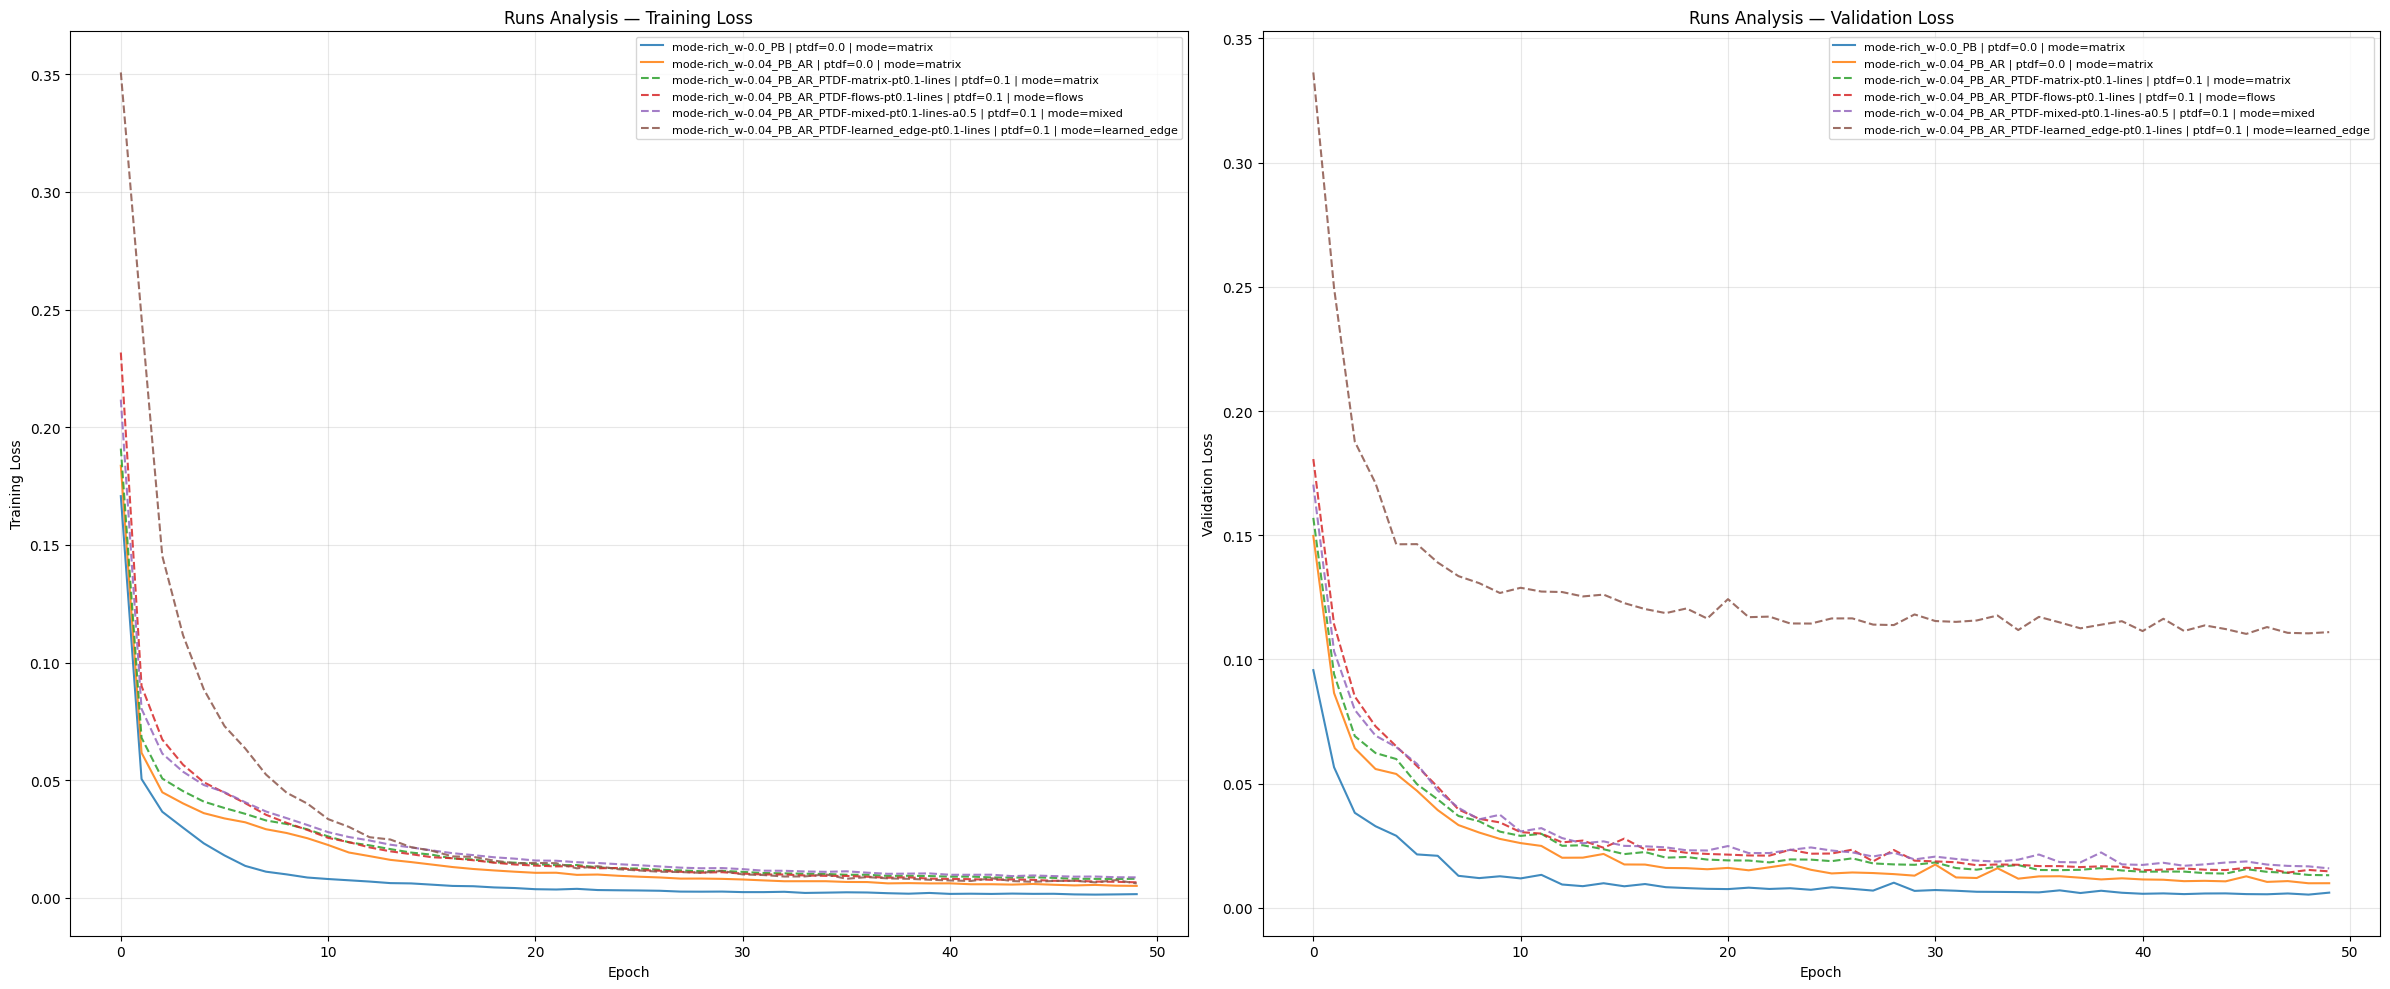

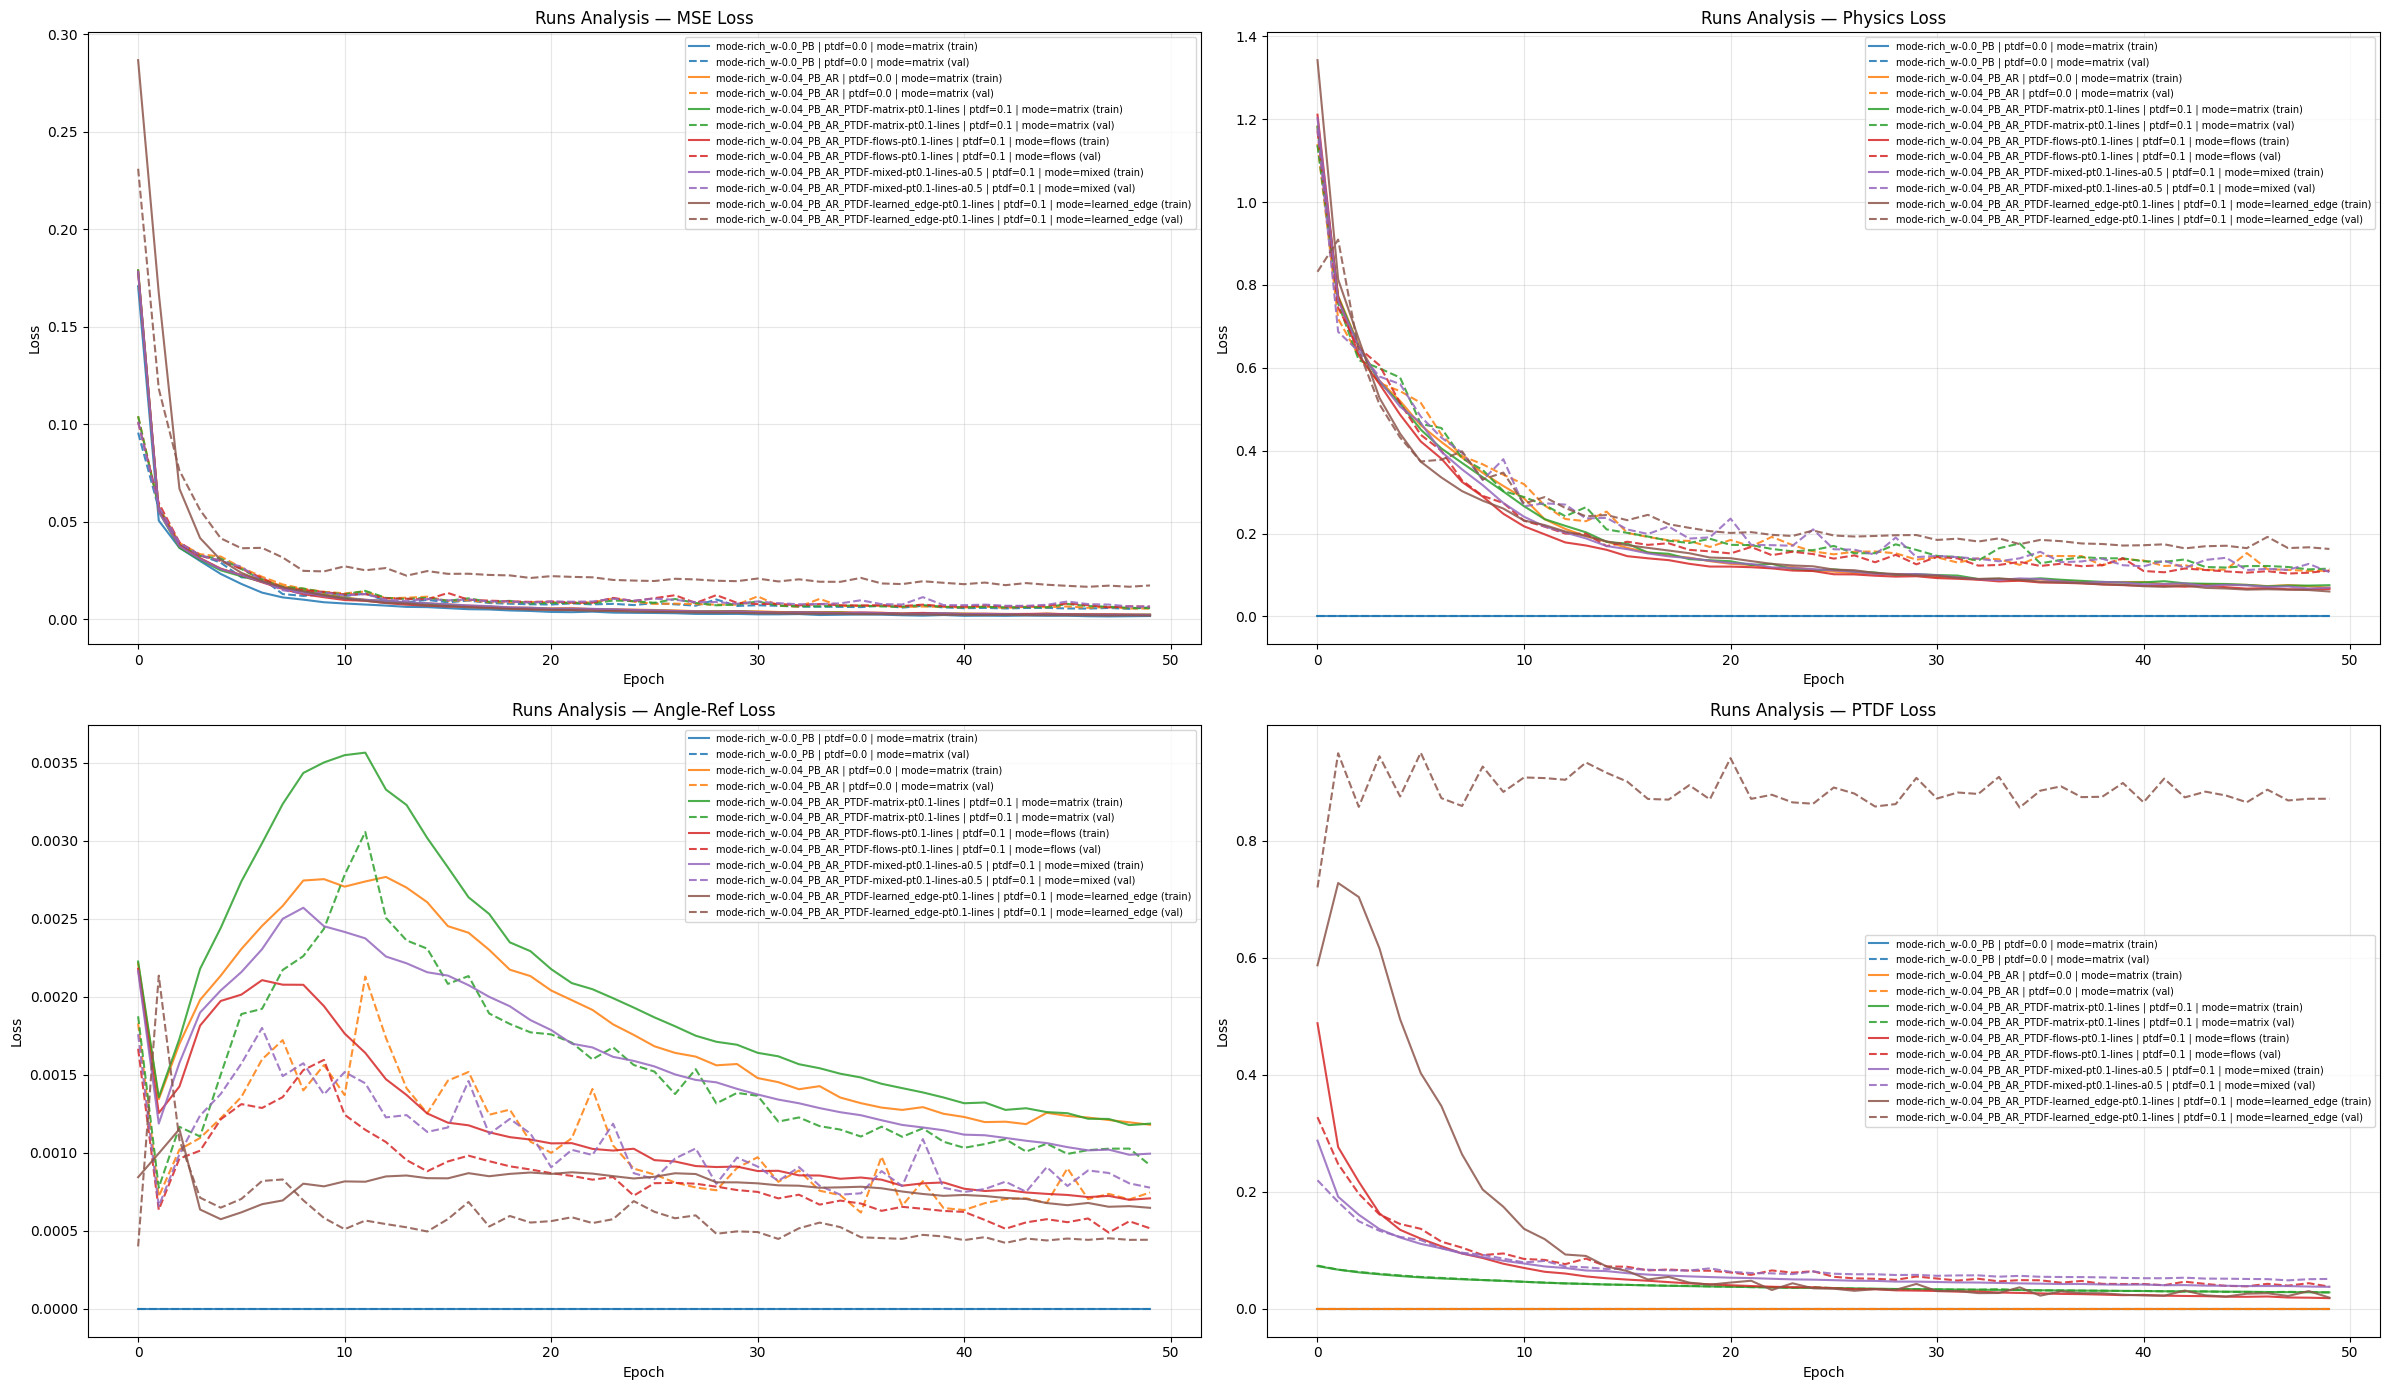

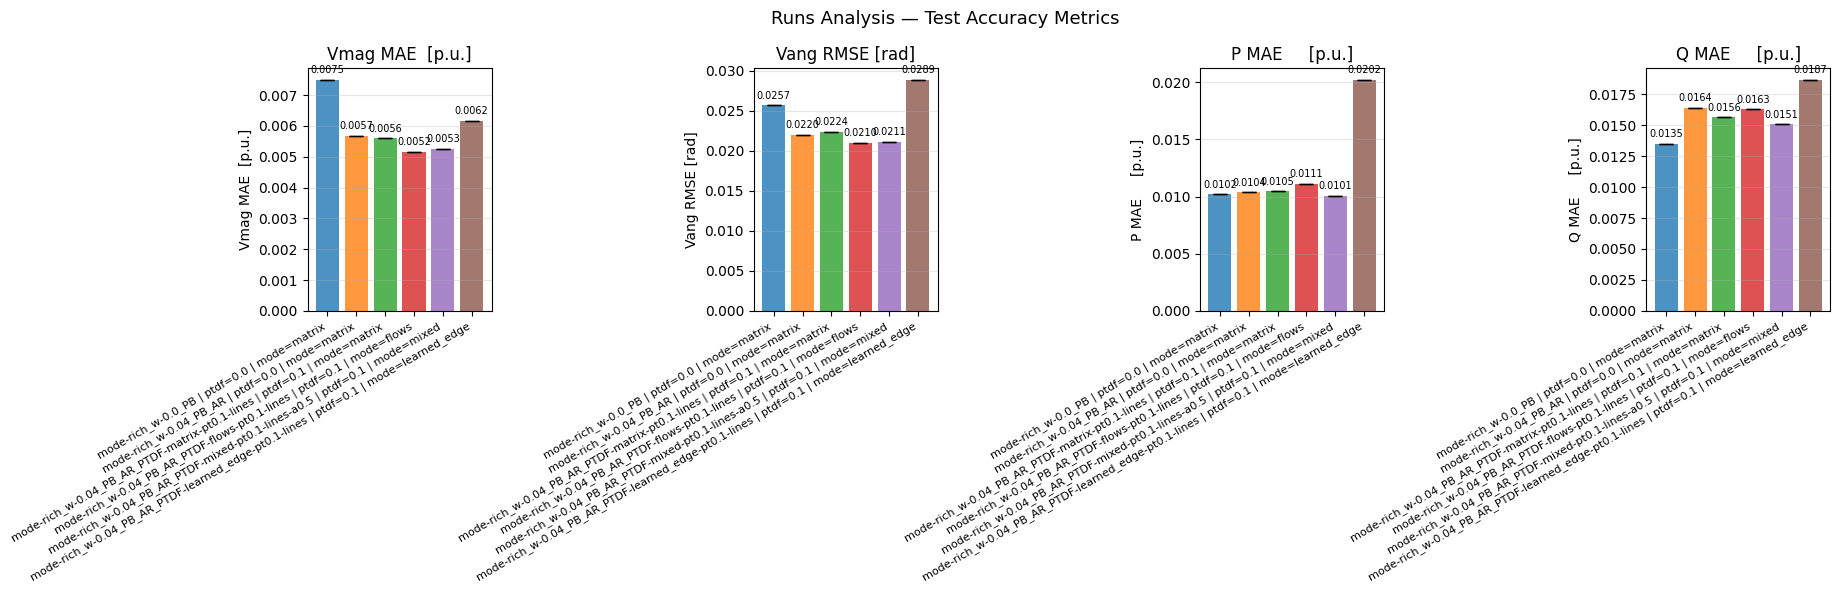

RuntimeError: mat1 and mat2 shapes cannot be multiplied (30x6 and 16x64)

In [85]:
check_hparam_results(runs_ieee9_500_phys_vs_ptdf,run_factorial_analysis=False,test_network=networks_ieee9_large_singel_slack[36])

In [76]:
networks_cigre14_large_singel_slack=load_dataset_list("training_networks_saved\cigre14_large.json")

Loaded 500 networks from training_networks_saved\cigre14_large.json


In [77]:
runs_cigre14_500_phys_vs_ptdf = run_hparam_sweep(
    networks=networks_cigre14_large_singel_slack,
    physics_configs=ptdf_comparison_configs,
    batch_sizes=[64],
    learning_rates=[5e-4],
    num_epochs=50,
    seeds=[42],
    tag="MSE, Physics and PTDF Sweep",
    verbose=False,
    save_path="training_results_saved\\cigre14_large_single_slack_ptdf_sweep_060426.json",
)

1/6 | mode=rich | cfg=mode-rich_w-0.0_PB | wphys=0.0 | ptdfw=0.0 | ptdfmode=matrix | ptdfbr=lines | bs=64 | lr=5e-04 | warmup=10 | seed=42 | Starting time=2026-04-07 01:02:24 | remaining=calculating... | finish≈calculating...


Training: 100%|██████████| 50/50 [48:14<00:00, 57.88s/epoch]


→ done in 49.0 min | Train 0.0003 Val 0.0047 Test 0.0255 
2/6 | mode=rich | cfg=mode-rich_w-0.04_PB_AR | wphys=0.04 | ptdfw=0.0 | ptdfmode=matrix | ptdfbr=lines | bs=64 | lr=5e-04 | warmup=10 | seed=42 | Starting time=2026-04-07 01:51:25 | remaining=4h 5m 4s | est_total=4h 54m 5s | finish≈2026-04-07 05:56:29


Training: 100%|██████████| 50/50 [1:04:21<00:00, 77.22s/epoch]


→ done in 65.2 min | Train 0.0005 Val 0.0038 Test 0.0123 
3/6 | mode=rich | cfg=mode-rich_w-0.04_PB_AR_PTDF-matrix-pt0.1-lines | wphys=0.04 | ptdfw=0.1 | ptdfmode=matrix | ptdfbr=lines | bs=64 | lr=5e-04 | warmup=10 | seed=42 | Starting time=2026-04-07 02:56:36 | remaining=4h 20m 45s | est_total=6h 31m 8s | finish≈2026-04-07 07:17:22


...

→ done in 68.4 min | Train 0.0005 Val 0.0030 Test 0.0108 
5/6 | mode=rich | cfg=mode-rich_w-0.04_PB_AR_PTDF-mixed-pt0.1-lines-a0.5 | wphys=0.04 | ptdfw=0.1 | ptdfmode=mixed | ptdfbr=lines | bs=64 | lr=5e-04 | warmup=10 | seed=42 | Starting time=2026-04-07 05:13:13 | remaining=2h 16m 24s | est_total=6h 49m 14s | finish≈2026-04-07 07:29:38


Training: 100%|██████████| 50/50 [1:10:08<00:00, 84.18s/epoch]


→ done in 71.0 min | Train 0.2347 Val 0.0790 Test 0.0884 
6/6 | mode=rich | cfg=mode-rich_w-0.04_PB_AR_PTDF-learned_edge-pt0.1-lines | wphys=0.04 | ptdfw=0.1 | ptdfmode=learned_edge | ptdfbr=lines | bs=64 | lr=5e-04 | warmup=10 | seed=42 | Starting time=2026-04-07 06:24:12 | remaining=1h 8m 12s | est_total=6h 49m 14s | finish≈2026-04-07 07:32:24


Training: 100%|██████████| 50/50 [1:07:04<00:00, 80.49s/epoch]


→ done in 67.9 min | Train 0.0005 Val 0.0029 Test 0.0080 
